# Прогноз дивидендов и построение факторных стратегий: сопоставление рынков РФ и Японии

**Автор:** Еремкин Дмитрий Валерьевич
**Магистерская программа:** «Инвестиции на финансовых рынках», НИУ ВШЭ, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eremkindv91/dividend-factor-strategies/blob/main/notebooks/02_quality_factor_research.ipynb)


In [ ]:
# ─── Setup: paths & dependencies ─────────────────────────────────────
import os, sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Detect environment: Google Colab vs Local vs Binder
if 'google.colab' in sys.modules:
    print("Google Colab detected. Installing dependencies...")
    os.system("pip install -q catboost xgboost lightgbm scikit-learn shap pandas numpy scipy matplotlib seaborn openpyxl 2>/dev/null")

    # Clone repo
    REPO_URL = "https://github.com/eremkindv91/dividend-factor-strategies"
    if not os.path.exists("/content/dividend-factor-strategies"):
        os.system(f"git clone {REPO_URL} /content/dividend-factor-strategies 2>/dev/null")

    PROJECT_ROOT = Path("/content/dividend-factor-strategies")
    os.chdir(PROJECT_ROOT)
    sys.path.insert(0, str(PROJECT_ROOT))
    print("✓ Colab environment ready")

elif os.getenv('BINDER_LAUNCH_HOST'):
    print("Binder detected")
    PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())

else:
    # Local: notebook is in notebooks/, go up one level to repo root
    PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
    print("Local environment")

DATA_DIR = PROJECT_ROOT / "data"
print(f"Project: {PROJECT_ROOT.name}")
print(f"Data   : {DATA_DIR}")

assert DATA_DIR.exists(), f"Error: Data not found at {DATA_DIR}"
print("Ready to run.\n")

# ФАКТОРНОЕ ИНВЕСТИРОВАНИЕ: РОССИЯ vs ЯПОНИЯ (2011–2026)
# Двухблочное исследование

## Структура ноутбука

### ЧАСТЬ I — BASELINE FACTOR BACKTEST
Широкий тест 7 классических факторов (Value, Size, Momentum, LowVol,
Liquidity, Dividend, Quality-basic) на двух рынках.
Цель — показать, какие факторы работают и **почему Quality заслуживает
отдельного углубления**.

### ЧАСТЬ II — DEEP QUALITY ANALYSIS
Ядро магистерской: Barra-style descriptor-level анализ Quality.
- **Q0** — простой baseline Quality (ROE + Margin + Leverage)
- **Q1** — profitability-heavy
- **Q2** — payout / cash-flow-heavy
- **Q3** — market-specific (разный для РФ и JP)

Плюс: descriptor-level IC, Fama–MacBeth cross-sectional regression,
panel econometrics.

### Дизайн исследования
| Параметр | Россия | Япония |
|---|---|---|
| Universe | MOEX broad market | Nikkei 225 |
| Период | 2012–2026 | 2012–2026 |
| Ребалансировка | Ежегодно, май | Ежегодно, июль |
| Цены | Adj. close monthly (total return) | Monthly returns |
| Rf | РУОНИЯ (ЦБ РФ), daily→monthly | JGB 10Y (MOF Japan) |
| TC | 50 bps one-way at formation | 30 bps |
| Портфель | Top-20, long-only, equal-weight | Top-20 |
| Look-ahead | PIT lag: trading_year = year+1 | trading_year = year+1 |
| Бенчмарк | MCFTR (полная доходность) | Nikkei 225 TR |

### Академические источники
- Fama & French (1992, 1993) — Value (HML), Size (SMB)
- Jegadeesh & Titman (1993) — Momentum
- Baker, Bradley & Wurgler (2011) — Low Volatility Anomaly
- Novy-Marx (2013) — Gross Profitability Premium
- Asness, Frazzini & Pedersen (2019) — Quality Minus Junk
- Sloan (1996) — Accruals Anomaly
- Piotroski (2000) — F-Score
- Faber (2013) — Shareholder Yield
- Amihud (2002) — Illiquidity Premium
- Chui, Titman & Wei (2010) — Momentum in Asia-Pacific

In [347]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os, sys
from scipy import stats
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'figure.dpi': 120,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'axes.titleweight': 'bold',
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'savefig.dpi': 250,
    'figure.max_open_warning': 30,
})

## 0. Вспомогательные функции

Econometric toolkit: OLS, Newey-West HAC, performance metrics.
Не зависит от statsmodels — всё на numpy/scipy.

In [349]:
# ═══════════════════════════════════════════════════════════════════
# 0. HELPERS
# ═══════════════════════════════════════════════════════════════════

def _ols(y, X):
    y, X = np.asarray(y, float), np.asarray(X, float)
    n, k = X.shape
    Xi = np.linalg.inv(X.T @ X)
    b = Xi @ X.T @ y; e = y - X @ b; df = n - k
    s2 = (e @ e) / df; se = np.sqrt(np.diag(s2 * Xi))
    t = b / se; ss_r = e @ e; ss_t = np.sum((y - y.mean())**2)
    r2 = 1 - ss_r / ss_t if ss_t > 0 else 0
    p = 2 * (1 - stats.t.cdf(np.abs(t), df))
    return dict(params=b, se=se, tvalues=t, pvalues=p, r2=r2, n=n, df=df)

def _ols_hac(y, X, lags):
    """OLS + Newey-West HAC (Bartlett kernel)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    n, k = X.shape
    Xi = np.linalg.inv(X.T @ X)
    b = Xi @ X.T @ y; e = y - X @ b; df = n - k
    S = np.zeros((k, k))
    for t_ in range(n):
        xt = X[t_:t_+1].T; S += e[t_]**2 * (xt @ xt.T)
    for j in range(1, lags + 1):
        w = 1 - j / (lags + 1); G = np.zeros((k, k))
        for t_ in range(j, n):
            G += e[t_] * e[t_-j] * (X[t_:t_+1].T @ X[t_-j:t_-j+1])
        S += w * (G + G.T)
    cov = Xi @ S @ Xi; se = np.sqrt(np.diag(cov))
    t = b / se; ss_r = e @ e; ss_t = np.sum((y - y.mean())**2)
    r2 = 1 - ss_r / ss_t if ss_t > 0 else 0
    p = 2 * (1 - stats.t.cdf(np.abs(t), df))
    return dict(params=b, se=se, tvalues=t, pvalues=p, r2=r2, n=n, df=df)

def run_reg(y, x, hac=3):
    """y = alpha + beta*x + eps, HAC NW if hac>0."""
    n = len(y); Xc = np.column_stack([np.ones(n), np.asarray(x)])
    res = _ols_hac(y, Xc, hac) if hac else _ols(y, Xc)
    return dict(alpha=res['params'][0], beta=res['params'][1],
                t_alpha=res['tvalues'][0], t_beta=res['tvalues'][1],
                p_alpha=res['pvalues'][0], p_beta=res['pvalues'][1],
                r2=res['r2'], n=res['n'])

def sig_stars(p):
    if p < .01: return '***'
    if p < .05: return '**'
    if p < .10: return '*'
    return ''

def clean_tk(t):
    if pd.isna(t): return None
    t = str(t).strip().upper()
    if not t or t == 'NAN': return None
    for s in ['.JP', '.TYO', '.T', ' JP', ' EQUITY', '.ME', ' RX', ' RM', '_RM']:
        t = t.replace(s, '')
    return t.strip() or None

def safe_num(s):
    if s.dtype in ['float64', 'int64', 'float32', 'int32']:
        return s.replace([np.inf, -np.inf], np.nan)
    try:
        c = s.astype(str).str.replace(',', '.', regex=False).str.replace(r'\s+', '', regex=True)
        c = c.replace(['', 'nan', 'None', 'NaN', '-', '#N/A', 'N/A', '#VALUE!',
                        '#DIV/0!', 'null', 'inf', '-inf'], np.nan)
        return pd.to_numeric(c, errors='coerce').replace([np.inf, -np.inf], np.nan)
    except:
        return pd.Series(np.nan, index=s.index)

def winz(s, lo=0.02, hi=0.98):
    if len(s.dropna()) < 5: return s
    return s.clip(s.quantile(lo), s.quantile(hi))

def zsc(s):
    return (s - s.mean()) / s.std() if s.std() > 0 else s * 0

def metrics(r, rf_s=None):
    """Performance metrics from monthly return series."""
    r = r.dropna()
    if len(r) < 12:
        return {k: np.nan for k in ['CAGR','Vol','Sharpe','Sortino','MaxDD','HitRate','Cumulative']}
    cum = (1 + r).cumprod(); yrs = len(r) / 12
    cagr = cum.iloc[-1] ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(12)
    if rf_s is not None:
        c = r.index.intersection(rf_s.index)
        exc = r.loc[c] - rf_s.loc[c] if len(c) >= 12 else r
    else:
        exc = r
    sharpe = exc.mean() / exc.std() * np.sqrt(12) if exc.std() > 0 else 0
    ds = exc[exc < 0].std()
    sortino = exc.mean() / ds * np.sqrt(12) if ds > 0 else np.nan
    dd = cum / cum.cummax() - 1
    return {'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe, 'Sortino': sortino,
            'MaxDD': dd.min(), 'HitRate': (r > 0).mean(), 'Cumulative': cum.iloc[-1]}

def ir_ratio(s, b):
    c = s.index.intersection(b.index)
    if len(c) < 12: return np.nan
    a = s.loc[c] - b.loc[c]
    return a.mean() / a.std() * np.sqrt(12) if a.std() > 0 else 0

# ═══════════════════════════════════════════════════════════════════
# PATH UTILITIES
# ═══════════════════════════════════════════════════════════════════

BASE = str(DATA_DIR)

def find_file(keyword):
    for f in os.listdir(BASE):
        if keyword.lower() in f.lower():
            return os.path.join(BASE, f)
    return None

OUT = str(PROJECT_ROOT / 'results' / 'quality_research')
os.makedirs(OUT, exist_ok=True)

---
# ═══════════════════════════════════════════════════════════
# ЧАСТЬ I: BASELINE FACTOR BACKTEST
# ═══════════════════════════════════════════════════════════

Тестируем 7 классических факторов на двух рынках.
Цель — установить baseline и показать, что Quality заслуживает
углублённого анализа.

## 1. Безрисковые ставки

- **Россия**: РУОНИЯ — overnight межбанковская ставка (аналог Fed Funds Rate).
  Дневные данные → месячные: `r_monthly = (1 + r_annual)^(1/12) - 1`.
- **Япония**: 3-Month Financing Bill (T-Bill) — краткосрочные государственные векселя (MOF Japan / BOJ Statistics). Хардкод месячных значений.


In [476]:
# ═══════════════════════════════════════════════════════════════════
# ПРИНУДИТЕЛЬНОЕ УДАЛЕНИЕ СТАРОЙ ФУНКЦИИ
# ═══════════════════════════════════════════════════════════════════

# Удаляем старые объекты из памяти
for _old_name in ['build_jgb_rf', '_JGB']:
    if _old_name in globals():
        del globals()[_old_name]
        print(f"  ✓ Удалено из памяти: {_old_name}")

# Проверка
assert 'build_jgb_rf' not in dir(), "build_jgb_rf всё ещё жива — перезапустите kernel!"
print("  ✓ build_jgb_rf удалена, можно продолжать")

  ✓ Удалено из памяти: build_jgb_rf
  ✓ Удалено из памяти: _JGB
  ✓ build_jgb_rf удалена, можно продолжать


In [478]:
# ═══════════════════════════════════════════════════════════════════
# 1. RISK-FREE RATES
# ═══════════════════════════════════════════════════════════════════

_JAPAN_3M_TBILL = {
    '2010-01': 0.12, '2010-02': 0.12, '2010-03': 0.13, '2010-04': 0.12,
    '2010-05': 0.12, '2010-06': 0.11, '2010-07': 0.11, '2010-08': 0.11,
    '2010-09': 0.11, '2010-10': 0.11, '2010-11': 0.11, '2010-12': 0.10,
    '2011-01': 0.10, '2011-02': 0.10, '2011-03': 0.10, '2011-04': 0.10,
    '2011-05': 0.10, '2011-06': 0.10, '2011-07': 0.10, '2011-08': 0.10,
    '2011-09': 0.10, '2011-10': 0.10, '2011-11': 0.10, '2011-12': 0.10,
    '2012-01': 0.10, '2012-02': 0.10, '2012-03': 0.10, '2012-04': 0.10,
    '2012-05': 0.10, '2012-06': 0.10, '2012-07': 0.10, '2012-08': 0.10,
    '2012-09': 0.10, '2012-10': 0.09, '2012-11': 0.09, '2012-12': 0.09,
    '2013-01': 0.09, '2013-02': 0.09, '2013-03': 0.08, '2013-04': 0.06,
    '2013-05': 0.06, '2013-06': 0.06, '2013-07': 0.06, '2013-08': 0.06,
    '2013-09': 0.06, '2013-10': 0.06, '2013-11': 0.06, '2013-12': 0.06,
    '2014-01': 0.05, '2014-02': 0.05, '2014-03': 0.05, '2014-04': 0.04,
    '2014-05': 0.04, '2014-06': 0.04, '2014-07': 0.04, '2014-08': 0.04,
    '2014-09': 0.03, '2014-10': 0.03, '2014-11': 0.02, '2014-12': 0.02,
    '2015-01': 0.02, '2015-02': 0.02, '2015-03': 0.02, '2015-04': 0.01,
    '2015-05': 0.01, '2015-06': 0.01, '2015-07': 0.01, '2015-08': 0.01,
    '2015-09': 0.00, '2015-10': 0.00, '2015-11': 0.00, '2015-12': 0.00,
    '2016-01': 0.00, '2016-02':-0.05, '2016-03':-0.09, '2016-04':-0.12,
    '2016-05':-0.14, '2016-06':-0.21, '2016-07':-0.24, '2016-08':-0.17,
    '2016-09':-0.20, '2016-10':-0.17, '2016-11':-0.16, '2016-12':-0.13,
    '2017-01':-0.14, '2017-02':-0.14, '2017-03':-0.13, '2017-04':-0.14,
    '2017-05':-0.15, '2017-06':-0.14, '2017-07':-0.14, '2017-08':-0.14,
    '2017-09':-0.14, '2017-10':-0.14, '2017-11':-0.14, '2017-12':-0.13,
    '2018-01':-0.14, '2018-02':-0.14, '2018-03':-0.14, '2018-04':-0.13,
    '2018-05':-0.13, '2018-06':-0.12, '2018-07':-0.12, '2018-08':-0.12,
    '2018-09':-0.12, '2018-10':-0.13, '2018-11':-0.13, '2018-12':-0.14,
    '2019-01':-0.13, '2019-02':-0.12, '2019-03':-0.11, '2019-04':-0.12,
    '2019-05':-0.12, '2019-06':-0.15, '2019-07':-0.16, '2019-08':-0.18,
    '2019-09':-0.19, '2019-10':-0.16, '2019-11':-0.15, '2019-12':-0.12,
    '2020-01':-0.10, '2020-02':-0.09, '2020-03':-0.05, '2020-04':-0.07,
    '2020-05':-0.09, '2020-06':-0.10, '2020-07':-0.10, '2020-08':-0.10,
    '2020-09':-0.10, '2020-10':-0.10, '2020-11':-0.11, '2020-12':-0.10,
    '2021-01':-0.10, '2021-02':-0.11, '2021-03':-0.10, '2021-04':-0.10,
    '2021-05':-0.10, '2021-06':-0.10, '2021-07':-0.10, '2021-08':-0.11,
    '2021-09':-0.10, '2021-10':-0.10, '2021-11':-0.10, '2021-12':-0.10,
    '2022-01':-0.09, '2022-02':-0.08, '2022-03':-0.08, '2022-04':-0.07,
    '2022-05':-0.06, '2022-06':-0.06, '2022-07':-0.08, '2022-08':-0.08,
    '2022-09':-0.08, '2022-10':-0.06, '2022-11':-0.05, '2022-12':-0.04,
    '2023-01':-0.04, '2023-02':-0.05, '2023-03':-0.07, '2023-04':-0.06,
    '2023-05':-0.06, '2023-06':-0.05, '2023-07':-0.05, '2023-08':-0.03,
    '2023-09':-0.03, '2023-10':-0.02, '2023-11':-0.02, '2023-12':-0.01,
    '2024-01':-0.02, '2024-02':-0.01, '2024-03': 0.00, '2024-04': 0.02,
    '2024-05': 0.03, '2024-06': 0.04, '2024-07': 0.05, '2024-08': 0.15,
    '2024-09': 0.18, '2024-10': 0.20, '2024-11': 0.22, '2024-12': 0.22,
    '2026-01': 0.32, '2026-02': 0.42, '2026-03': 0.43, '2026-04': 0.44,
    '2026-05': 0.46, '2026-06': 0.46,
    '2026-07': 0.46, '2026-08': 0.46, '2026-09': 0.46,
    '2026-10': 0.46, '2026-11': 0.46, '2026-12': 0.46,
}

def build_japan_rf() -> pd.Series:
    """3-Month T-Bill — краткосрочная безрисковая ставка Японии."""
    print("  Japan Risk-Free: 3-Month T-Bill")
    idx = pd.to_datetime(list(_JAPAN_3M_TBILL.keys())) + pd.offsets.MonthEnd(0)
    annual = np.array(list(_JAPAN_3M_TBILL.values())) / 100.0
    monthly = np.sign(annual) * (np.abs(1 + annual) ** (1 / 12) - 1)
    rf = pd.Series(monthly, index=idx, name='rf_japan_3m')
    print(f"  Japan 3M T-Bill: {len(rf)} мес., "
          f"средняя годовая = {rf.mean() * 12:.4%}")
    return rf

# ── Обратная совместимость: если где-то вызывается build_jgb_rf ──
build_jgb_rf = build_japan_rf   # алиас → вызов старого имени = вызов новой

def load_ruonia(path: str) -> pd.Series:
    print(f"  Загрузка РУОНИИ...")
    try:
        df = pd.read_excel(path)
        dc = df.columns[0]; rc = [c for c in df.columns if c != dc][0]
        df['_d'] = pd.to_datetime(df[dc], errors='coerce', dayfirst=True)
        df = df.dropna(subset=['_d'])
        raw = df[rc].copy()
        if raw.dtype == 'object':
            raw = raw.astype(str).str.replace(',', '.').str.replace('%', '').str.strip()
        df['_r'] = pd.to_numeric(raw, errors='coerce')
        df = df.dropna(subset=['_r'])
        if df['_r'].median() > 1:
            df['_rf'] = (1 + df['_r'] / 100) ** (1/12) - 1
        else:
            df['_rf'] = (1 + df['_r']) ** (1/12) - 1
        rf = df.set_index('_d')['_rf'].resample('ME').last().dropna()
        print(f"  РУОНИЯ: {len(rf)} мес., средняя годовая = {rf.mean()*12:.2%}")
        return rf
    except Exception as e:
        print(f"  РУОНИЯ fallback: {e}")
        avgs = {2011:3.9,2012:6.1,2013:6.2,2014:8.3,2015:11.0,2016:10.5,
                2017:8.9,2018:7.4,2019:7.1,2020:4.4,2021:5.6,2022:9.0,
                2023:8.5,2024:15.0,2026:20.0}
        dates, rates = [], []
        for y, r in avgs.items():
            for m in range(1, 13):
                dates.append(pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0))
                rates.append((1 + r/100)**(1/12) - 1)
        return pd.Series(rates, index=pd.DatetimeIndex(dates))

## Робастность и дополнительные проверки


In [482]:
# ═══════════════════════════════════════════════════════════════════
# 2. BASELINE STRATEGY DEFINITIONS
# ═══════════════════════════════════════════════════════════════════

RF_BASELINE = {
    'Value': {
        # fcf_yield_pct убран — дублирует Dividend; PBV↑ (устойчивее PE для сырьевых рынков)
        'nonbank': {'pe':(-1,1.0), 'pbv':(-1,1.5), 'ev_ebitda':(-1,1.0)},
        'bank':    {'pbv':(-1,2.0), 'pe':(-1,1.5)},
    },
    'Size': {
        'nonbank': {'log_market_cap':(-1,1.0), 'log_revenue':(-1,0.5)},
        'bank':    {'log_market_cap':(-1,1.0)},
    },
    'Momentum': {
        'nonbank': {'mom_12_1_pct':(+1,1.0), 'mom_6_1_pct':(+1,0.5)},
        'bank':    {'mom_12_1_pct':(+1,1.0), 'mom_6_1_pct':(+1,0.5)},
    },
    'LowVol': {
        'nonbank': {'vol_price_pct':(-1,1.0), 'down_vol_pct':(-1,0.8),
                    'beta_imoex':(-1,0.6), 'idio_vol_pct':(-1,0.5)},
        'bank':    {'vol_price_pct':(-1,1.0), 'beta_imoex':(-1,0.8)},
    },
    'Liquidity': {
        # log_market_cap убран — коллинеарен с Size (r≈0.9), Amihud (2002)
        'nonbank': {'turnover_12m':(-1,1.0), 'amihud_12m':(+1,1.0)},
        'bank':    {'turnover_12m':(-1,1.0), 'amihud_12m':(+1,0.8)},
    },
    'Dividend': {
        'nonbank': {'div_yield_pct':(+1,2.0), 'div_paid_flag':(+1,0.5),
                    'div_streak':(+1,0.5), 'fcf_yield_pct':(+1,0.6)},
        'bank':    {'div_yield_pct':(+1,2.0), 'div_paid_flag':(+1,0.5),
                    'fcf_yield_pct':(+1,0.6)},
    },
    'Quality': {
        'nonbank': {'roe_pct':(+1,1.5), 'net_margin_pct':(+1,1.0),
                    'equity_to_assets_pct':(+1,0.8), 'net_debt_to_ebitda':(-1,1.0),
                    'accruals_ratio':(-1,0.7)},
        'bank':    {'roe_pct':(+1,1.5), 'nim_pct':(+1,1.0),
                    'npl_ratio_pct':(-1,1.0), 'coverage_ratio_pct':(+1,0.8)},
    },
}

JP_BASELINE = {
    'Value': {
        # fcf_yield_pct убран — дублирует Dividend; PBV↑ (TSE 2023 PBR reform)
        'nonbank': {'pe':(-1,1.0), 'pbv':(-1,1.5), 'ev_ebitda':(-1,0.8)},
        'bank':    {'pbv':(-1,2.0), 'pe':(-1,1.0)},
    },
    'Size': {
        'nonbank': {'log_market_cap':(-1,1.0), 'log_revenue':(-1,0.5)},
        'bank':    {'log_market_cap':(-1,1.0)},
    },
    'Momentum': {
        # Ослаблен price-momentum (Chui, Titman & Wei 2010 — momentum слаб в JP)
        # Добавлен earnings momentum (revenue_yoy, roe_yoy) — Novy-Marx (2015)
        'nonbank': {'mom_12_1_pct':(+1,0.6), 'mom_6_1_pct':(+1,0.3),
                    'revenue_yoy_pct':(+1,0.8), 'roe_yoy_pct':(+1,0.5)},
        'bank':    {'mom_12_1_pct':(+1,0.6), 'roe_yoy_pct':(+1,0.8)},
    },
    'LowVol': {
        # Добавлены down_vol и idio_vol для симметрии с RF (4 метрики)
        'nonbank': {'volatility_pct':(-1,1.0), 'beta_market':(-1,0.8),
                    'down_vol_pct':(-1,0.7), 'idio_vol_pct':(-1,0.5)},
        'bank':    {'volatility_pct':(-1,1.0), 'beta_market':(-1,0.8)},
    },
    'Liquidity': {
        # log_market_cap убран — коллинеарен с Size; Amihud нет в JP-панели
        'nonbank': {'turnover_12m':(-1,1.0)},
        'bank':    {'turnover_12m':(-1,1.0)},
    },
    'Dividend': {
        'nonbank': {'total_shareholder_yield_pct':(+1,1.5), 'div_yield_pct':(+1,1.0),
                    'buyback_yield_pct':(+1,1.2)},
        'bank':    {'div_yield_pct':(+1,1.5), 'buyback_yield_pct':(+1,1.0)},
    },
    'Quality': {
        'nonbank': {'roe_pct':(+1,1.5), 'net_margin_pct':(+1,1.0),
                    'equity_ratio':(+1,0.8), 'net_debt_to_ebitda':(-1,0.8),
                    'accruals_ratio':(-1,0.6)},
        # bank_roe убран — дублирует roe_pct; добавлен bank_cost_income
        'bank':    {'roe_pct':(+1,1.5), 'bank_nim':(+1,1.0),
                    'bank_npl':(-1,0.8), 'bank_cost_income':(-1,0.7)},
    },
}

COLORS = {
    'Value':'#1f77b4', 'Size':'#e377c2', 'Momentum':'#9467bd',
    'LowVol':'#8c564b', 'Liquidity':'#bcbd22', 'Dividend':'#d62728',
    'Quality':'#2ca02c', 'ShareholderYield':'#d62728',
    'Q0':'#2ca02c', 'Q1':'#ff7f0e', 'Q2':'#17becf', 'Q3':'#e377c2',
}

CRISIS_RF = [
    {'s':'2008-09','e':'2009-03','n':'GFC','c':'#cce5ff'},
    {'s':'2014-03','e':'2014-12','n':'Крым/Нефть','c':'#ffcccc'},
    {'s':'2015-08','e':'2016-01','n':'China Deval/Нефть','c':'#fff2cc'},
    {'s':'2020-02','e':'2020-04','n':'COVID','c':'#ffe6cc'},
    {'s':'2022-02','e':'2022-10','n':'СВО','c':'#e6ccff'},
]
CRISIS_JP = [
    {'s':'2008-09','e':'2009-03','n':'GFC','c':'#cce5ff'},
    {'s':'2011-03','e':'2011-06','n':'Фукусима','c':'#ffcccc'},
    {'s':'2015-08','e':'2016-02','n':'China Deval/Yen','c':'#fff2cc'},
    {'s':'2020-02','e':'2020-04','n':'COVID','c':'#ffe6cc'},
    {'s':'2022-03','e':'2022-10','n':'Yen Crash','c':'#e6ccff'},
]

## 3. Configuration & DataManager

### DataManager
Загружает 4 типа данных для каждой страны:
1. **Panel** (годовой): тикер × год, фундаментальные показатели
2. **Prices** (месячные): adjusted close → monthly returns
3. **Benchmark**: MCFTR / Nikkei 225 TR → monthly returns
4. **Risk-free**: РУОНИЯ / JGB 10Y → monthly rate

### Предотвращение look-ahead bias
- `trading_year = year + 1` — единственный PIT-лаг: портфель из данных year
  формируется в year+1 (фискальный год Y → ребалансировка в Y+1)
- Рыночные переменные (momentum, volatility, beta) доступны на дату формирования
- Если momentum отсутствует в панели — вычисляется из ценовых данных (proxy)
- Для Liquidity: log(Market Cap) служит вторичным proxy (Amihud 2002)

In [485]:
# ═══════════════════════════════════════════════════════════════════
# 3. CONFIGURATION & DATA MANAGER
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Config:
    country: str = 'RF'
    panel_path: str = ''
    prices_path: str = ''
    prices_format: str = 'wide'   # 'wide' or 'long'
    benchmark_path: str = ''
    rf_path: str = ''
    ticker_col: str = 'ticker'
    year_col: str = 'year'
    sector_col: str = 'sector'
    start_year: int = 2012
    max_year: int = 2026
    rebalance_month: int = 7
    top_n: int = 20
    tc_bps: float = 50.0
    min_market_cap: float = 5000
    bank_sectors: List[str] = field(default_factory=list)
    strategies: Dict = field(default_factory=dict)
    crises: List[Dict] = field(default_factory=list)
    benchmark_name: str = 'Benchmark'
    flag: str = ''

def cfg_rf():
    return Config(
        country='RF', flag='🇷🇺 RF',
        panel_path=find_file('рф_ПАНЕЛЬ'),
        prices_path=find_file('russian_stocks_adjusted'),
        prices_format='wide',
        benchmark_path=find_file('мосбиржи полн дох'),
        rf_path=find_file('руония'),
        sector_col='sector',
        start_year=2012, max_year=2026, rebalance_month=5,
        tc_bps=50.0, min_market_cap=5000,
        bank_sectors=['Финансы (Банки)', 'Финансы', 'Banks', 'Financials'],
        strategies=RF_BASELINE, crises=CRISIS_RF,
        benchmark_name='MCFTR',
    )

def cfg_jp():
    return Config(
        country='JP', flag='🇯🇵 JP',
        panel_path=find_file('JP_PANEL'),
        prices_path=find_file('nikkei225_monthly_returns'),
        prices_format='long',
        benchmark_path=find_file('ИНДЕКС nikkei225'),
        sector_col='super_sector',
        start_year=2012, max_year=2026, rebalance_month=7,
        tc_bps=30.0, min_market_cap=30000,
        bank_sectors=['Banks', 'Diversified Financials', 'Regional Banks',
                      'Insurance', 'Financial Services'],
        strategies=JP_BASELINE, crises=CRISIS_JP,
        benchmark_name='Nikkei 225 TR',
    )

class DataManager:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.panel = self.prices = self.benchmark = self.rf = None

    def load(self):
        c = self.cfg
        print(f"\n{'='*70}\n {c.flag} {c.country} — ЗАГРУЗКА ДАННЫХ\n{'='*70}")
        if c.country == 'RF':
            self.rf = load_ruonia(c.rf_path)
        else:
            self.rf = build_jgb_rf()
        self._load_panel()
        self._load_prices()
        self._load_benchmark()
        self._fill_market_proxies()

    def _load_panel(self):
        c = self.cfg
        p = pd.read_excel(c.panel_path)
        p.columns = [col.strip() for col in p.columns]
        p[c.ticker_col] = p[c.ticker_col].apply(clean_tk)
        p = p[p[c.ticker_col].notna()].copy()

        if c.sector_col in p.columns:
            p['is_bank'] = p[c.sector_col].apply(lambda x: str(x).strip() in c.bank_sectors)
        elif 'is_bank' in p.columns:
            p['is_bank'] = p['is_bank'].fillna(False).astype(bool)
        else:
            p['is_bank'] = False

        p['trading_year'] = p[c.year_col] + 1

        # Convert numeric columns
        hints = ['_pct','_mln','_ratio','pe','pb','ps','ev_','mom_','vol_','beta',
                 'cagr','yoy','fcf','roe','roa','margin','debt','yield','return',
                 'turnover','amihud','coverage','leverage','equity','interest',
                 'accruals','cash','payout','market_cap','log_market','nim','npl',
                 'cost_of_risk','bank_','buyback','shareholder','div_paid',
                 'vol3y','trend3y','cash_conversion','asset_turnover','book_to']
        for col in p.columns:
            if any(h in col.lower() for h in hints):
                if p[col].dtype == 'object':
                    p[col] = safe_num(p[col])
                else:
                    p[col] = p[col].replace([np.inf, -np.inf], np.nan)

        # PIT lag: trading_year = year + 1 уже обеспечивает лаг.
        # Для trading_year=2012 используются fundamentals за year=2011.
        # Дополнительный shift(1) НЕ нужен — он создавал двойной лаг,
        # из-за чего первый год (2011) превращался в NaN и стратегии
        # не могли стартовать с 2012.
        p = p.sort_values([c.ticker_col, c.year_col])

        nb = p[p['is_bank']].groupby(c.ticker_col).ngroups
        nt = p[c.ticker_col].nunique()
        self.panel = p
        print(f"  Panel: {len(p):,} строк, {nt} тикеров (банков: {nb}), "
              f"годы: {p[c.year_col].min()}-{p[c.year_col].max()}")

    def _load_prices(self):
        c = self.cfg
        path = c.prices_path
        print(f"  Загрузка цен: {os.path.basename(path)}")

        if c.prices_format == 'wide':
            # Wide format: index=date, columns=tickers (e.g., russian_stocks_adjusted.xlsx)
            df = pd.read_excel(path, index_col=0, parse_dates=True)
            df.index = pd.to_datetime(df.index, errors='coerce')
            df = df[df.index.notna()]
            # Melt to long format
            melted = df.reset_index().melt(
                id_vars=df.index.name or 'index',
                var_name='ticker', value_name='close')
            melted.columns = ['date', 'ticker', 'close']
            melted['ticker'] = melted['ticker'].apply(clean_tk)
            melted['close'] = pd.to_numeric(melted['close'], errors='coerce')
            melted = melted.dropna(subset=['date', 'ticker', 'close'])
            melted = melted.sort_values(['ticker', 'date'])
            melted['ret'] = melted.groupby('ticker')['close'].pct_change()
            self.prices = melted[['date', 'ticker', 'ret']].copy()

        elif c.prices_format == 'long':
            ext = path.split('.')[-1].lower()
            if ext == 'csv':
                df = pd.read_csv(path)
            else:
                df = pd.read_excel(path, index_col=0)
                df = df.reset_index()
            df.columns = [str(col).strip().lower() for col in df.columns]

            if 'date' in df.columns and 'ticker' in df.columns:
                df['date'] = pd.to_datetime(df['date'], errors='coerce')
                df['ticker'] = df['ticker'].apply(clean_tk)
                df = df.dropna(subset=['date', 'ticker'])
                # Find return column
                for rc in ['return_1mo', 'ret_month_tr', 'ret', 'monthly_return']:
                    if rc in df.columns:
                        df['ret'] = pd.to_numeric(df[rc], errors='coerce')
                        break
                else:
                    if 'close' in df.columns:
                        df = df.sort_values(['ticker', 'date'])
                        df['ret'] = df.groupby('ticker')['close'].pct_change()
                    else:
                        raise ValueError(f"No return/close column found")
                self.prices = df[['date', 'ticker', 'ret']].copy()
            elif 'month' in df.columns:
                tk_col = df.columns[0]
                df['date'] = pd.to_datetime(df['month'], errors='coerce')
                df['ticker'] = df[tk_col].apply(clean_tk)
                df['ret'] = pd.to_numeric(df.get('ret_month_tr', df.get('ret')), errors='coerce')
                self.prices = df[['date', 'ticker', 'ret']].dropna(subset=['date', 'ticker']).copy()
            else:
                raise ValueError(f"Unknown long format: {df.columns.tolist()}")

        # Clean
        self.prices['date'] = pd.to_datetime(self.prices['date'], errors='coerce')
        self.prices = self.prices.dropna(subset=['date'])
        self.prices['ret'] = pd.to_numeric(self.prices['ret'], errors='coerce')
        self.prices.loc[self.prices['ret'].abs() > 2.0, 'ret'] = np.nan
        self.prices = self.prices.sort_values(['ticker', 'date'])
        self.prices.set_index('date', inplace=True)

        ov = len(set(self.panel[c.ticker_col].unique()) & set(self.prices['ticker'].unique()))
        print(f"  Prices: {self.prices['ticker'].nunique()} тикеров, "
              f"overlap с панелью = {ov}, "
              f"период: {self.prices.index.min().date()} – {self.prices.index.max().date()}")

    def _load_benchmark(self):
        c = self.cfg
        if c.benchmark_path and os.path.exists(c.benchmark_path):
            try:
                if c.benchmark_path.endswith('.csv'):
                    df = pd.read_csv(c.benchmark_path, sep=';', decimal=',',
                                     names=['ID', 'date', 'open', 'close'], skiprows=1)
                    df['date'] = pd.to_datetime(df['date'], errors='coerce')
                    df['close'] = pd.to_numeric(df['close'], errors='coerce')
                else:
                    df = pd.read_excel(c.benchmark_path)
                    dc = df.columns[0]
                    vc = df.columns[1]
                    df = df.rename(columns={dc: 'date', vc: 'close'})
                    df['date'] = pd.to_datetime(df['date'], errors='coerce')
                    df['close'] = pd.to_numeric(
                        df['close'].astype(str).str.replace(r'[^\d.\-]', '', regex=True),
                        errors='coerce')
                df = df.dropna(subset=['date', 'close']).sort_values('date')
                bm = df.set_index('date')[['close']].resample('ME').last()
                bm['ret'] = bm['close'].pct_change()
                self.benchmark = bm[['ret']].dropna()
                print(f"  Benchmark ({c.benchmark_name}): {len(self.benchmark)} мес.")
                return
            except Exception as e:
                print(f"  Benchmark error: {e}")

        # Fallback: EW market
        pr = self.prices.copy()
        pr['ym'] = pr.index.to_period('M')
        monthly = pr.groupby(['ym', 'ticker'])['ret'].apply(
            lambda x: (1+x.dropna()).prod()-1 if len(x.dropna()) > 0 else np.nan)
        bm = monthly.groupby(level=0).mean()
        bm.index = bm.index.to_timestamp('M') + pd.offsets.MonthEnd(0)
        self.benchmark = bm.to_frame('ret').dropna()
        start = pd.Timestamp(c.start_year, 1, 1)
        self.benchmark = self.benchmark[self.benchmark.index >= start]
        print(f"  Benchmark (EW fallback): {len(self.benchmark)} мес.")

    def _fill_market_proxies(self):
        """Вычисляет momentum из ценовых данных для строк панели, где он NaN.

        Академически корректно: momentum — рыночная переменная, которая
        вычисляется из доступных цен и не нарушает PIT-принцип.
        12-1 momentum = кумулятивный return с M-12 по M-1 (исключая
        последний месяц — защита от short-term reversal).
        """
        c = self.cfg
        p = self.panel

        mom12_col = 'mom_12_1_pct'
        mom6_col  = 'mom_6_1_pct'

        # Ensure columns exist
        for col in [mom12_col, mom6_col]:
            if col not in p.columns:
                p[col] = np.nan

        need_fill = p[mom12_col].isna() | p[mom6_col].isna()
        if not need_fill.any():
            print("  Proxies: momentum заполнен, proxy не нужен.")
            return

        # ── Monthly returns per ticker from daily prices ──
        pr = self.prices.copy()
        pr['ym'] = pr.index.to_period('M')
        monthly = pr.groupby(['ym', 'ticker'])['ret'].apply(
            lambda x: (1 + x.dropna()).prod() - 1
            if len(x.dropna()) > 0 else np.nan
        ).reset_index()
        monthly.columns = ['ym', 'ticker', 'mret']
        monthly['date'] = monthly['ym'].dt.to_timestamp('M') + pd.offsets.MonthEnd(0)
        monthly = monthly.dropna(subset=['mret']).sort_values(['ticker', 'date'])

        # Pre-compute dict for speed
        mret_by_tk = {}
        for tk, grp in monthly.groupby('ticker'):
            mret_by_tk[tk] = grp.set_index('date')['mret'].sort_index()

        filled_12, filled_6 = 0, 0

        for idx in p[need_fill].index:
            tk = p.loc[idx, c.ticker_col]
            yr = int(p.loc[idx, c.year_col])

            ts = mret_by_tk.get(tk)
            if ts is None or len(ts) < 3:
                continue

            # Reference: rebalance month of trading_year (= yr + 1)
            ref = pd.Timestamp(yr + 1, c.rebalance_month, 1) + pd.offsets.MonthEnd(0)
            end = ref - pd.offsets.MonthEnd(1)   # M-1

            # 12-1 momentum
            if pd.isna(p.loc[idx, mom12_col]):
                start12 = ref - pd.offsets.MonthEnd(12)
                rets = ts[(ts.index > start12) & (ts.index <= end)]
                if len(rets) >= 6:
                    p.loc[idx, mom12_col] = ((1 + rets).prod() - 1) * 100
                    filled_12 += 1

            # 6-1 momentum
            if pd.isna(p.loc[idx, mom6_col]):
                start6 = ref - pd.offsets.MonthEnd(6)
                rets6 = ts[(ts.index > start6) & (ts.index <= end)]
                if len(rets6) >= 3:
                    p.loc[idx, mom6_col] = ((1 + rets6).prod() - 1) * 100
                    filled_6 += 1

        self.panel = p
        n_need = need_fill.sum()
        print(f"  Proxies: из {n_need} строк заполнено "
              f"mom_12_1={filled_12}, mom_6_1={filled_6}")

## 4. FactorEngine — формирование портфелей

### Алгоритм (без look-ahead bias):
Для каждого года T ∈ [start_year, max_year]:
1. Берём `trading_year == T` (= фундаментальные данные за T-1, trading_year = year + 1)
2. Фильтруем по market cap
3. **Dual-track scoring**: банки по специальным метрикам, небанки по стандартным
4. Нормализация скоров банков к шкале небанков
5. Выбор **Top-N** по composite factor score
6. Трекаем месячную доходность портфеля следующие 12 месяцев
7. TC при формировании (один раз в год)

In [488]:
# ═══════════════════════════════════════════════════════════════════
# 4. FACTOR ENGINE
# ═══════════════════════════════════════════════════════════════════

class FactorEngine:
    def __init__(self, cfg, panel, prices, benchmark, rf):
        self.cfg = cfg
        self.panel, self.prices = panel, prices
        self.benchmark, self.rf = benchmark, rf
        self.results = {}

    def _score(self, df, specs):
        sc = pd.Series(0.0, index=df.index)
        cnt = pd.Series(0, index=df.index)
        for col, (d, w) in specs.items():
            if col not in df.columns: continue
            v = df[col].copy()
            if v.notna().sum() < 5: continue
            z = zsc(winz(v))
            # Пропускаем дескриптор без кросс-секционной вариации:
            # все одинаковые → z ≡ 0 → нет информации для ранжирования
            if z.std() < 1e-10: continue
            ok = z.notna()
            sc.loc[ok] += z.loc[ok] * d * w
            cnt.loc[ok] += 1
        result = sc / cnt.replace(0, np.nan)
        # ── Нормализация итогового скора ──
        # Разное число метрик → разная дисперсия composite.
        # Re-standardization делает скоры сопоставимыми между факторами.
        if result.notna().sum() > 2 and result.std() > 1e-10:
            result = (result - result.mean()) / result.std()
        return result

    def run_strategy(self, name, specs):
        nb_sp = specs.get('nonbank', {})
        bk_sp = specs.get('bank', nb_sp)
        rets = []
        mc = next((c for c in ['market_cap_mln', 'log_market_cap']
                    if c in self.panel.columns), None)

        for year in range(self.cfg.start_year, self.cfg.max_year + 1):
            mask = self.panel['trading_year'] == year
            if mc and self.cfg.min_market_cap > 0:
                if 'log' in str(mc):
                    mask &= self.panel[mc] > np.log(self.cfg.min_market_cap)
                else:
                    mask &= self.panel[mc] > self.cfg.min_market_cap
            uni = self.panel[mask].copy()
            if len(uni) < self.cfg.top_n: continue

            banks = uni[uni['is_bank']].copy()
            nonb = uni[~uni['is_bank']].copy()
            scores = pd.Series(np.nan, index=uni.index)

            if len(nonb) >= 3:
                scores.loc[nonb.index] = self._score(nonb, nb_sp)
            if len(banks) >= 2:
                bs = self._score(banks, bk_sp)
                nb_ok = scores.loc[nonb.index]
                if nb_ok.notna().sum() > 0:
                    nm, ns = nb_ok.mean(), nb_ok.std()
                    if ns > 0 and bs.std() > 0:
                        bs = (bs - bs.mean()) / bs.std() * ns + nm
                scores.loc[banks.index] = bs

            uni['fs'] = scores
            uni = uni.dropna(subset=['fs'])
            if len(uni) < self.cfg.top_n: continue
            tickers = uni.nlargest(self.cfg.top_n, 'fs')[self.cfg.ticker_col].tolist()

            # Monthly tracking
            start = pd.Timestamp(year, self.cfg.rebalance_month, 1)
            for mo in range(12):
                dt = start + pd.DateOffset(months=mo)
                pm = ((self.prices.index.year == dt.year) &
                      (self.prices.index.month == dt.month))
                md = self.prices[pm & self.prices['ticker'].isin(tickers)]
                if len(md) > 0:
                    # monthly ticker return: compound daily returns
                    mr = md.groupby('ticker')['ret'].apply(
                        lambda x: (1+x.dropna()).prod()-1 if len(x.dropna()) > 0 else np.nan
                    ).dropna().mean()
                    if pd.notna(mr):
                        tc = self.cfg.tc_bps / 10000 if mo == 0 else 0
                        rets.append({'date': dt + pd.offsets.MonthEnd(0), 'ret': mr - tc})

        if len(rets) < 12: return None
        r = pd.DataFrame(rets).set_index('date').sort_index()
        # Deduplicate (overlapping holding periods)
        r = r.groupby(r.index).mean()
        self.results[name] = r
        return r

    def run_all(self):
        print(f"\n {self.cfg.flag} Запуск baseline стратегий:")
        for name, specs in self.cfg.strategies.items():
            r = self.run_strategy(name, specs)
            if r is not None:
                m = metrics(r['ret'], self.rf)
                i = ir_ratio(r['ret'], self.benchmark['ret'])
                print(f"  {name:15s} | CAGR={m['CAGR']:+.1%} | Sharpe={m['Sharpe']:+.2f} | "
                      f"IR={i:+.2f} | MaxDD={m['MaxDD']:.1%} | {len(r)} мес.")
            else:
                print(f"  {name:15s} | FAILED (insufficient data)")
        return self.results

## 5. CountryReport — отчёт по одному рынку

Для каждого рынка:
1. **Кумулятивный график** — все стратегии vs бенчмарк (log scale)
2. **Индивидуальные графики** — каждая стратегия отдельно + кризисные зоны
3. **Таблица метрик** — отсортирована по убыванию Sharpe
4. **Таблица регрессий** — отсортирована по возрастанию p-value alpha

In [491]:
# ═══════════════════════════════════════════════════════════════════
# 5. COUNTRY REPORT
# ═══════════════════════════════════════════════════════════════════

class CountryReport:
    def __init__(self, cfg, bm, results, rf, label='Baseline'):
        self.cfg, self.bm, self.res, self.rf = cfg, bm, results, rf
        self.label = label
        # ── Единый период: от rebalance_month start_year до min(ends) ──
        # Форсируем начало от start_year (напр. май 2012 для РФ, июль 2012 для JP)
        # чтобы все стратегии стартовали ОДНОВРЕМЕННО. Если у стратегии нет
        # данных на ранние месяцы, fillna(0) подставит 0 (= «не участвует»).
        forced_start = pd.Timestamp(cfg.start_year, cfg.rebalance_month, 1) + pd.offsets.MonthEnd(0)
        # Начало = max(forced_start, бенчмарк, rf) — но НЕ от стратегий
        common_start = max(forced_start, bm.index.min(), rf.index.min())
        # Конец = min(бенчмарк, rf, все стратегии)
        ends = [bm.index.max(), rf.index.max()]
        for d in results.values():
            ends.append(d.index.max())
        common_end = min(ends)
        self.cidx = bm.index[(bm.index >= common_start) & (bm.index <= common_end)]
        self.cidx = self.cidx.sort_values()
        print(f"  {cfg.flag} {label}: единый период = "
              f"{self.cidx.min().date()} – {self.cidx.max().date()} "
              f"({len(self.cidx)} мес.)")
        # CAPM regressions — на ЕДИНОМ периоде cidx
        self.regs = {}
        for fn, d in results.items():
            try:
                c = self.cidx  # все регрессии на одном и том же окне
                r_strat = d['ret'].reindex(c).fillna(0)
                r_bm    = bm.loc[c, 'ret']
                r_rf    = rf.reindex(c).fillna(rf.mean())
                if len(c) >= 24:
                    raw = run_reg(r_strat.values, r_bm.values)
                    capm = run_reg(
                        (r_strat - r_rf).values,
                        (r_bm - r_rf).values
                    )
                    self.regs[fn] = {'raw': raw, 'capm': capm, 'n': len(c)}
            except:
                pass
        print(f"  регрессий = {len(self.regs)} (все на {len(self.cidx)} мес.)")

    def _crises(self, ax):
        for cr in self.cfg.crises:
            s, e = pd.Timestamp(cr['s']), pd.Timestamp(cr['e'])
            if len(self.cidx) > 0 and s <= self.cidx[-1] and e >= self.cidx[0]:
                ax.axvspan(max(s, self.cidx[0]), min(e, self.cidx[-1]),
                           color=cr['c'], alpha=0.2, zorder=0)

    def plot_summary(self):
        if len(self.cidx) < 12: return
        fig, ax = plt.subplots(figsize=(18, 9))
        bm_cum = (1 + self.bm.loc[self.cidx, 'ret']).cumprod()
        ax.plot(bm_cum.index, bm_cum.values, color='black', lw=3.5,
                label=self.cfg.benchmark_name, zorder=100)

        data = []
        for fn, d in self.res.items():
            ret = d['ret'].reindex(self.cidx).fillna(0)
            cum = (1 + ret).cumprod()
            m = metrics(ret, self.rf)
            i = ir_ratio(ret, self.bm.loc[self.cidx, 'ret'])
            data.append(dict(name=fn, cum=cum, final=cum.iloc[-1],
                             sharpe=m['Sharpe'], ir=i, cagr=m['CAGR']))
        data.sort(key=lambda x: x['final'], reverse=True)

        for j, fd in enumerate(data):
            c = COLORS.get(fd['name'], plt.cm.Set2(j / max(len(data), 1)))
            sh = f"{fd['sharpe']:.2f}" if pd.notna(fd['sharpe']) else 'N/A'
            ax.plot(fd['cum'].index, fd['cum'].values, color=c, lw=2.5,
                    label=f"{fd['name']} (Sh:{sh})", zorder=10+j)

        self._crises(ax)

        # Annotations
        items = data + [dict(name=self.cfg.benchmark_name, final=bm_cum.iloc[-1])]
        items.sort(key=lambda x: x['final'], reverse=True)
        last = self.cidx[-1]
        used_y = []
        for it in items:
            fv = it['final']
            if fv <= 0: continue
            cl = COLORS.get(it['name'], 'gray')
            if it['name'] == self.cfg.benchmark_name: cl = 'black'
            # Offset to avoid overlap
            offset_y = 0
            for uy in used_y:
                if abs(np.log(fv) - np.log(uy)) < 0.08:
                    offset_y += 12
            used_y.append(fv)
            ax.annotate(f"{it['name']}: {fv:.1f}x", xy=(last, fv),
                        xytext=(12, offset_y), textcoords='offset points',
                        fontsize=9, fontweight='bold', color=cl, va='center',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=cl, alpha=0.9))

        ax.set_yscale('log')
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.1f}x'))
        country = 'РОССИЯ' if self.cfg.country == 'RF' else 'ЯПОНИЯ'
        ax.set_title(f'{country}: {self.label} — факторные стратегии vs {self.cfg.benchmark_name}\n'
                     f'{self.cidx.min().year}–{self.cidx.max().year} '
                     f'(Top-{self.cfg.top_n}, EW, net of {self.cfg.tc_bps:.0f} bps TC)',
                     fontsize=15, fontweight='bold')
        ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
        ax.grid(True, alpha=0.3, which='both')
        ax.axhline(1, color='gray', ls=':', lw=1)
        ax.margins(x=0.08)
        plt.tight_layout()
        fn = os.path.join(OUT, f'{self.cfg.country}_{self.label}_cumulative.png')
        plt.savefig(fn, bbox_inches='tight')
        plt.show()
        print(f"  → Saved: {fn}")

    def plot_individual(self):
        strats = [(fn, d) for fn, d in self.res.items()]
        n = len(strats)
        if n == 0: return

        fig, axes = plt.subplots(n, 1, figsize=(18, 4 * n), sharex=True)
        if n == 1: axes = [axes]
        bm_cum = (1 + self.bm.loc[self.cidx, 'ret']).cumprod()

        for ax, (fn, d) in zip(axes, strats):
            ret = d['ret'].reindex(self.cidx).fillna(0)
            cum = (1 + ret).cumprod()
            m = metrics(ret, self.rf)
            i = ir_ratio(ret, self.bm.loc[self.cidx, 'ret'])
            reg = self.regs.get(fn, {})
            capm = reg.get('capm', {})
            alpha_ann = capm.get('alpha', 0) * 12 if capm else np.nan
            t_alpha = capm.get('t_alpha', np.nan)
            p_alpha = capm.get('p_alpha', 1)
            beta = capm.get('beta', np.nan)

            c = COLORS.get(fn, '#333333')
            ax.plot(cum.index, cum.values, color=c, lw=2.5, label=fn)
            ax.plot(bm_cum.index, bm_cum.values, color='black', lw=2, ls='--',
                    label=self.cfg.benchmark_name, alpha=0.6)

            for cr in self.cfg.crises:
                s, e = pd.Timestamp(cr['s']), pd.Timestamp(cr['e'])
                if s <= self.cidx[-1] and e >= self.cidx[0]:
                    ax.axvspan(max(s, self.cidx[0]), min(e, self.cidx[-1]),
                               color=cr['c'], alpha=0.15, zorder=0)

            ax.set_yscale('log')
            ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.1f}x'))

            title = (f"{fn}  |  CAGR={m['CAGR']:.1%}  Sharpe={m['Sharpe']:.2f}  "
                     f"IR={i:+.2f}  MaxDD={m['MaxDD']:.1%}")
            if not np.isnan(alpha_ann):
                title += f"  |  α={alpha_ann:.1%}{sig_stars(p_alpha)} (t={t_alpha:.2f}) β={beta:.2f}"
            ax.set_title(title, fontsize=11, pad=5)
            ax.legend(loc='upper left', fontsize=9)
            ax.grid(True, alpha=0.3)

        axes[-1].set_xlabel('Year', fontsize=12)
        country = 'РОССИЯ' if self.cfg.country == 'RF' else 'ЯПОНИЯ'
        fig.suptitle(f'{country}: {self.label} — индивидуальные стратегии',
                     fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        fn = os.path.join(OUT, f'{self.cfg.country}_{self.label}_individual.png')
        plt.savefig(fn, bbox_inches='tight')
        plt.show()
        print(f"  → Saved: {fn}")

    def metrics_table(self):
        rows = []
        nm = len(self.cidx)
        rf_cidx = self.rf.reindex(self.cidx).fillna(self.rf.mean())
        bm_ret = self.bm.loc[self.cidx, 'ret']
        bm_m = metrics(bm_ret, rf_cidx)
        rows.append(dict(Strategy=self.cfg.benchmark_name, Country=self.cfg.country,
                         N_months=nm,
                         Cumulative=bm_m.get('Cumulative', np.nan),
                         CAGR=bm_m['CAGR'], Vol=bm_m['Vol'], Sharpe=bm_m['Sharpe'],
                         Sortino=bm_m.get('Sortino', np.nan),
                         IR=0.0, MaxDD=bm_m['MaxDD'], Excess=0.0,
                         HitRate=bm_m.get('HitRate', np.nan)))
        for fn, d in self.res.items():
            ret = d['ret'].reindex(self.cidx).fillna(0)
            m = metrics(ret, rf_cidx)
            i = ir_ratio(ret, bm_ret)
            reg = self.regs.get(fn, {})
            capm = reg.get('capm', {})
            rows.append(dict(Strategy=fn, Country=self.cfg.country,
                             N_months=nm,
                             Cumulative=m.get('Cumulative', np.nan),
                             CAGR=m['CAGR'], Vol=m['Vol'], Sharpe=m['Sharpe'],
                             Sortino=m.get('Sortino', np.nan),
                             IR=i, MaxDD=m['MaxDD'],
                             Excess=m['CAGR'] - bm_m['CAGR'],
                             HitRate=m.get('HitRate', np.nan),
                             Alpha=capm.get('alpha', np.nan) * 12 if capm else np.nan,
                             Beta=capm.get('beta', np.nan),
                             t_alpha=capm.get('t_alpha', np.nan),
                             p_alpha=capm.get('p_alpha', np.nan),
                             ))
        df = pd.DataFrame(rows).sort_values('Sharpe', ascending=False)
        return df

    def reg_table(self):
        rows = []
        for fn, reg in self.regs.items():
            raw, capm = reg['raw'], reg['capm']
            rows.append({
                'Strategy': fn, 'Country': self.cfg.country, 'N_months': reg['n'],
                'beta_raw': raw['beta'], 'alpha_raw_ann': raw['alpha'] * 12,
                'R2_raw': raw['r2'],
                'beta_CAPM': capm['beta'],
                'alpha_Jensen_ann': capm['alpha'] * 12,
                't_alpha_CAPM': capm['t_alpha'],
                'p_alpha_CAPM': capm['p_alpha'],
                'sig': sig_stars(capm['p_alpha']),
                'R2_CAPM': capm['r2'],
            })
        df = pd.DataFrame(rows).sort_values('p_alpha_CAPM', ascending=True)
        return df

## 6. ComparativeReport — межрыночное сравнение

Объединяет Россию и Японию:
1. **Метрики** — sorted by Sharpe (descending)
2. **Регрессии** — sorted by p-value alpha (ascending)
3. **Bar chart** — Sharpe & IR side-by-side
4. **Scatter** — Jensen's alpha vs beta

In [494]:
# ═══════════════════════════════════════════════════════════════════
# 6. COMPARATIVE REPORT
# ═══════════════════════════════════════════════════════════════════

class ComparativeReport:
    def __init__(self, rep_rf: CountryReport, rep_jp: CountryReport, label='Baseline'):
        self.rf = rep_rf; self.jp = rep_jp; self.label = label

    def metrics_comparison(self):
        print(f"\n{'='*90}")
        print(f"  {self.label}: СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК (по Sharpe ↓)")
        print(f"{'='*90}")
        t = pd.concat([self.rf.metrics_table(), self.jp.metrics_table()])
        t = t.sort_values('Sharpe', ascending=False).reset_index(drop=True)
        fmt = {
            'N_months': '{:.0f}',
            'Cumulative': '{:.2f}x', 'CAGR': '{:.1%}', 'Vol': '{:.1%}',
            'Sharpe': '{:.2f}', 'Sortino': '{:.2f}', 'IR': '{:.2f}',
            'MaxDD': '{:.1%}', 'Excess': '{:+.1%}', 'HitRate': '{:.0%}',
            'Alpha': '{:.2%}', 'Beta': '{:.2f}', 't_alpha': '{:.2f}',
            'p_alpha': '{:.4f}',
        }
        try:
            display(t.style.format(fmt, na_rep='—')
                     .background_gradient(subset=['Sharpe'], cmap='RdYlGn', vmin=-0.2, vmax=0.8)
                     .background_gradient(subset=['IR'], cmap='RdYlGn', vmin=-0.3, vmax=0.6))
        except:
            print(t.to_string())
        return t

    def regression_comparison(self):
        print(f"\n{'='*90}")
        print(f"  {self.label}: ЭКОНОМЕТРИЧЕСКАЯ ТАБЛИЦА (по значимости α ↑)")
        print(f"  Raw: Rp = α + β·Rm + ε  |  CAPM: (Rp−Rf) = α + β·(Rm−Rf) + ε")
        print(f"  Rf: РУОНИЯ (РФ) / JGB 10Y (JP)  |  HAC Newey-West (3 lags)")
        print(f"{'='*90}")
        r = pd.concat([self.rf.reg_table(), self.jp.reg_table()])
        r = r.sort_values('p_alpha_CAPM', ascending=True).reset_index(drop=True)
        fmt = {
            'beta_raw':'{:.3f}', 'alpha_raw_ann':'{:.2%}', 'R2_raw':'{:.3f}',
            'beta_CAPM':'{:.3f}', 'alpha_Jensen_ann':'{:.2%}',
            't_alpha_CAPM':'{:.2f}', 'p_alpha_CAPM':'{:.4f}', 'R2_CAPM':'{:.3f}',
            'N_months':'{:.0f}',
        }
        try:
            display(r.style.format(fmt, na_rep='—')
                     .background_gradient(subset=['alpha_Jensen_ann'], cmap='RdYlGn', vmin=-0.05, vmax=0.15)
                     .background_gradient(subset=['R2_CAPM'], cmap='Blues', vmin=0, vmax=1))
        except:
            print(r.to_string())
        return r

    def plot_comparison_bars(self):
        t_rf = self.rf.metrics_table()
        t_jp = self.jp.metrics_table()
        s_rf = t_rf[t_rf['Strategy'] != self.rf.cfg.benchmark_name].set_index('Strategy')
        s_jp = t_jp[t_jp['Strategy'] != self.jp.cfg.benchmark_name].set_index('Strategy')
        all_names = sorted(set(s_rf.index) | set(s_jp.index))

        fig, axes = plt.subplots(1, 3, figsize=(22, 7))
        x = np.arange(len(all_names)); w = 0.35

        for col_i, (metric, label) in enumerate([('Sharpe', 'Sharpe Ratio'),
                                                   ('IR', 'Information Ratio'),
                                                   ('CAGR', 'CAGR')]):
            ax = axes[col_i]
            v_rf = [s_rf.loc[n, metric] if n in s_rf.index else 0 for n in all_names]
            v_jp = [s_jp.loc[n, metric] if n in s_jp.index else 0 for n in all_names]
            ax.bar(x - w/2, v_rf, w, label='Россия', color='#C00000', alpha=0.85)
            ax.bar(x + w/2, v_jp, w, label='Япония', color='#1F4E79', alpha=0.85)
            ax.set_xticks(x); ax.set_xticklabels(all_names, rotation=45, ha='right')
            title_fmt = '{:.2f}' if metric != 'CAGR' else '{:.1%}'
            ax.set_title(label, fontweight='bold', fontsize=14)
            ax.axhline(0, color='black', lw=1)
            ax.legend(fontsize=10)
            ax.grid(axis='y', alpha=0.3)
            for i, (vr, vj) in enumerate(zip(v_rf, v_jp)):
                f = f'{vr:.2f}' if metric != 'CAGR' else f'{vr:.1%}'
                g = f'{vj:.2f}' if metric != 'CAGR' else f'{vj:.1%}'
                if pd.notna(vr) and vr != 0:
                    ax.text(i - w/2, vr, f, ha='center',
                            va='bottom' if vr > 0 else 'top', fontsize=7.5, fontweight='bold')
                if pd.notna(vj) and vj != 0:
                    ax.text(i + w/2, vj, g, ha='center',
                            va='bottom' if vj > 0 else 'top', fontsize=7.5, fontweight='bold')

        fig.suptitle(f'{self.label}: Россия vs Япония',
                     fontsize=15, fontweight='bold', y=1.02)
        plt.tight_layout()
        fn = os.path.join(OUT, f'{self.label}_comparison_bars.png')
        plt.savefig(fn, bbox_inches='tight')
        plt.show()
        print(f"  → Saved: {fn}")

    def plot_alpha_scatter(self):
        r_rf = self.rf.reg_table()
        r_jp = self.jp.reg_table()
        fig, ax = plt.subplots(figsize=(12, 8))
        for df, color, marker, label in [
            (r_rf, '#C00000', 'o', 'Россия'),
            (r_jp, '#1F4E79', '^', 'Япония'),
        ]:
            if len(df) == 0: continue
            ax.scatter(df['beta_CAPM'], df['alpha_Jensen_ann'] * 100, c=color,
                       marker=marker, s=120, alpha=0.8, edgecolors='black',
                       linewidth=0.5, label=label, zorder=5)
            for _, row in df.iterrows():
                ax.annotate(f"{row['Strategy']}{row['sig']}",
                           (row['beta_CAPM'], row['alpha_Jensen_ann'] * 100),
                            xytext=(6, 4), textcoords='offset points',
                            fontsize=9, color=color)
        ax.axhline(0, color='gray', ls='--', lw=1)
        ax.axvline(1, color='gray', ls=':', lw=1, alpha=0.5)
        ax.set_xlabel('β (CAPM)', fontsize=13)
        ax.set_ylabel("Jensen's α (% ann.)", fontsize=13)
        ax.set_title(f"{self.label}: Jensen's α vs β\nРоссия vs Япония (HAC NW)",
                     fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        fn = os.path.join(OUT, f'{self.label}_alpha_scatter.png')
        plt.savefig(fn, bbox_inches='tight')
        plt.show()
        print(f"  → Saved: {fn}")

    def run_all(self):
        self.rf.plot_summary()
        self.rf.plot_individual()
        self.jp.plot_summary()
        self.jp.plot_individual()
        mt = self.metrics_comparison()
        rt = self.regression_comparison()
        self.plot_comparison_bars()
        self.plot_alpha_scatter()
        return mt, rt

## 7. Запуск ЧАСТИ I — Baseline Factor Backtest

Запускаем 7 факторов × 2 рынка = 14 бэктестов.

  ЧАСТЬ I: BASELINE FACTOR BACKTEST — РОССИЯ vs ЯПОНИЯ
  7 факторов × 2 рынка = 14 бэктестов

 🇷🇺 RF RF — ЗАГРУЗКА ДАННЫХ
  Загрузка РУОНИИ...
  РУОНИЯ: 180 мес., средняя годовая = 8.91%
  Panel: 3,048 строк, 268 тикеров (банков: 28), годы: 2011-2025
  Загрузка цен: russian_stocks_adjusted.xlsx
  Prices: 287 тикеров, overlap с панелью = 267, период: 2011-01-31 – 2026-01-31
  Benchmark (MCFTR): 251 мес.
  Proxies: из 921 строк заполнено mom_12_1=356, mom_6_1=292

 🇷🇺 RF Запуск baseline стратегий:
  Value           | CAGR=+15.6% | Sharpe=+0.33 | IR=+0.26 | MaxDD=-32.0% | 165 мес.
  Size            | CAGR=+18.7% | Sharpe=+0.39 | IR=+0.28 | MaxDD=-39.2% | 161 мес.
  Momentum        | CAGR=+13.6% | Sharpe=+0.24 | IR=+0.14 | MaxDD=-48.7% | 165 мес.
  LowVol          | CAGR=+12.7% | Sharpe=+0.21 | IR=+0.06 | MaxDD=-28.1% | 165 мес.
  Liquidity       | CAGR=+13.9% | Sharpe=+0.22 | IR=+0.10 | MaxDD=-49.2% | 129 мес.
  Dividend        | CAGR=+17.2% | Sharpe=+0.40 | IR=+0.39 | MaxDD=-33.9% | 165 

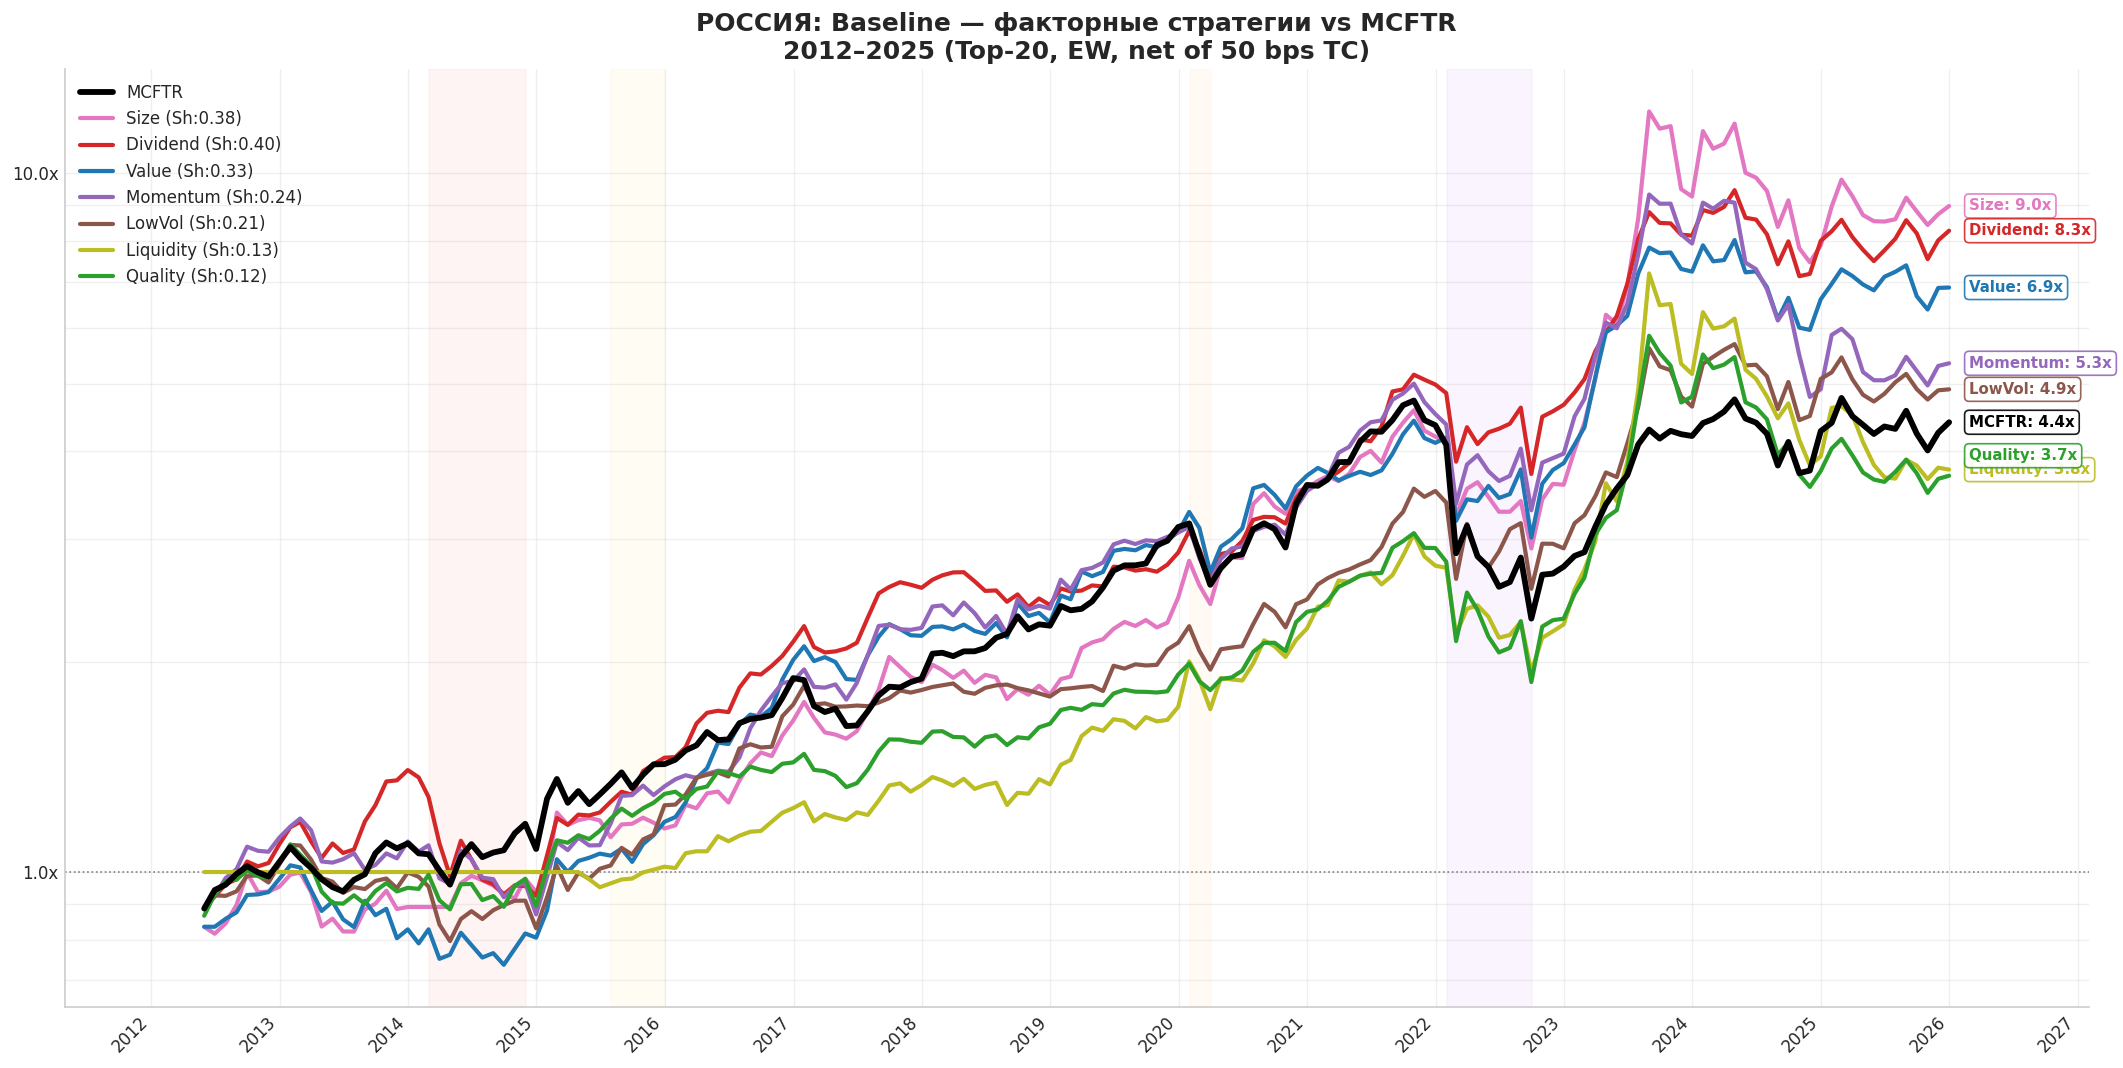

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/RF_Baseline_cumulative.png


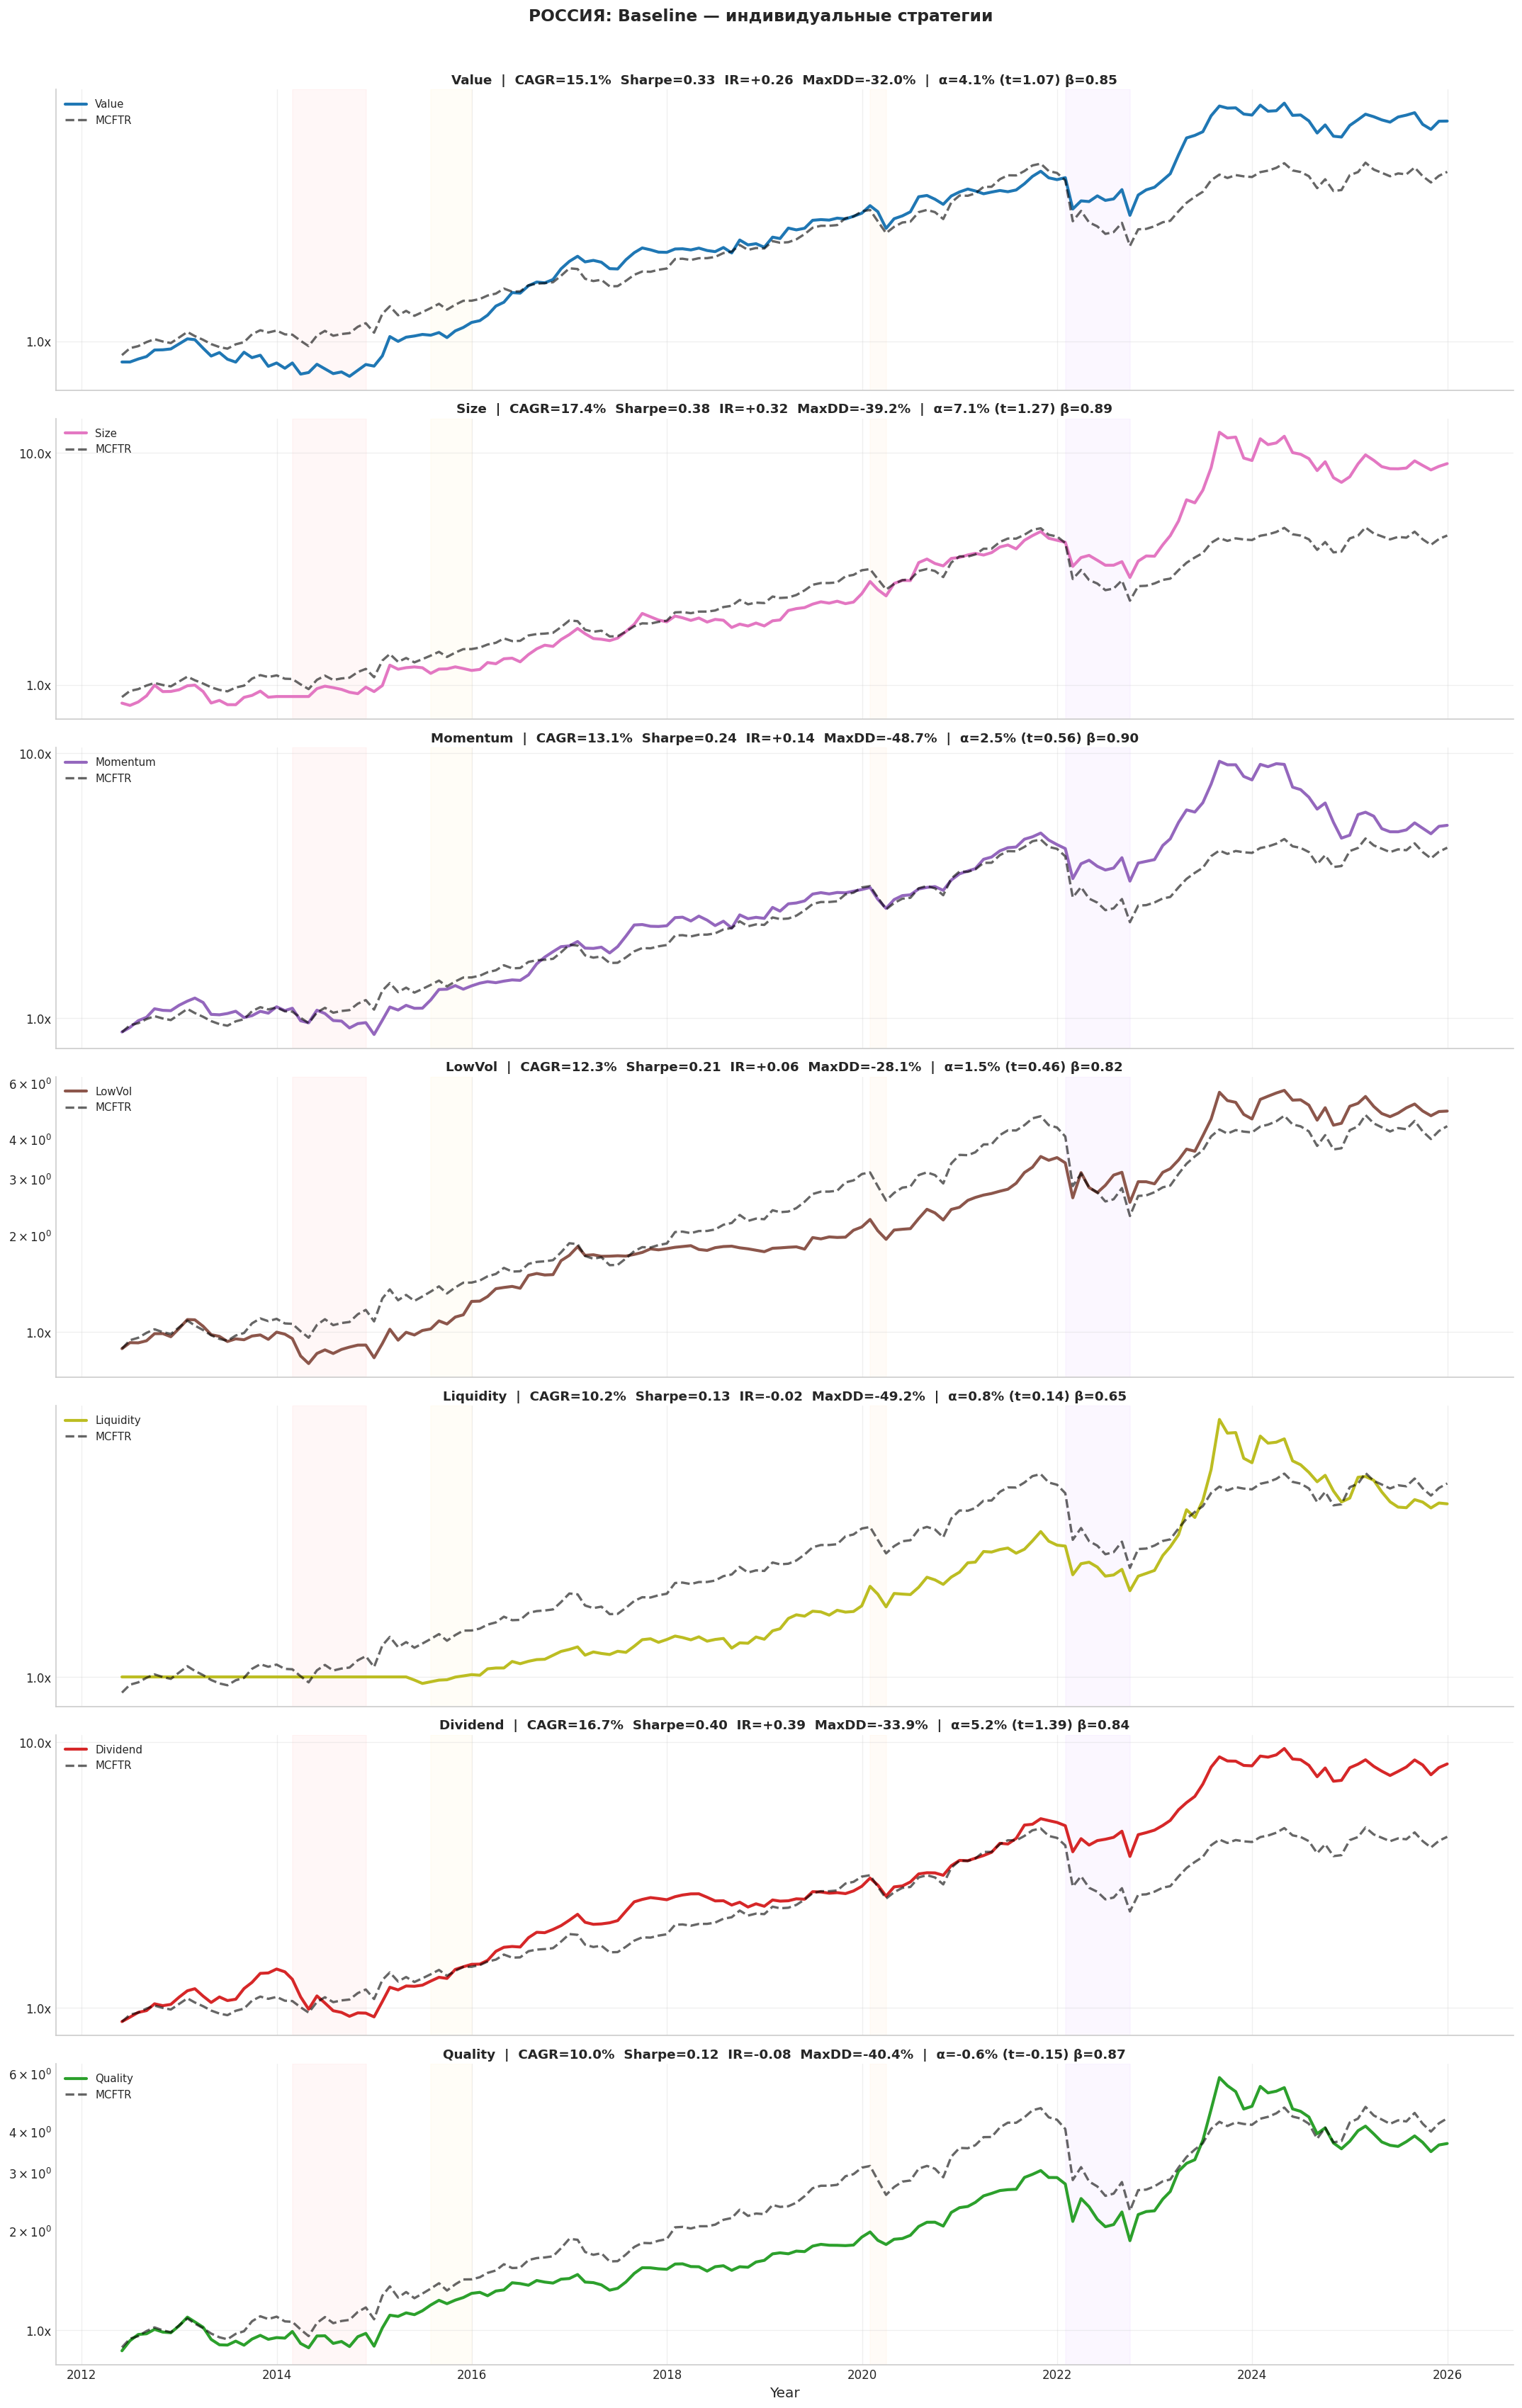

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/RF_Baseline_individual.png


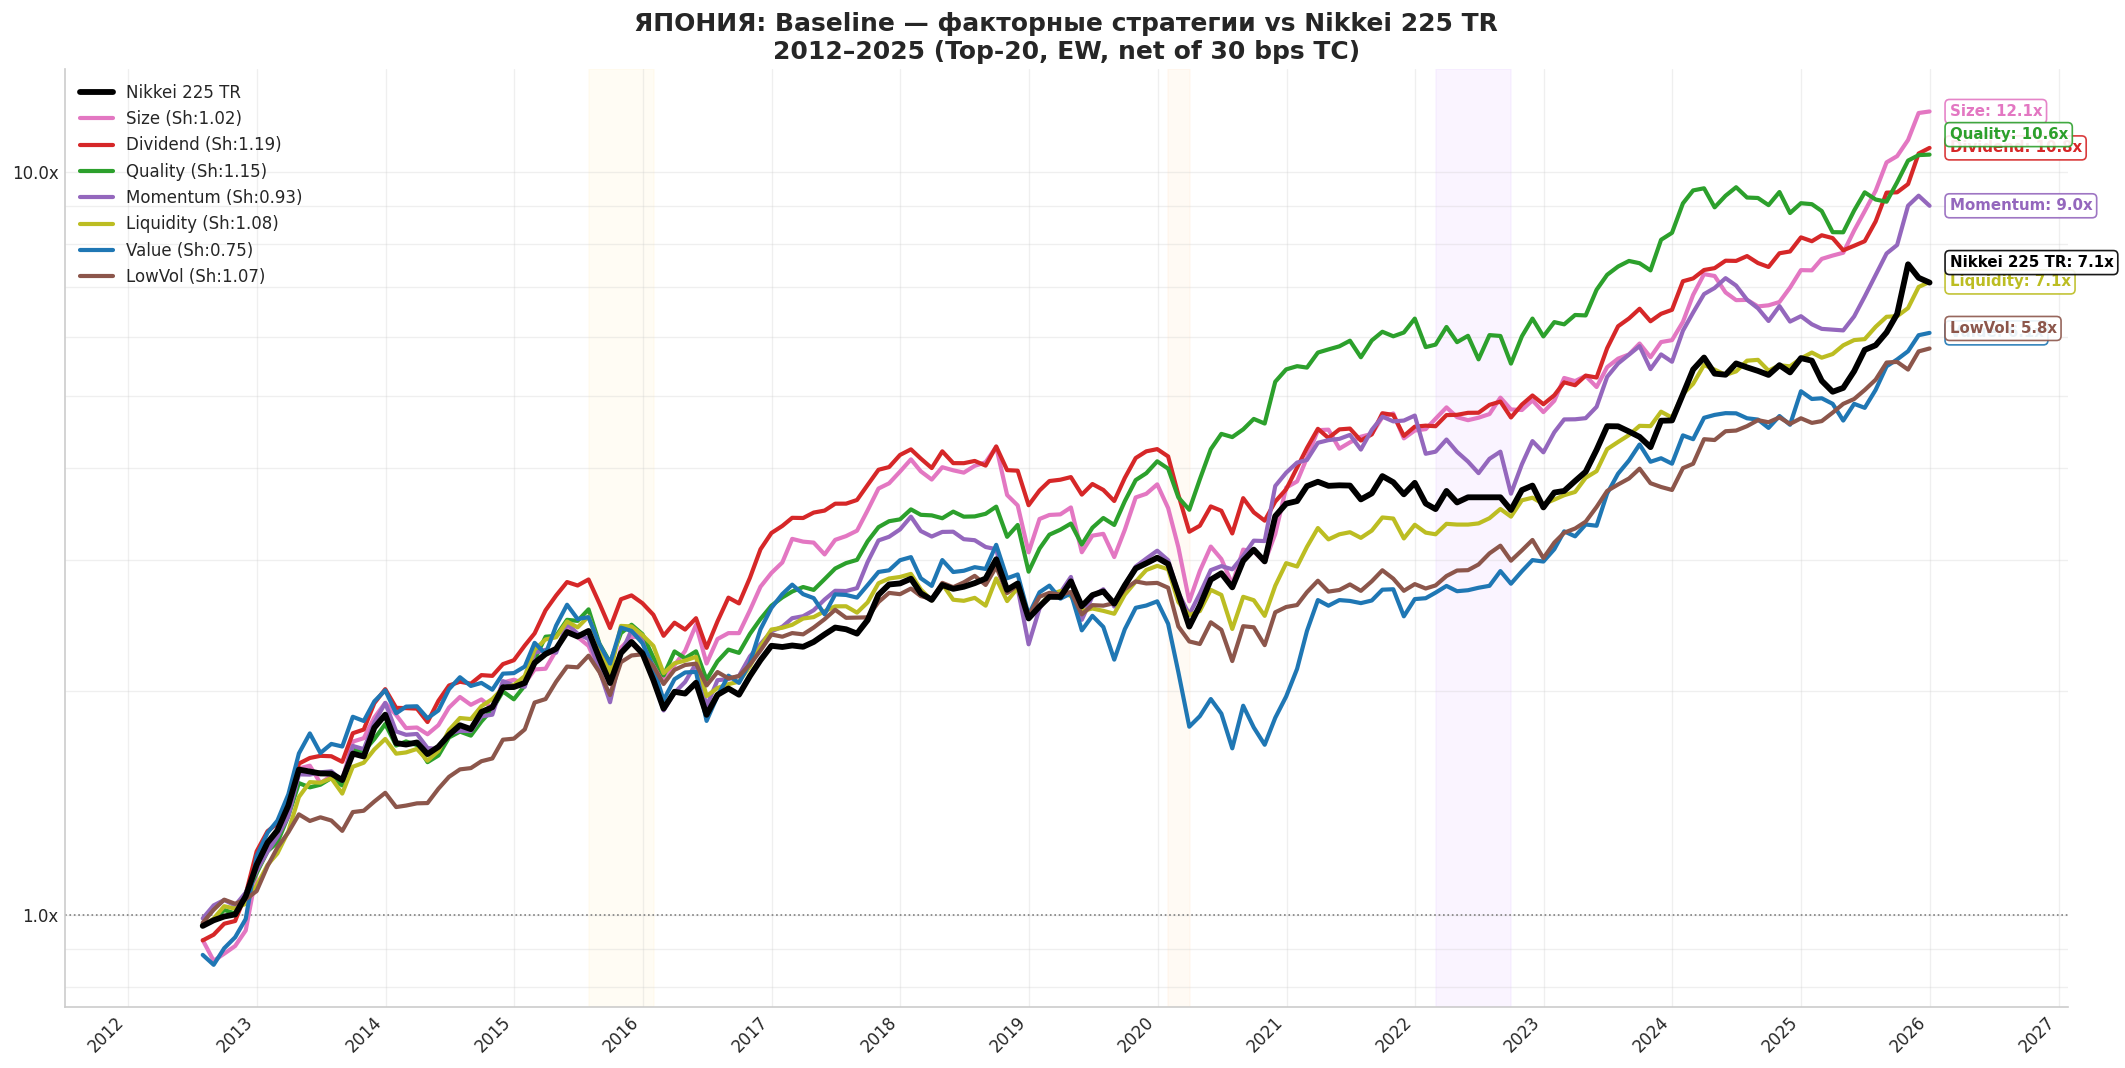

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/JP_Baseline_cumulative.png


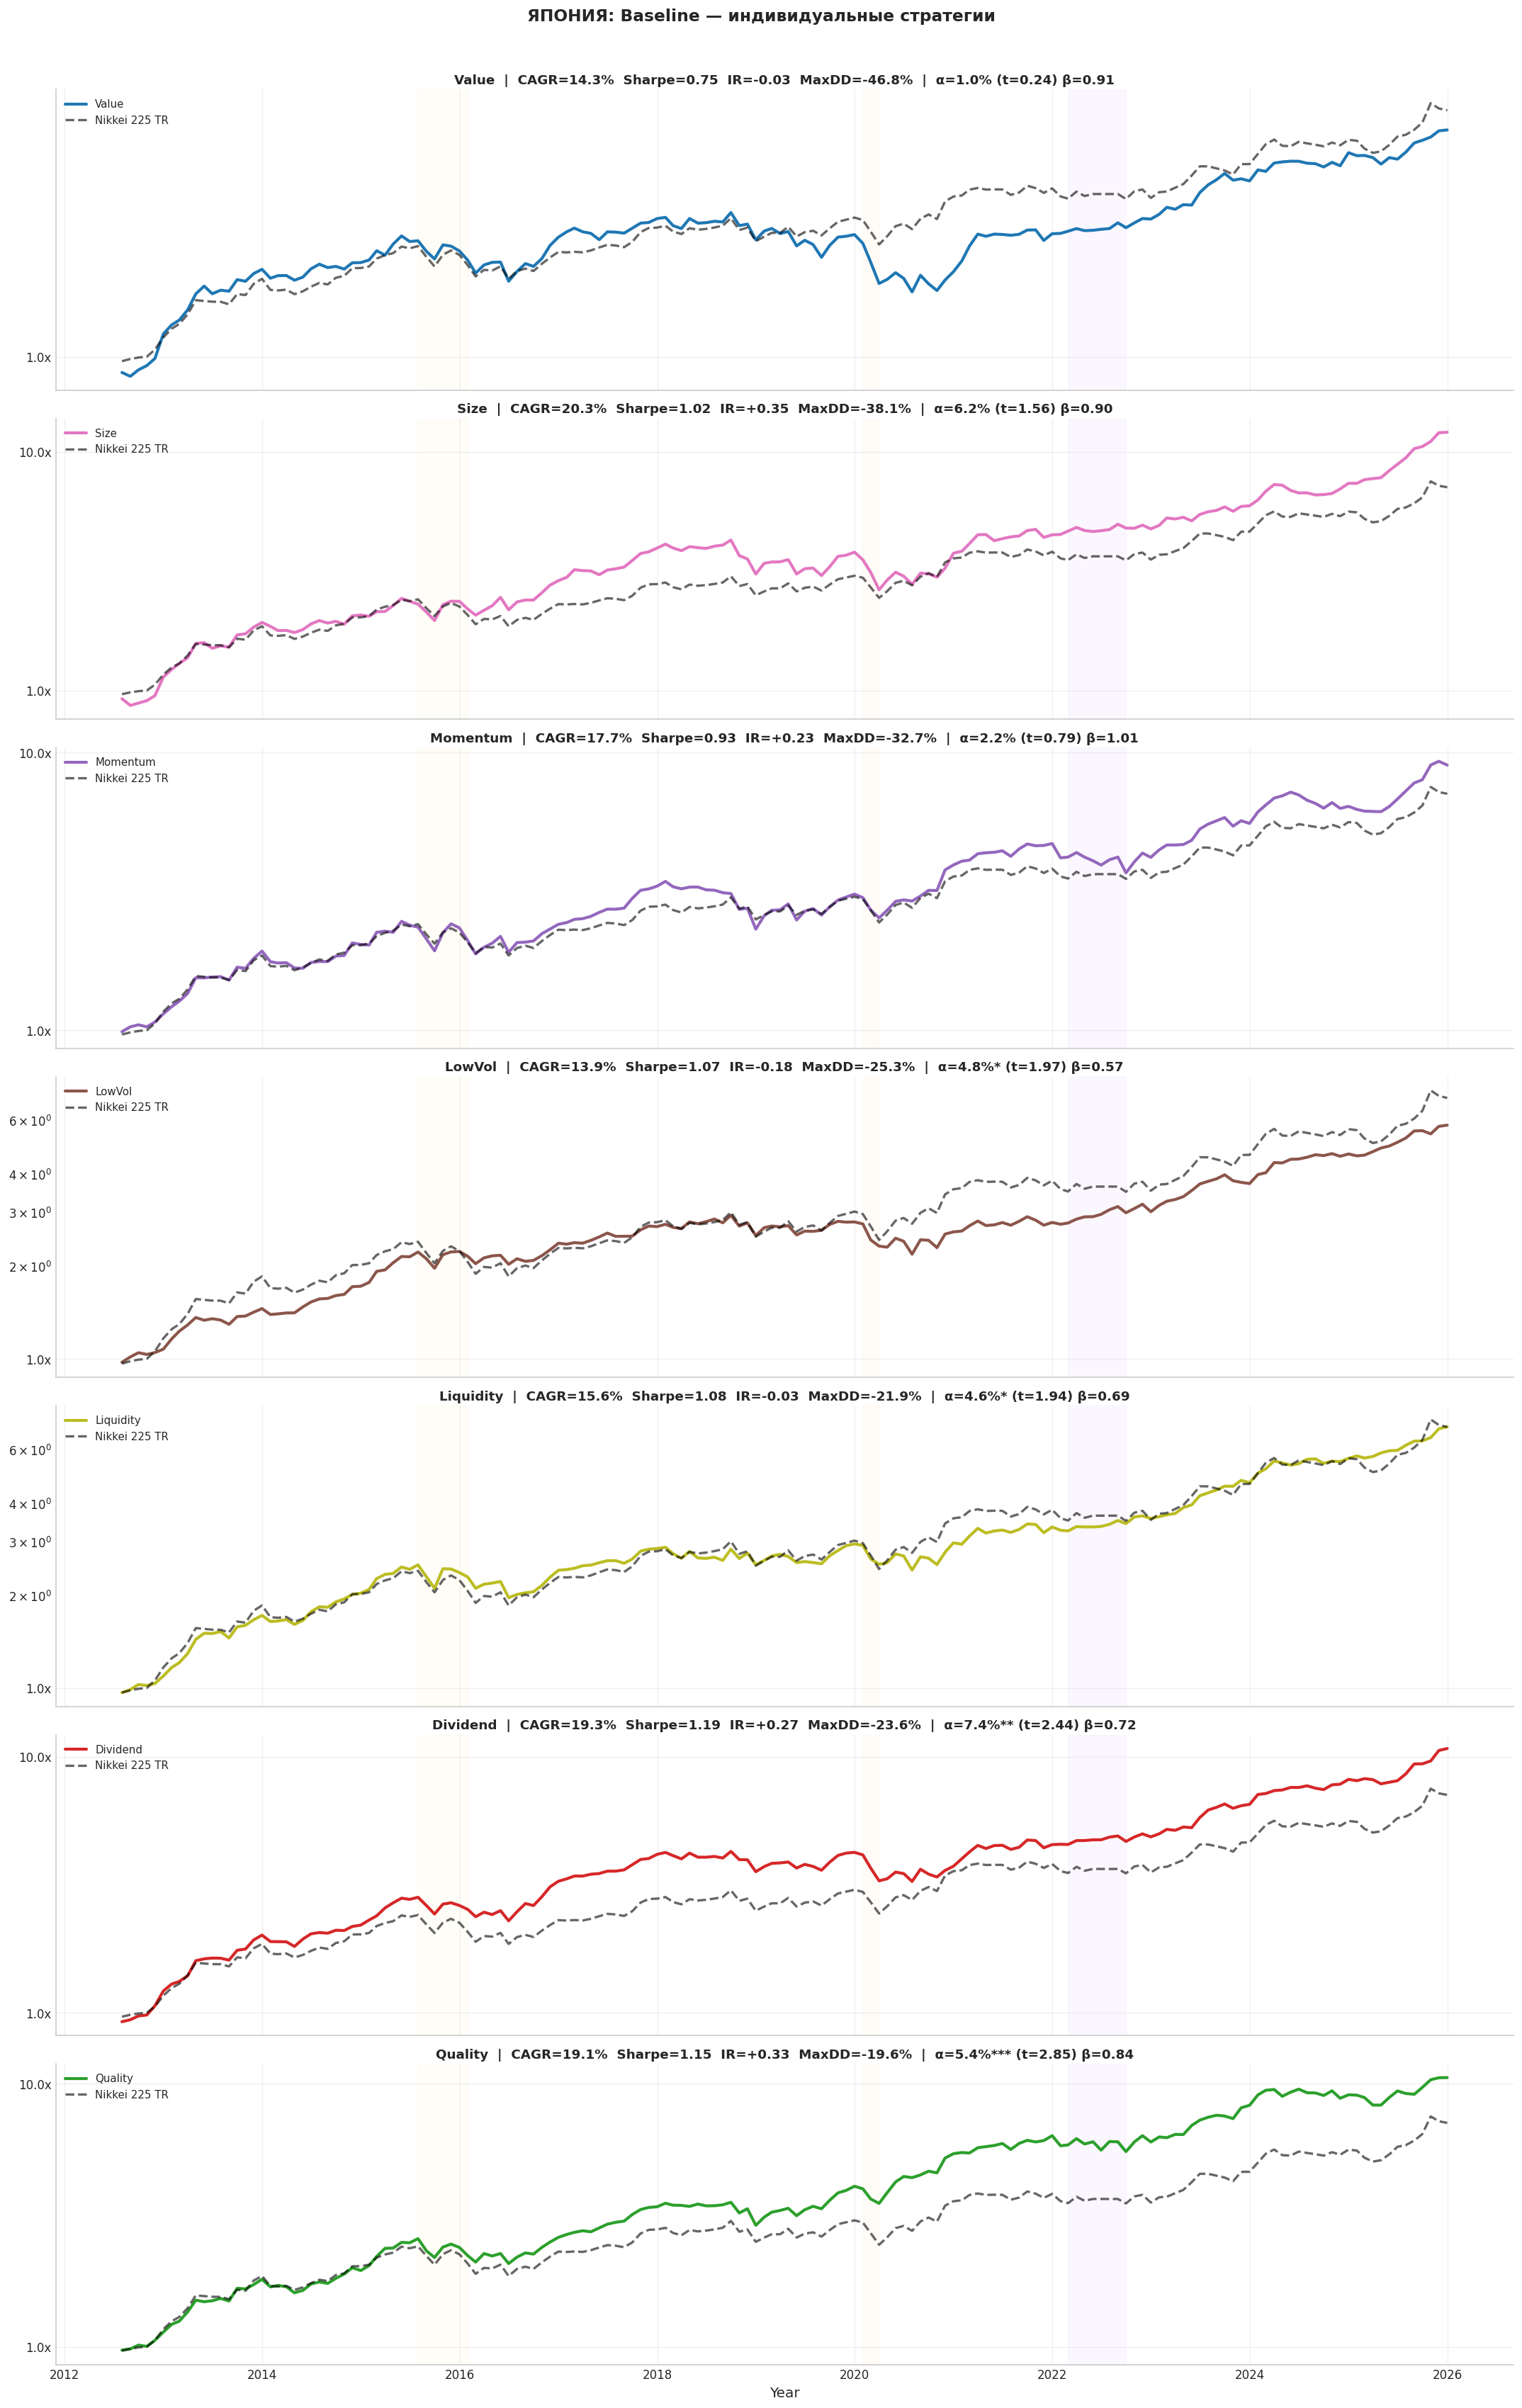

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/JP_Baseline_individual.png

  Baseline: СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК (по Sharpe ↓)


,Strategy,Country,N_months,Cumulative,CAGR,Vol,Sharpe,Sortino,IR,MaxDD,Excess,HitRate,Alpha,Beta,t_alpha,p_alpha
0,Dividend,JP,162,10.78x,19.3%,15.9%,1.19,1.82,0.27,-23.6%,+3.6%,67%,7.41%,0.72,2.44,0.0156
1,Quality,JP,162,10.55x,19.1%,16.3%,1.15,1.74,0.33,-19.6%,+3.4%,65%,5.43%,0.84,2.85,0.0050
2,Liquidity,JP,162,7.11x,15.6%,14.4%,1.08,1.52,-0.03,-21.9%,+0.0%,68%,4.63%,0.69,1.94,0.0541
3,LowVol,JP,162,5.79x,13.9%,12.9%,1.07,1.49,-0.18,-25.3%,-1.7%,69%,4.80%,0.57,1.97,0.0500
4,Size,JP,162,12.07x,20.3%,20.0%,1.02,1.52,0.35,-38.1%,+4.6%,67%,6.15%,0.90,1.56,0.1211
5,Nikkei 225 TR,JP,162,7.10x,15.6%,16.6%,0.95,1.53,0.00,-22.9%,+0.0%,60%,—,—,—,—
6,Momentum,JP,162,9.01x,17.7%,19.6%,0.93,1.30,0.23,-32.7%,+2.1%,65%,2.15%,1.01,0.79,0.4293
7,Value,JP,162,6.07x,14.3%,20.6%,0.75,1.14,-0.03,-46.8%,-1.3%,62%,1.03%,0.91,0.24,0.8103
8,Dividend,RF,164,8.28x,16.7%,20.5%,0.40,0.54,0.39,-33.9%,+5.3%,63%,5.25%,0.84,1.39,0.1676
9,Size,RF,164,8.98x,17.4%,27.5%,0.38,0.65,0.32,-39.2%,+6.0%,55%,7.13%,0.89,1.27,0.2062



  Baseline: ЭКОНОМЕТРИЧЕСКАЯ ТАБЛИЦА (по значимости α ↑)
  Raw: Rp = α + β·Rm + ε  |  CAPM: (Rp−Rf) = α + β·(Rm−Rf) + ε
  Rf: РУОНИЯ (РФ) / JGB 10Y (JP)  |  HAC Newey-West (3 lags)


,Strategy,Country,N_months,beta_raw,alpha_raw_ann,R2_raw,beta_CAPM,alpha_Jensen_ann,t_alpha_CAPM,p_alpha_CAPM,sig,R2_CAPM
0,Quality,JP,162,0.843,5.45%,0.736,0.843,5.43%,2.85,0.0050,***,0.736
1,Dividend,JP,162,0.723,7.44%,0.572,0.723,7.41%,2.44,0.0156,**,0.572
2,LowVol,JP,162,0.567,4.85%,0.532,0.567,4.80%,1.97,0.0500,*,0.532
3,Liquidity,JP,162,0.688,4.67%,0.628,0.688,4.63%,1.94,0.0541,*,0.628
4,Size,JP,162,0.902,6.16%,0.564,0.902,6.15%,1.56,0.1211,,0.564
5,Dividend,RF,164,0.842,6.72%,0.685,0.843,5.25%,1.39,0.1676,,0.690
6,Size,RF,164,0.892,8.14%,0.428,0.894,7.13%,1.27,0.2062,,0.434
7,Value,RF,164,0.855,5.49%,0.615,0.855,4.14%,1.07,0.2864,,0.620
8,Momentum,JP,162,1.012,2.15%,0.735,1.012,2.15%,0.79,0.4293,,0.735
9,Momentum,RF,164,0.898,3.47%,0.581,0.903,2.50%,0.56,0.5731,,0.588


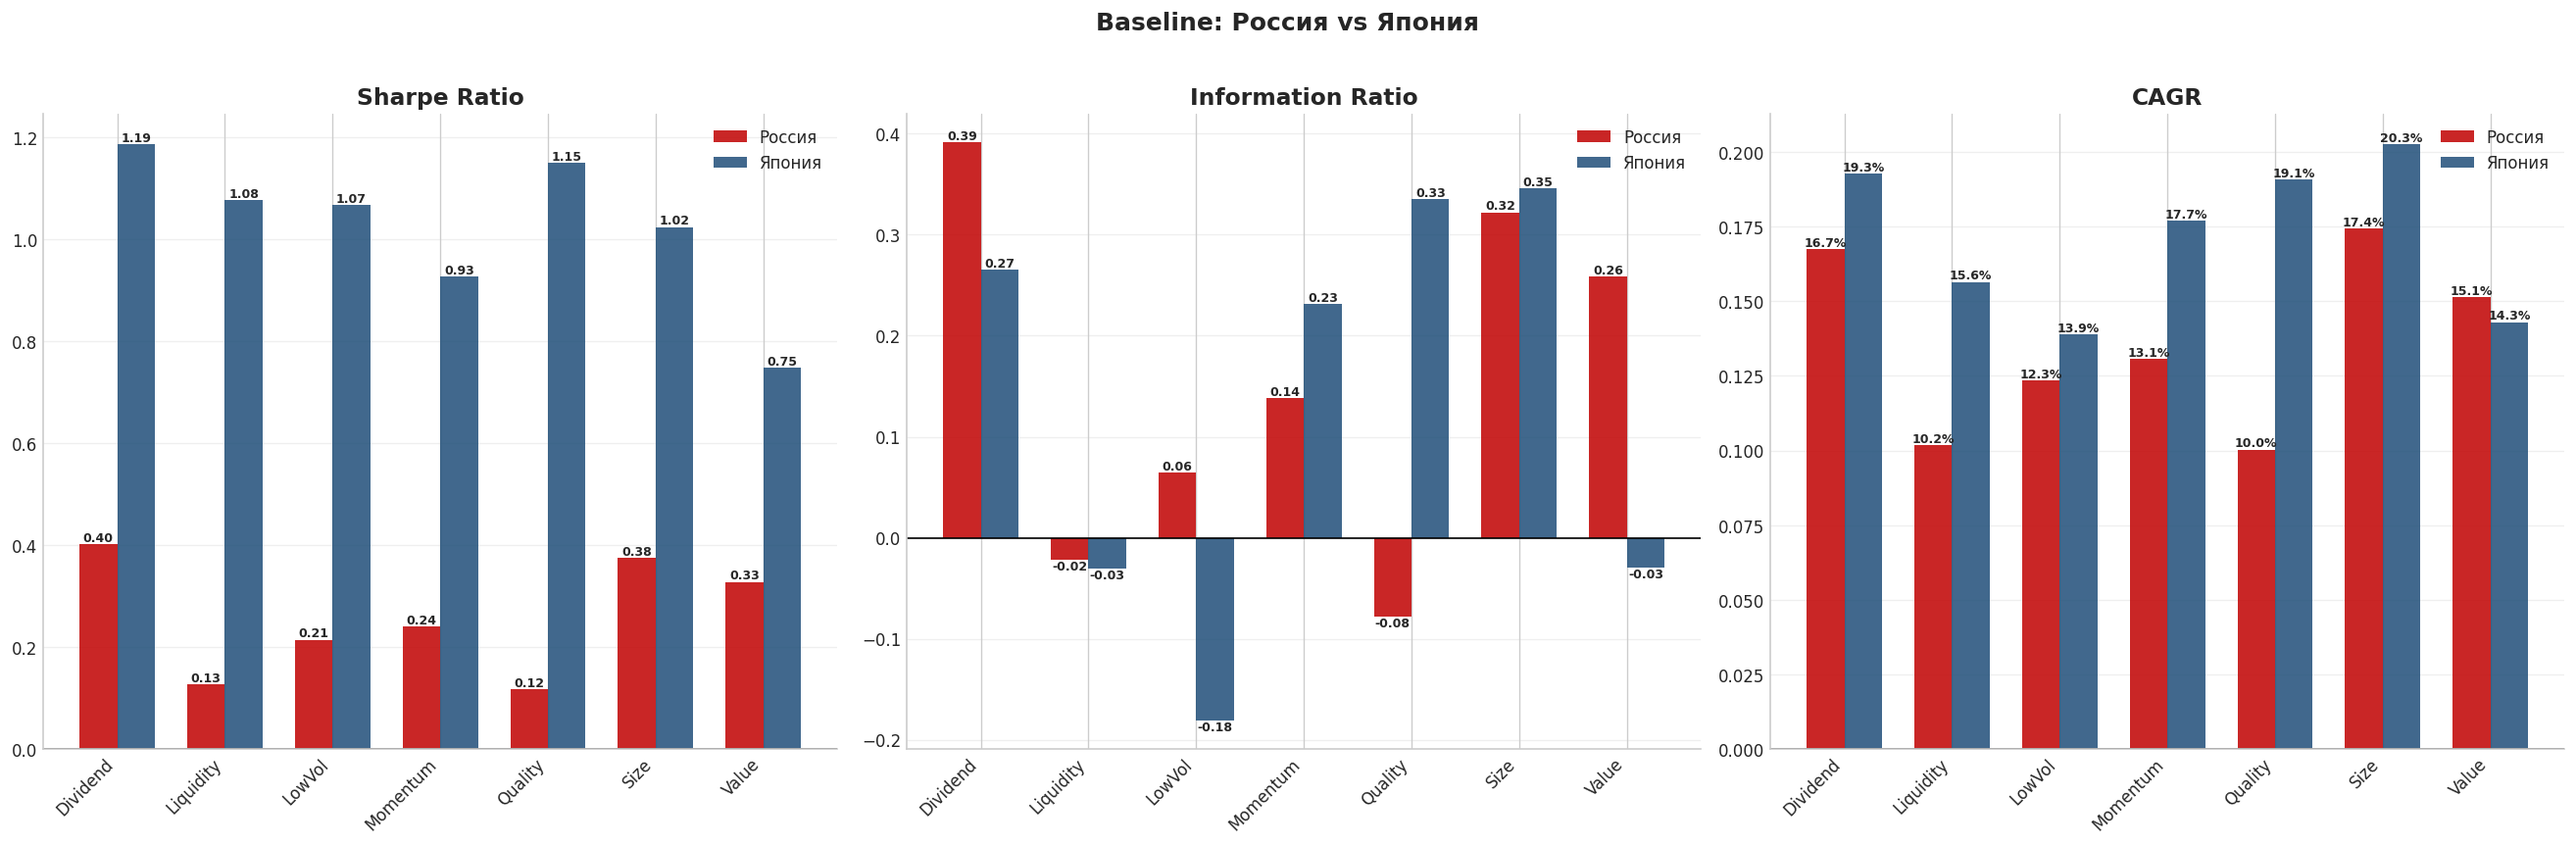

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/Baseline_comparison_bars.png


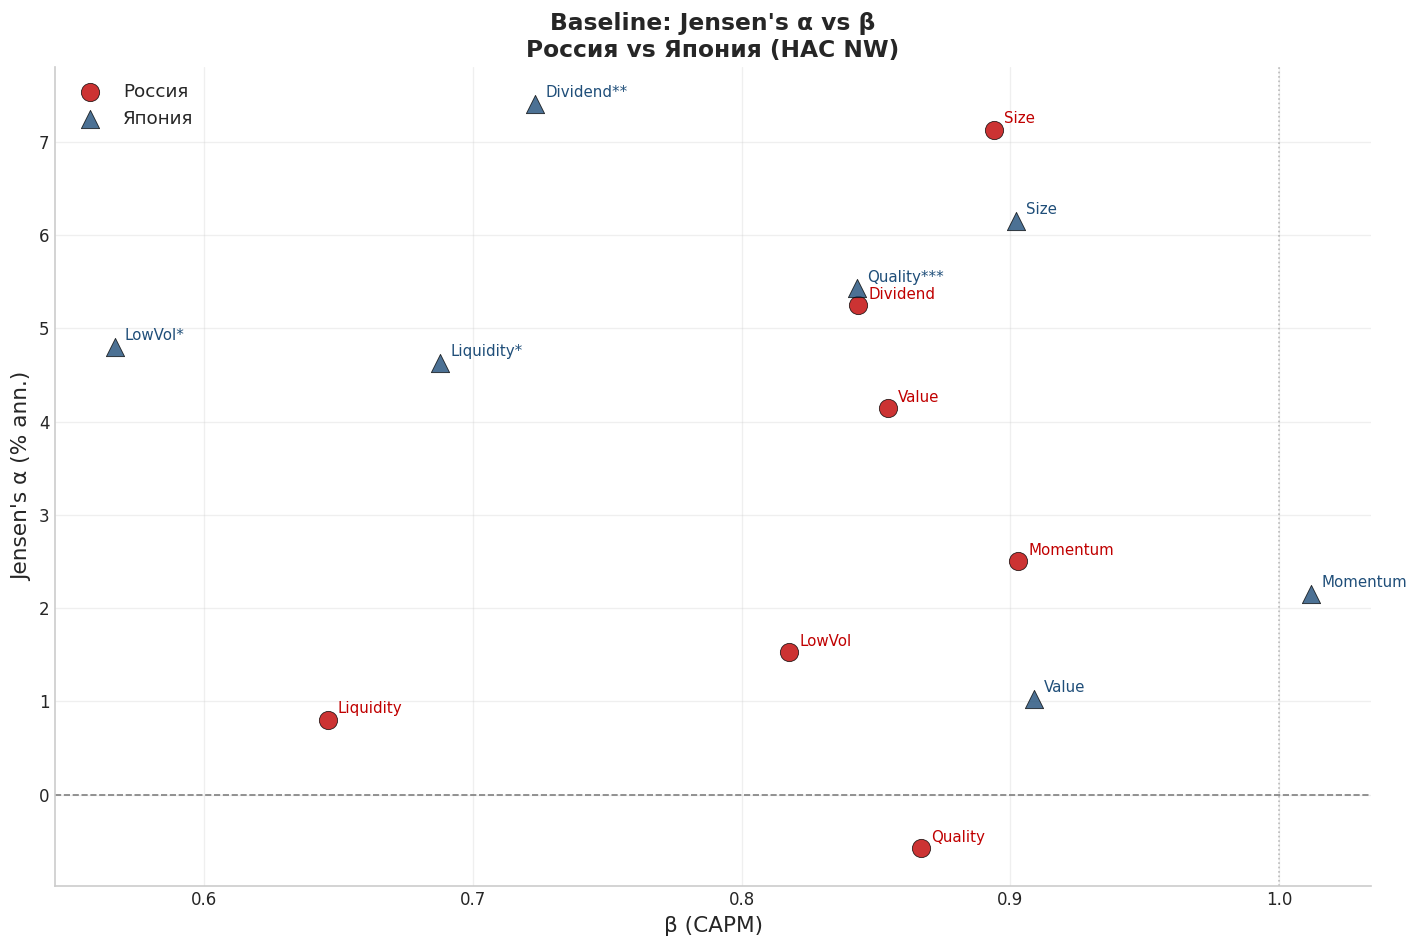

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/Baseline_alpha_scatter.png

  → Excel saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/PART_I_BASELINE_TABLES.xlsx


In [499]:
# ═══════════════════════════════════════════════════════════════════
# 7. RUN PART I — BASELINE
# ═══════════════════════════════════════════════════════════════════

print("=" * 80)
print("  ЧАСТЬ I: BASELINE FACTOR BACKTEST — РОССИЯ vs ЯПОНИЯ")
print("  7 факторов × 2 рынка = 14 бэктестов")
print("=" * 80)

baseline_results = {}

for label, cfg_fn in [('RF', cfg_rf), ('JP', cfg_jp)]:
    cfg = cfg_fn()
    dm = DataManager(cfg)
    dm.load()

    engine = FactorEngine(cfg, dm.panel, dm.prices, dm.benchmark, dm.rf)
    res = engine.run_all()

    if not res:
        print(f"  {label}: ни одна стратегия не сработала!")
        continue

    report = CountryReport(cfg, dm.benchmark, res, dm.rf, label='Baseline')
    baseline_results[label] = {'cfg': cfg, 'dm': dm, 'engine': engine, 'report': report}

if 'RF' in baseline_results and 'JP' in baseline_results:
    comp = ComparativeReport(baseline_results['RF']['report'],
                              baseline_results['JP']['report'], label='Baseline')
    mt_base, rt_base = comp.run_all()
    baseline_results['comparison'] = {'metrics': mt_base, 'regressions': rt_base}

# Save to Excel
try:
    with pd.ExcelWriter(os.path.join(OUT, 'PART_I_BASELINE_TABLES.xlsx')) as w:
        if 'comparison' in baseline_results:
            baseline_results['comparison']['metrics'].to_excel(w, 'Metrics_by_Sharpe', index=False)
            baseline_results['comparison']['regressions'].to_excel(w, 'Regressions_by_pvalue', index=False)
    print(f"\n  → Excel saved: {os.path.join(OUT, 'PART_I_BASELINE_TABLES.xlsx')}")
except Exception as e:
    print(f"  Excel save error: {e}")

# тут прям нашлась реальная ошибка выжившего ни одна компания не ушла делистинг, хотя по честному их там было 33 шт. это необходимо исправить и упадет соответственно шарп показатель по всем факторным стратегиям примерно на 0,2
и оценка значимости по 10 леткам японии исправить на 3м!!!!


## Промежуточный вывод по Части I

На основании базового бэктеста можно сделать ряд наблюдений:
- Какие факторы генерируют значимую alpha на каждом рынке
- Как отличается факторная структура РФ vs JP
- **Quality** как один из факторов — заслуживает углублённого анализа,
  т.к. его состав неоднороден (profitability, safety, payout, governance)
  и может сильно варьироваться между рынками

→ Переходим к **ЧАСТИ II: Deep Quality Analysis**

---
# ═══════════════════════════════════════════════════════════
# ЧАСТЬ II: DEEP QUALITY ANALYSIS
# ═══════════════════════════════════════════════════════════

Ядро магистерской работы.

## Гипотеза H1
> Оптимальный набор компонентов Quality различается между Японией и Россией.

## Методология: Barra-style descriptor-level analysis

### 2.1 Конструирование Quality

Quality — не один показатель, а набор блоков:

| Блок | Описание | Дескрипторы |
|------|----------|-------------|
| **Profitability** | Рентабельность | ROE, ROA, Net Margin, EBITDA Margin, Gross Margin |
| **Growth** | Рост показателей | Revenue YoY, EBITDA YoY, Revenue CAGR 3Y |
| **Safety** | Финансовая устойчивость | D/E, ND/EBITDA, Interest Coverage, Equity Ratio |
| **Payout/CF** | Дивидисциплина + CF | FCF Yield, Payout, Div Streak, Cash Conversion |
| **Accruals** | Качество прибыли | Accruals Ratio, FCF/Net Profit |
| **Market-specific** | Страновые особенности | РФ: гос.доля, FCF discipline; JP: keiretsu, asset turnover |

### 2.2 Спецификации Quality

| Спецификация | Идея | Ключевые веса |
|---|---|---|
| **Q0** | Simple baseline | ROE + Margin + Leverage (равные веса) |
| **Q1** | Profitability-heavy | ROE(2x), ROA, Margins, Asset Turnover |
| **Q2** | Payout/CF-heavy | FCF Yield, Payout, Div Streak, Cash Conversion |
| **Q3** | Market-specific | РФ: div persistence, FCF, ownership; JP: keiretsu, R&D proxy, profitability growth |

In [502]:
# ═══════════════════════════════════════════════════════════════════
# 8. QUALITY SPECIFICATIONS (Q0–Q3)
# ═══════════════════════════════════════════════════════════════════

# --- Q0: Simple baseline Quality ---
RF_Q0 = {
    'nonbank': {'roe_pct':(+1,1.0), 'net_margin_pct':(+1,1.0), 'net_debt_to_ebitda':(-1,1.0)},
    'bank':    {'roe_pct':(+1,1.0), 'nim_pct':(+1,1.0), 'npl_ratio_pct':(-1,1.0)},
}
JP_Q0 = {
    'nonbank': {'roe_pct':(+1,1.0), 'net_margin_pct':(+1,1.0), 'net_debt_to_ebitda':(-1,1.0)},
    # bank_roe убран — дублирует roe_pct; добавлен bank_nim
    'bank':    {'roe_pct':(+1,1.5), 'bank_npl':(-1,1.0), 'bank_nim':(+1,0.8)},
}

# --- Q1: Profitability-heavy ---
RF_Q1 = {
    'nonbank': {'roe_pct':(+1,2.0), 'roa_pct':(+1,1.0), 'net_margin_pct':(+1,1.5),
                'ebitda_margin_pct':(+1,1.0), 'accruals_ratio':(-1,0.8)},
    'bank':    {'roe_pct':(+1,2.0), 'roa_pct':(+1,1.0), 'nim_pct':(+1,1.5),
                'cost_of_risk_pct':(-1,1.0)},
}
JP_Q1 = {
    'nonbank': {'roe_pct':(+1,2.0), 'roa_pct':(+1,1.0), 'net_margin_pct':(+1,1.5),
                'ebitda_margin_pct':(+1,1.0), 'gross_profit_margin_pct':(+1,1.0),
                'asset_turnover':(+1,0.8), 'accruals_ratio':(-1,0.8)},
    # bank_roe убран — дублирует roe_pct
    'bank':    {'roe_pct':(+1,2.0), 'bank_nim':(+1,1.0),
                'bank_cost_income':(-1,1.0)},
}

# --- Q2: Payout / Cash-Flow-heavy ---
RF_Q2 = {
    'nonbank': {'fcf_yield_pct':(+1,2.0), 'payout_ratio_pct':(+1,1.0),
                'cash_conversion':(+1,1.0), 'div_streak':(+1,1.5),
                'fcf_to_net_profit':(+1,1.0), 'div_paid_flag':(+1,0.5)},
    'bank':    {'div_yield_pct':(+1,2.0), 'payout_ratio_pct':(+1,1.0),
                'div_streak':(+1,1.5), 'roe_pct':(+1,0.5)},
}
JP_Q2 = {
    'nonbank': {'fcf_yield_pct':(+1,2.0), 'payout_ratio_pct':(+1,1.0),
                'cash_conversion':(+1,1.0), 'buyback_yield_pct':(+1,1.5),
                'total_shareholder_yield_pct':(+1,1.5), 'fcf_to_net_profit':(+1,1.0)},
    'bank':    {'div_yield_pct':(+1,2.0), 'buyback_yield_pct':(+1,1.5),
                'payout_ratio_pct':(+1,1.0)},
}

# --- Q3: Market-specific ---
RF_Q3 = {
    # interest_coverage убран — 0 non-null во ВСЕХ годах панели.
    # Заменён на net_debt_to_ebitda (доступен с 2011, 110+ значений/год).
    'nonbank': {'roe_pct':(+1,1.0), 'fcf_yield_pct':(+1,2.0),
                'div_streak':(+1,1.5), 'div_growth_streak':(+1,1.0),
                'payout_ratio_pct':(+1,1.0), 'cash_conversion':(+1,0.8),
                'net_debt_to_ebitda':(-1,0.8), 'equity_to_assets_pct':(+1,0.7),
                'accruals_ratio':(-1,0.7)},
    'bank':    {'roe_pct':(+1,1.5), 'nim_pct':(+1,1.0),
                'coverage_ratio_pct':(+1,1.0), 'npl_ratio_pct':(-1,1.0),
                'div_streak':(+1,1.0)},
}
JP_Q3 = {
    'nonbank': {'roe_pct':(+1,1.5), 'roe_yoy_pct':(+1,1.0),
                'asset_turnover':(+1,1.2), 'gross_profit_margin_pct':(+1,1.0),
                'fcf_yield_pct':(+1,1.0), 'buyback_yield_pct':(+1,1.2),
                'equity_ratio':(+1,0.8), 'accruals_ratio':(-1,0.7),
                'cash_conversion':(+1,0.8)},
    'bank':    {'bank_roe':(+1,1.5), 'bank_nim':(+1,1.0),
                'bank_cost_income':(-1,1.0), 'buyback_yield_pct':(+1,1.0),
                'bank_coverage':(+1,0.8)},
}

QUALITY_SPECS = {
    'RF': {'Q0': RF_Q0, 'Q1': RF_Q1, 'Q2': RF_Q2, 'Q3': RF_Q3},
    'JP': {'Q0': JP_Q0, 'Q1': JP_Q1, 'Q2': JP_Q2, 'Q3': JP_Q3},
}

QUALITY_LABELS = {
    'Q0': 'Simple Baseline Quality',
    'Q1': 'Profitability-Heavy',
    'Q2': 'Payout / Cash-Flow-Heavy',
    'Q3': 'Market-Specific Quality',
}

## 9. Quality Engine — бэктест Q0–Q3

Запускаем 4 спецификации Quality для каждого рынка:
- **Q0**: простой baseline (ROE + Margin + Leverage)
- **Q1**: profitability-heavy (ROE×2, ROA, все маржи)
- **Q2**: payout/CF-heavy (FCF Yield, Payout, Div Streak, Cash Conversion)
- **Q3**: market-specific (разные компоненты для РФ и JP)

In [504]:
# ═══════════════════════════════════════════════════════════════════
# 9. RUN QUALITY SPECIFICATIONS
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("  ЧАСТЬ II: DEEP QUALITY ANALYSIS — Q0, Q1, Q2, Q3")
print("=" * 80)

quality_results = {}

for label in ['RF', 'JP']:
    if label not in baseline_results:
        continue
    br = baseline_results[label]
    cfg = br['cfg']
    dm = br['dm']
    specs = QUALITY_SPECS[label]

    # Create new engine with Q0-Q3 strategies
    q_strategies = {}
    for qname, qspec in specs.items():
        q_strategies[qname] = qspec

    cfg_q = Config(
        country=cfg.country, flag=cfg.flag,
        panel_path=cfg.panel_path, prices_path=cfg.prices_path,
        prices_format=cfg.prices_format,
        benchmark_path=cfg.benchmark_path, rf_path=cfg.rf_path,
        ticker_col=cfg.ticker_col, year_col=cfg.year_col,
        sector_col=cfg.sector_col,
        start_year=cfg.start_year, max_year=cfg.max_year,
        rebalance_month=cfg.rebalance_month,
        top_n=cfg.top_n, tc_bps=cfg.tc_bps,
        min_market_cap=cfg.min_market_cap,
        bank_sectors=cfg.bank_sectors,
        strategies=q_strategies,
        crises=cfg.crises,
        benchmark_name=cfg.benchmark_name,
    )

    engine_q = FactorEngine(cfg_q, dm.panel, dm.prices, dm.benchmark, dm.rf)
    res_q = engine_q.run_all()

    if not res_q:
        print(f"  {label}: Quality strategies failed!")
        continue

    report_q = CountryReport(cfg_q, dm.benchmark, res_q, dm.rf, label='Quality')
    quality_results[label] = {'cfg': cfg_q, 'engine': engine_q, 'report': report_q, 'dm': dm}


  ЧАСТЬ II: DEEP QUALITY ANALYSIS — Q0, Q1, Q2, Q3

 🇷🇺 RF Запуск baseline стратегий:
  Q0              | CAGR=+12.8% | Sharpe=+0.21 | IR=+0.07 | MaxDD=-41.4% | 165 мес.
  Q1              | CAGR=+8.5% | Sharpe=+0.02 | IR=-0.28 | MaxDD=-44.5% | 165 мес.
  Q2              | CAGR=+15.6% | Sharpe=+0.34 | IR=+0.30 | MaxDD=-28.8% | 165 мес.
  Q3              | CAGR=+17.7% | Sharpe=+0.42 | IR=+0.42 | MaxDD=-31.5% | 165 мес.
  🇷🇺 RF Quality: единый период = 2012-05-31 – 2025-12-31 (164 мес.)
  регрессий = 4 (все на 164 мес.)

 🇯🇵 JP Запуск baseline стратегий:
  Q0              | CAGR=+20.5% | Sharpe=+1.18 | IR=+0.45 | MaxDD=-20.8% | 163 мес.
  Q1              | CAGR=+20.4% | Sharpe=+1.21 | IR=+0.44 | MaxDD=-18.3% | 163 мес.
  Q2              | CAGR=+18.0% | Sharpe=+1.05 | IR=+0.15 | MaxDD=-31.6% | 163 мес.
  Q3              | CAGR=+18.2% | Sharpe=+1.10 | IR=+0.21 | MaxDD=-22.9% | 163 мес.
  🇯🇵 JP Quality: единый период = 2012-07-31 – 2025-12-31 (162 мес.)
  регрессий = 4 (все на 162 мес.)


  Q2              | CAGR=+15.6% | Sharpe=+0.34 | IR=+0.30 | MaxDD=-28.8% | 165 мес.


  Q3              | CAGR=+17.7% | Sharpe=+0.42 | IR=+0.42 | MaxDD=-31.5% | 165 мес.
  🇷🇺 RF Quality: единый период = 2012-05-31 – 2025-12-31 (164 мес.)
  регрессий = 4 (все на 164 мес.)

 🇯🇵 JP Запуск baseline стратегий:


  Q0              | CAGR=+20.5% | Sharpe=+1.15 | IR=+0.45 | MaxDD=-20.8% | 163 мес.


  Q1              | CAGR=+20.4% | Sharpe=+1.16 | IR=+0.44 | MaxDD=-18.3% | 163 мес.


  Q2              | CAGR=+18.0% | Sharpe=+0.96 | IR=+0.15 | MaxDD=-31.6% | 163 мес.


  Q3              | CAGR=+18.2% | Sharpe=+1.05 | IR=+0.21 | MaxDD=-22.9% | 163 мес.
  🇯🇵 JP Quality: единый период = 2012-07-31 – 2025-06-30 (156 мес.)
  регрессий = 4 (все на 156 мес.)


## 10. Quality: графики и таблицы

Для каждого рынка:
1. Кумулятивный график Q0–Q3 vs benchmark
2. Индивидуальные панели Q0–Q3
3. Таблицы метрик (sorted by Sharpe)
4. Таблицы регрессий (sorted by p-value)

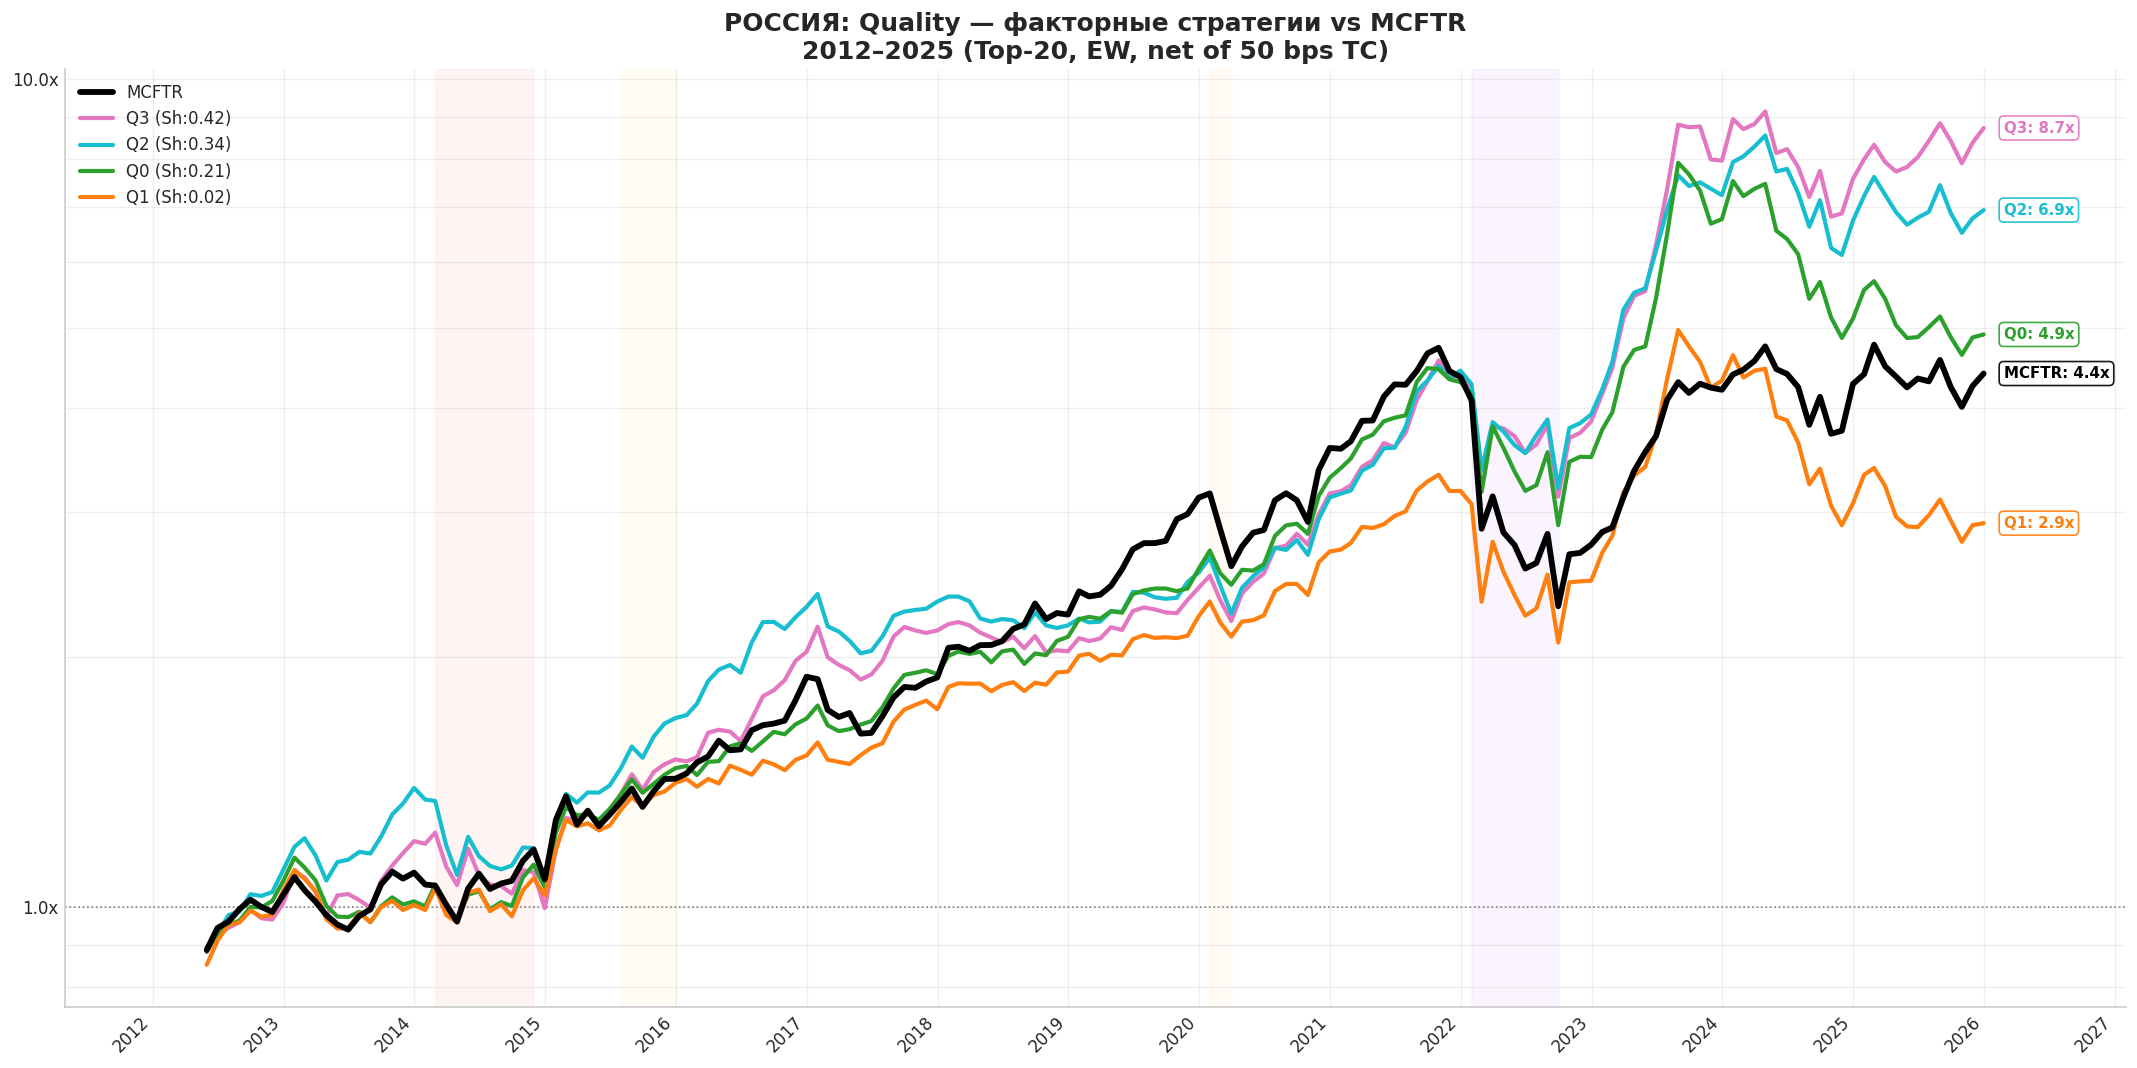

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/RF_Quality_cumulative.png


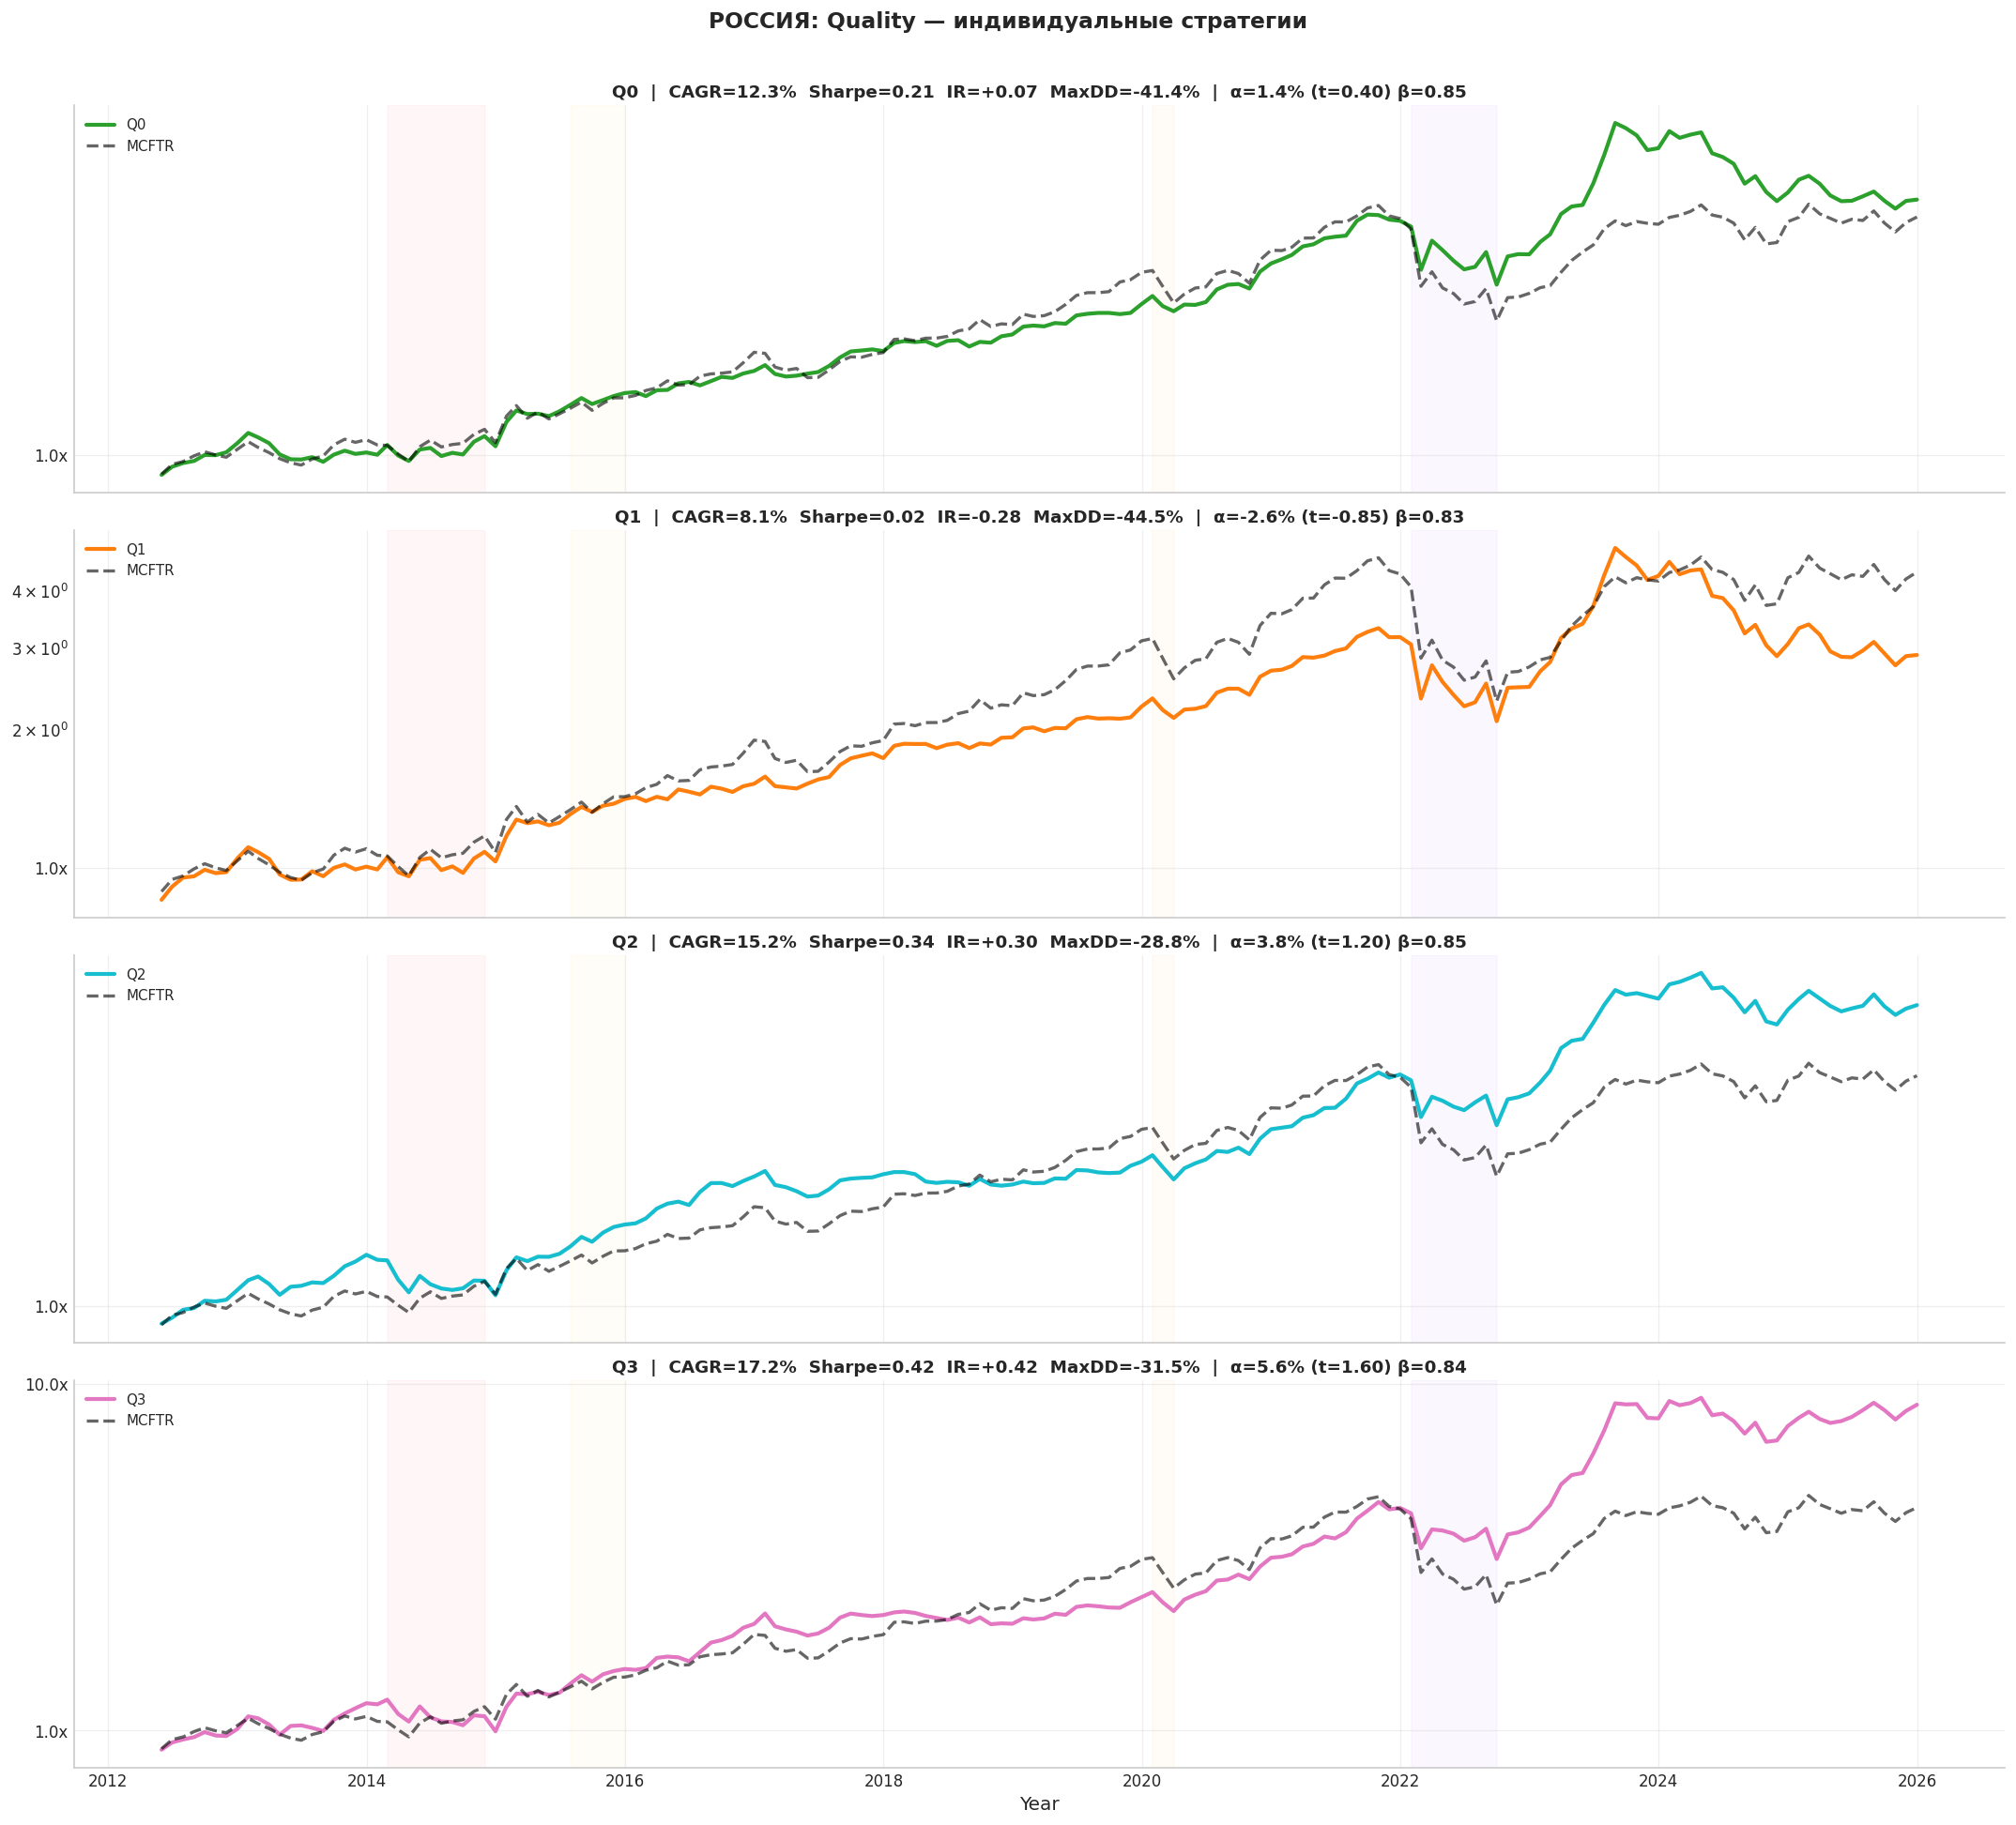

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/RF_Quality_individual.png


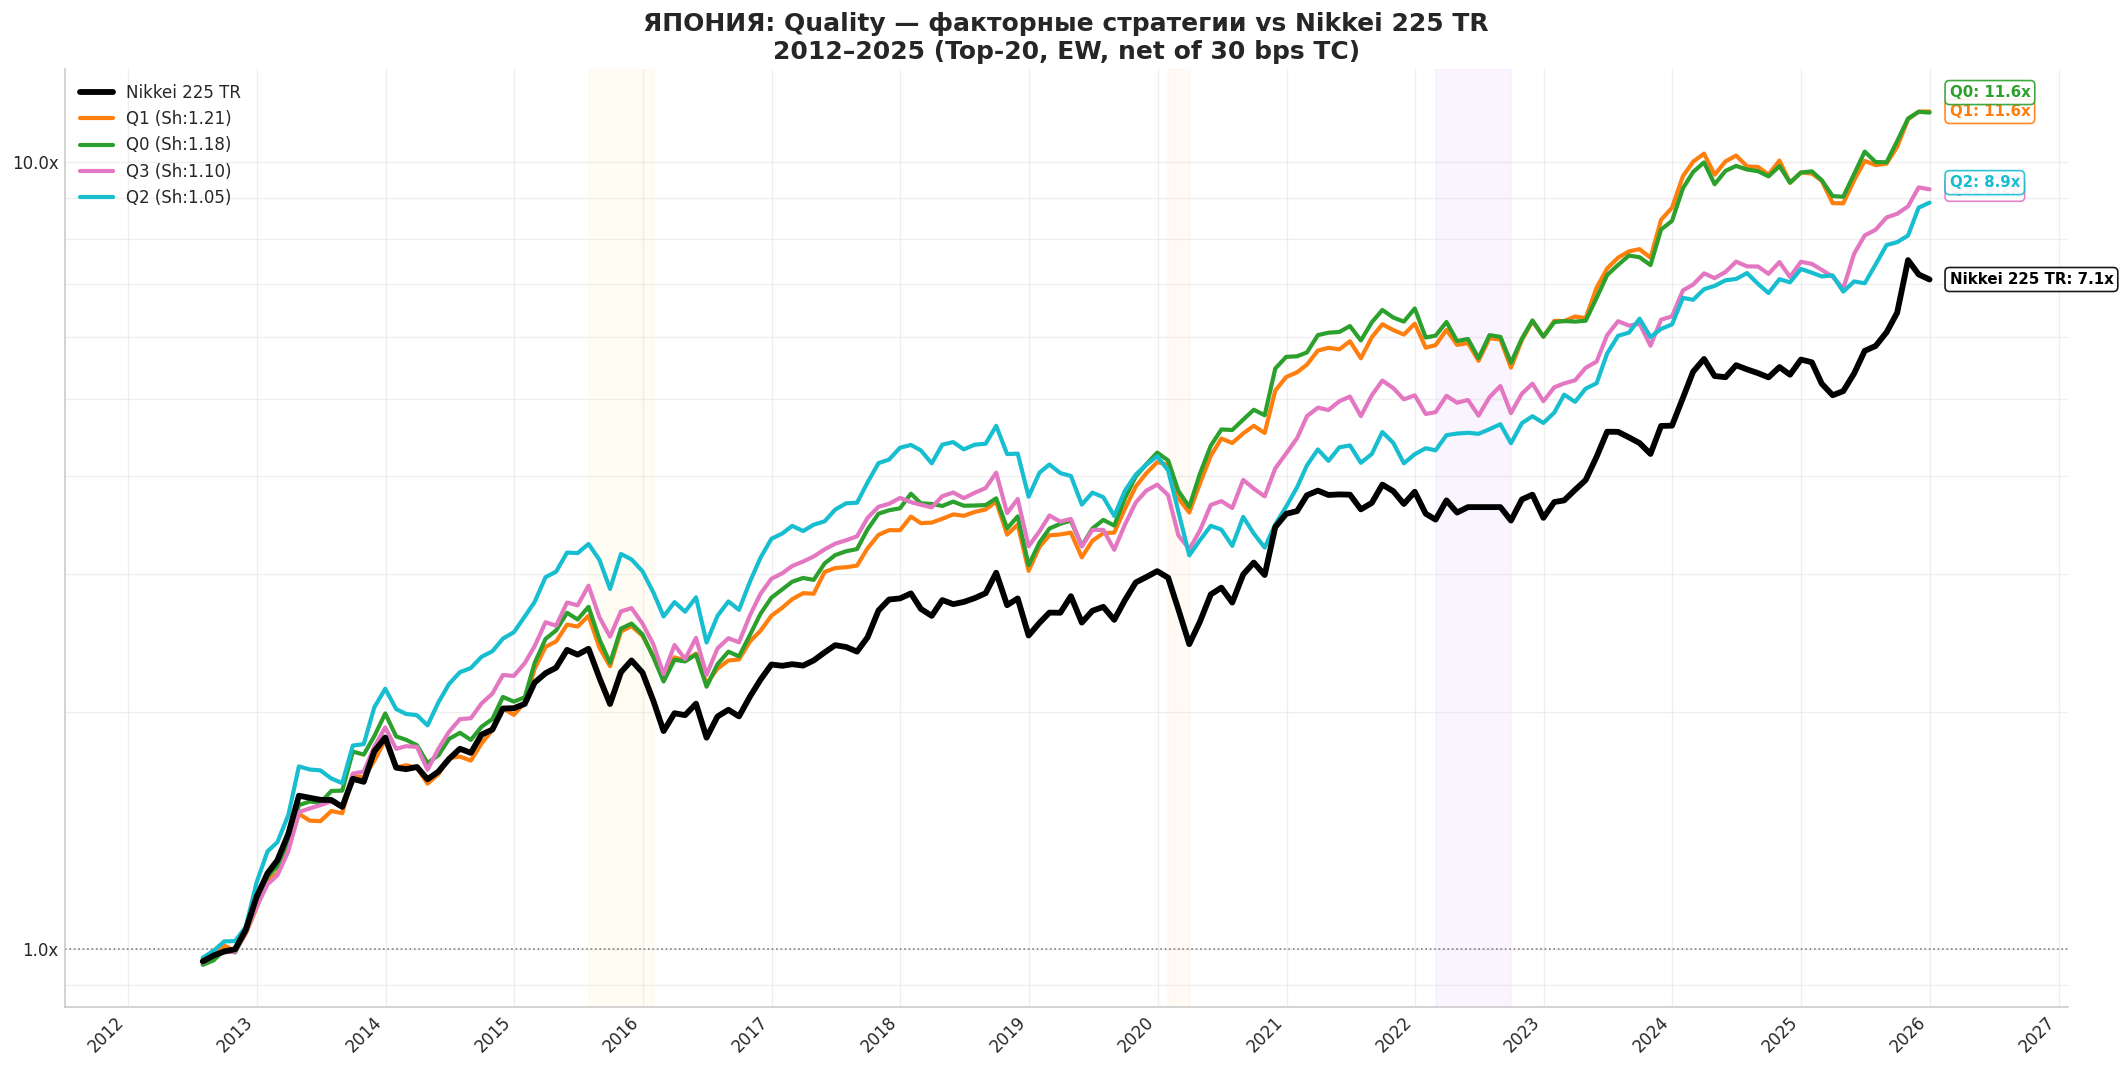

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/JP_Quality_cumulative.png


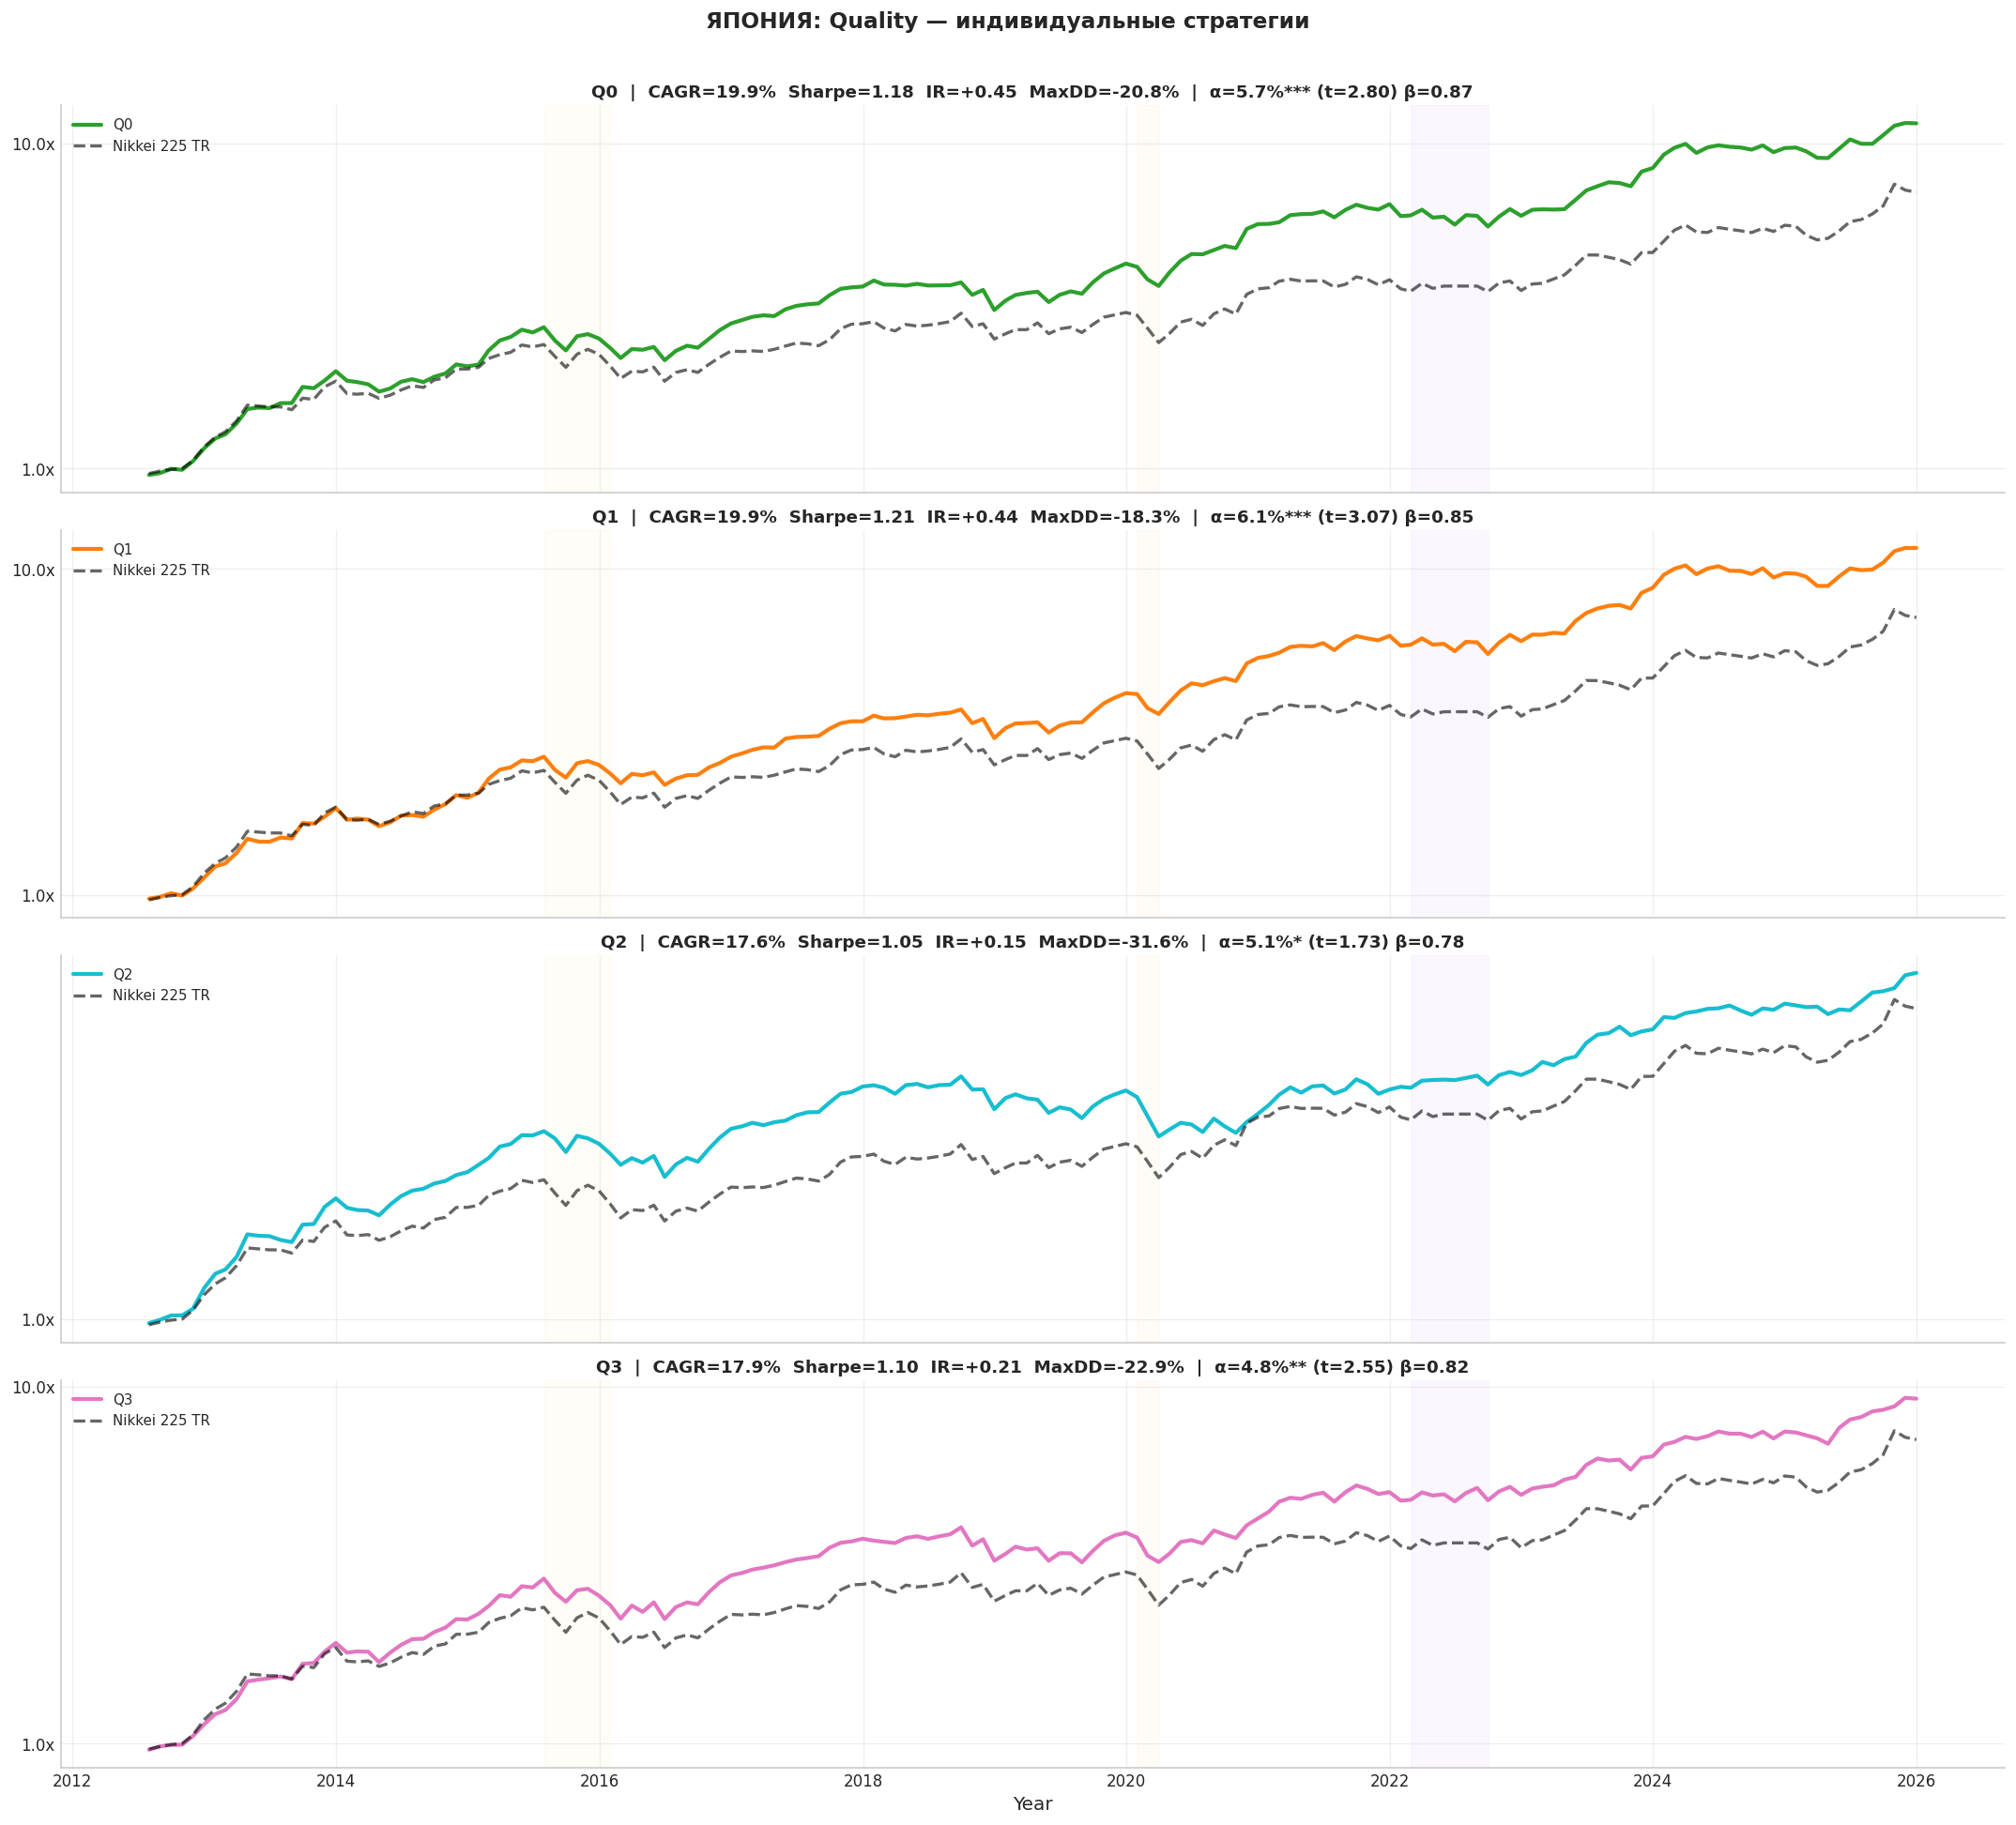

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/JP_Quality_individual.png

  Quality: СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК (по Sharpe ↓)


,Strategy,Country,N_months,Cumulative,CAGR,Vol,Sharpe,Sortino,IR,MaxDD,Excess,HitRate,Alpha,Beta,t_alpha,p_alpha
0,Q1,JP,162,11.60x,19.9%,16.1%,1.21,1.79,0.44,-18.3%,+4.3%,67%,6.06%,0.85,3.07,0.0025
1,Q0,JP,162,11.57x,19.9%,16.5%,1.18,1.83,0.45,-20.8%,+4.3%,65%,5.70%,0.87,2.80,0.0058
2,Q3,JP,162,9.24x,17.9%,16.1%,1.10,1.61,0.21,-22.9%,+2.3%,68%,4.81%,0.82,2.55,0.0118
3,Q2,JP,162,8.89x,17.6%,16.7%,1.05,1.62,0.15,-31.6%,+1.9%,66%,5.15%,0.78,1.73,0.0857
4,Nikkei 225 TR,JP,162,7.10x,15.6%,16.6%,0.95,1.53,0.00,-22.9%,+0.0%,60%,—,—,—,—
5,Q3,RF,164,8.72x,17.2%,20.7%,0.42,0.59,0.42,-31.5%,+5.7%,61%,5.63%,0.84,1.60,0.1117
6,Q2,RF,164,6.94x,15.2%,20.0%,0.34,0.45,0.30,-28.8%,+3.8%,63%,3.80%,0.85,1.20,0.2318
7,Q0,RF,164,4.91x,12.3%,21.0%,0.21,0.29,0.07,-41.4%,+0.9%,63%,1.40%,0.85,0.40,0.6861
8,MCFTR,RF,164,4.40x,11.5%,20.2%,0.18,0.21,0.00,-51.3%,+0.0%,66%,—,—,—,—
9,Q1,RF,164,2.90x,8.1%,19.8%,0.02,0.03,-0.28,-44.5%,-3.3%,62%,-2.56%,0.83,-0.85,0.3974



  Quality: ЭКОНОМЕТРИЧЕСКАЯ ТАБЛИЦА (по значимости α ↑)
  Raw: Rp = α + β·Rm + ε  |  CAPM: (Rp−Rf) = α + β·(Rm−Rf) + ε
  Rf: РУОНИЯ (РФ) / JGB 10Y (JP)  |  HAC Newey-West (3 lags)


,Strategy,Country,N_months,beta_raw,alpha_raw_ann,R2_raw,beta_CAPM,alpha_Jensen_ann,t_alpha_CAPM,p_alpha_CAPM,sig,R2_CAPM
0,Q1,JP,162,0.845,6.08%,0.763,0.845,6.06%,3.07,0.0025,***,0.763
1,Q0,JP,162,0.871,5.71%,0.770,0.871,5.70%,2.80,0.0058,***,0.770
2,Q3,JP,162,0.818,4.83%,0.711,0.818,4.81%,2.55,0.0118,**,0.711
3,Q2,JP,162,0.783,5.17%,0.607,0.783,5.15%,1.73,0.0857,*,0.607
4,Q3,RF,164,0.843,7.10%,0.678,0.843,5.63%,1.60,0.1117,,0.682
5,Q2,RF,164,0.845,5.25%,0.732,0.848,3.80%,1.20,0.2318,,0.737
6,Q1,RF,164,0.819,-0.85%,0.696,0.825,-2.56%,-0.85,0.3974,,0.702
7,Q0,RF,164,0.848,2.85%,0.666,0.853,1.40%,0.40,0.6861,,0.673


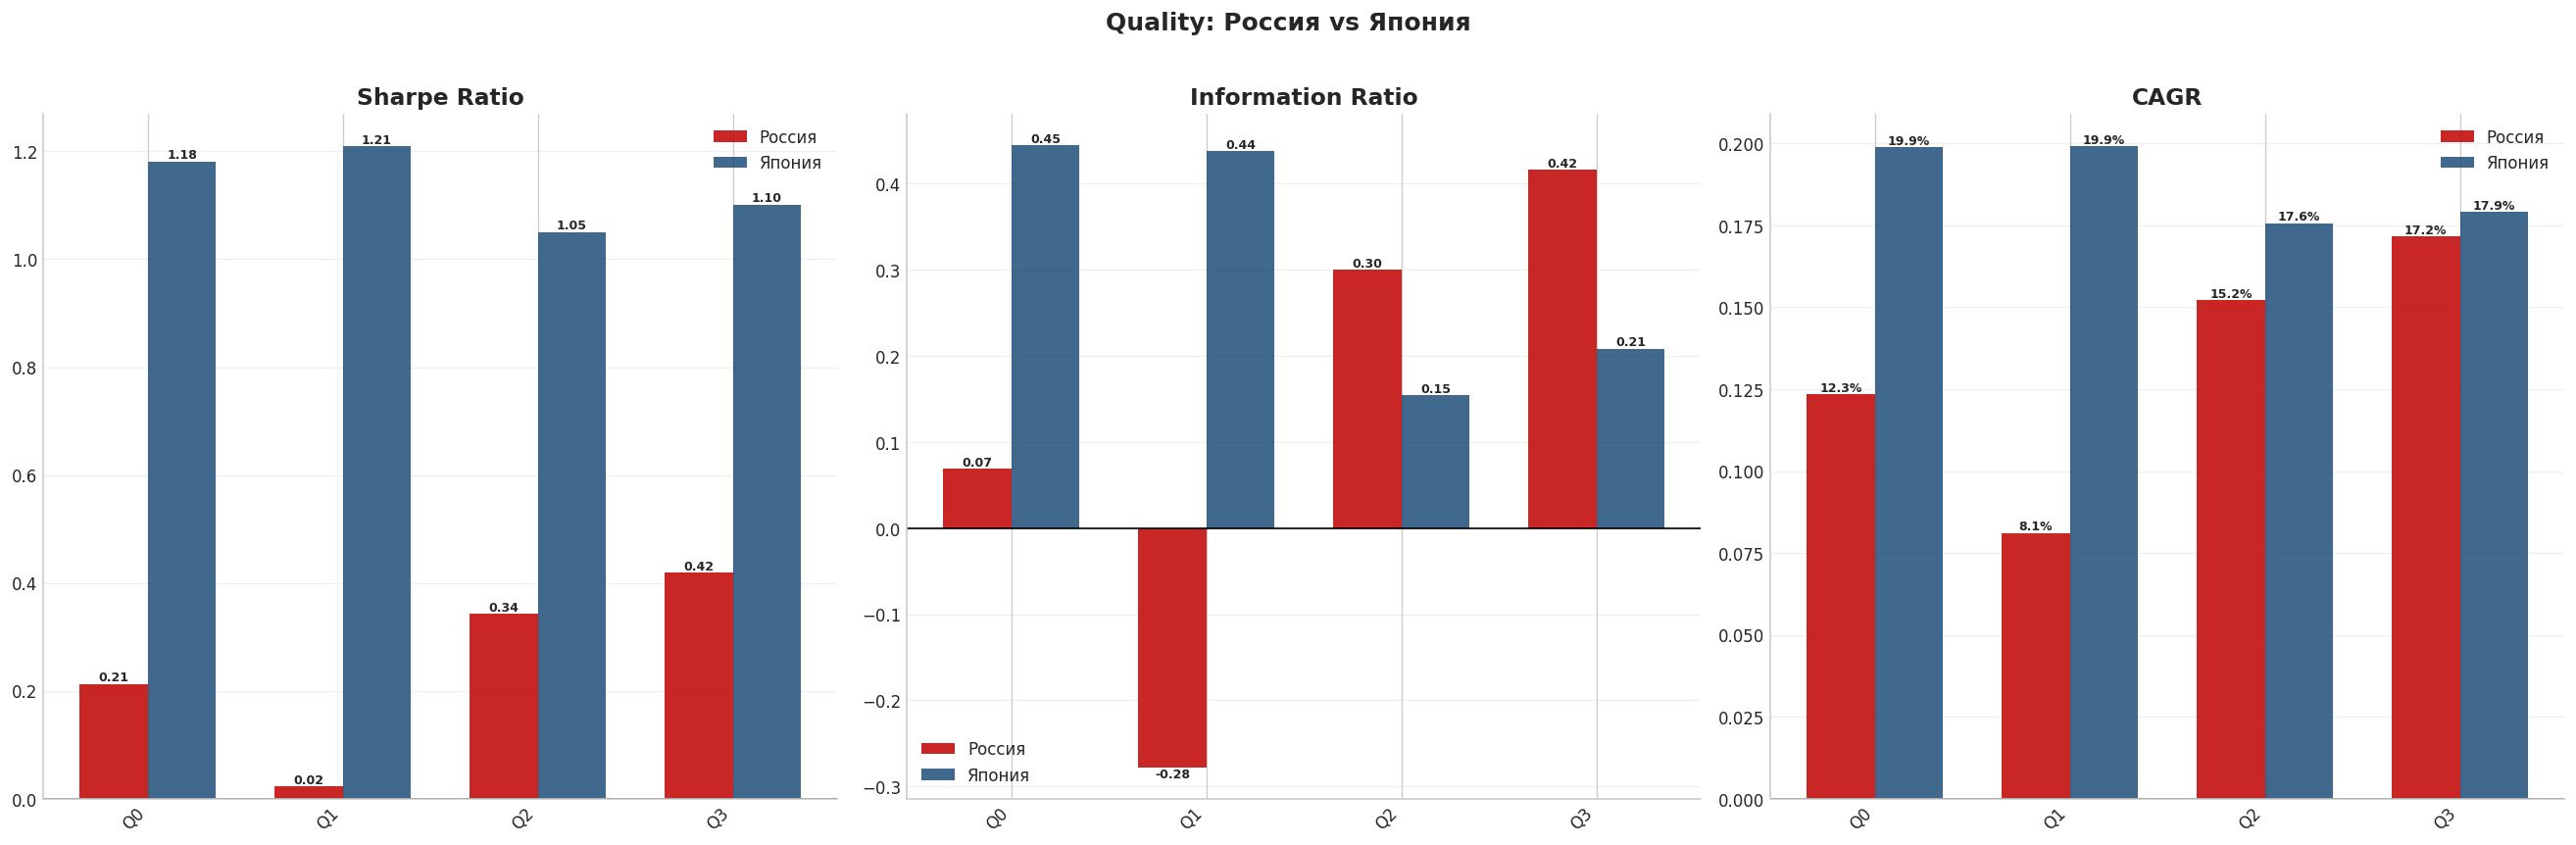

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/Quality_comparison_bars.png


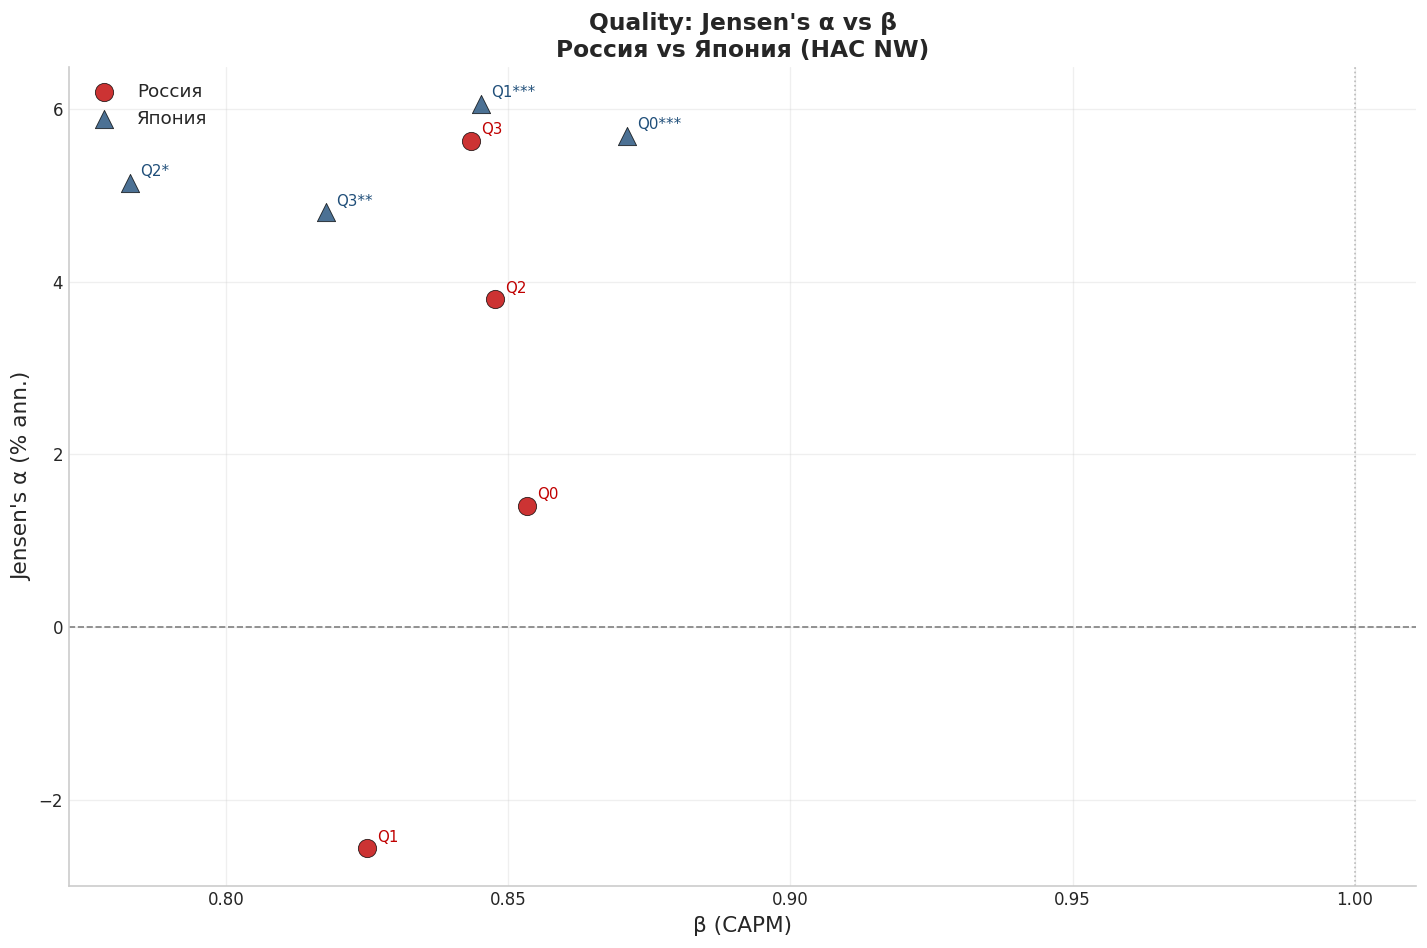

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/Quality_alpha_scatter.png

  → Excel saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/PART_II_QUALITY_TABLES.xlsx


In [506]:
# ═══════════════════════════════════════════════════════════════════
# 10. QUALITY CHARTS & TABLES
# ═══════════════════════════════════════════════════════════════════

if 'RF' in quality_results and 'JP' in quality_results:
    comp_q = ComparativeReport(quality_results['RF']['report'],
                                quality_results['JP']['report'], label='Quality')
    mt_q, rt_q = comp_q.run_all()
elif 'RF' in quality_results:
    rep = quality_results['RF']['report']
    rep.plot_summary()
    rep.plot_individual()
    mt_q = rep.metrics_table()
    rt_q = rep.reg_table()
elif 'JP' in quality_results:
    rep = quality_results['JP']['report']
    rep.plot_summary()
    rep.plot_individual()
    mt_q = rep.metrics_table()
    rt_q = rep.reg_table()

# Save
try:
    with pd.ExcelWriter(os.path.join(OUT, 'PART_II_QUALITY_TABLES.xlsx')) as w:
        if isinstance(mt_q, pd.DataFrame):
            mt_q.to_excel(w, 'Quality_Metrics_by_Sharpe', index=False)
        if isinstance(rt_q, pd.DataFrame):
            rt_q.to_excel(w, 'Quality_Regressions_by_pvalue', index=False)
    print(f"\n  → Excel saved: {os.path.join(OUT, 'PART_II_QUALITY_TABLES.xlsx')}")
except Exception as e:
    print(f"  Excel save error: {e}")

## 11. Descriptor-Level IC Analysis

Information Coefficient (IC) = Spearman rank correlation between
descriptor value at formation date and subsequent portfolio return.

Для каждого дескриптора Quality считаем:
- IC per year (cross-sectional rank correlation)
- Mean IC ± t-stat
- IC Information Ratio = mean(IC) / std(IC)

Это позволяет определить, какие именно компоненты Quality
вносят предсказательный вклад на каждом рынке.


  DESCRIPTOR-LEVEL IC ANALYSIS

  🇷🇺 RF RF:
            descriptor   mean_IC   std_IC      t_IC     p_IC sig     IC_IR  N_years  hit_rate
         fcf_yield_pct  0.126312 0.148961  3.172743 0.007343 ***  0.847951       14  0.785714
    net_debt_to_ebitda -0.081965 0.126140 -2.431299 0.030257  ** -0.649792       14  0.285714
     fcf_to_net_profit  0.056332 0.087767  2.401550 0.031992  **  0.641841       14  0.714286
        ebitda_yoy_pct  0.083326 0.125564  2.392706 0.033967  **  0.663617       13  0.692308
       cash_conversion  0.073679 0.111919  2.280497 0.043498  **  0.658323       12  0.583333
               roa_pct  0.089522 0.149270  2.243981 0.042881  **  0.599729       14  0.785714
         div_yield_pct  0.091633 0.144023  2.203991 0.049738  **  0.636237       12  0.750000
               roe_pct  0.084032 0.147729  2.128363 0.053007   *  0.568829       14  0.785714
        debt_to_equity -0.052718 0.116346 -1.695409 0.113800     -0.453117       14  0.428571
        accrual

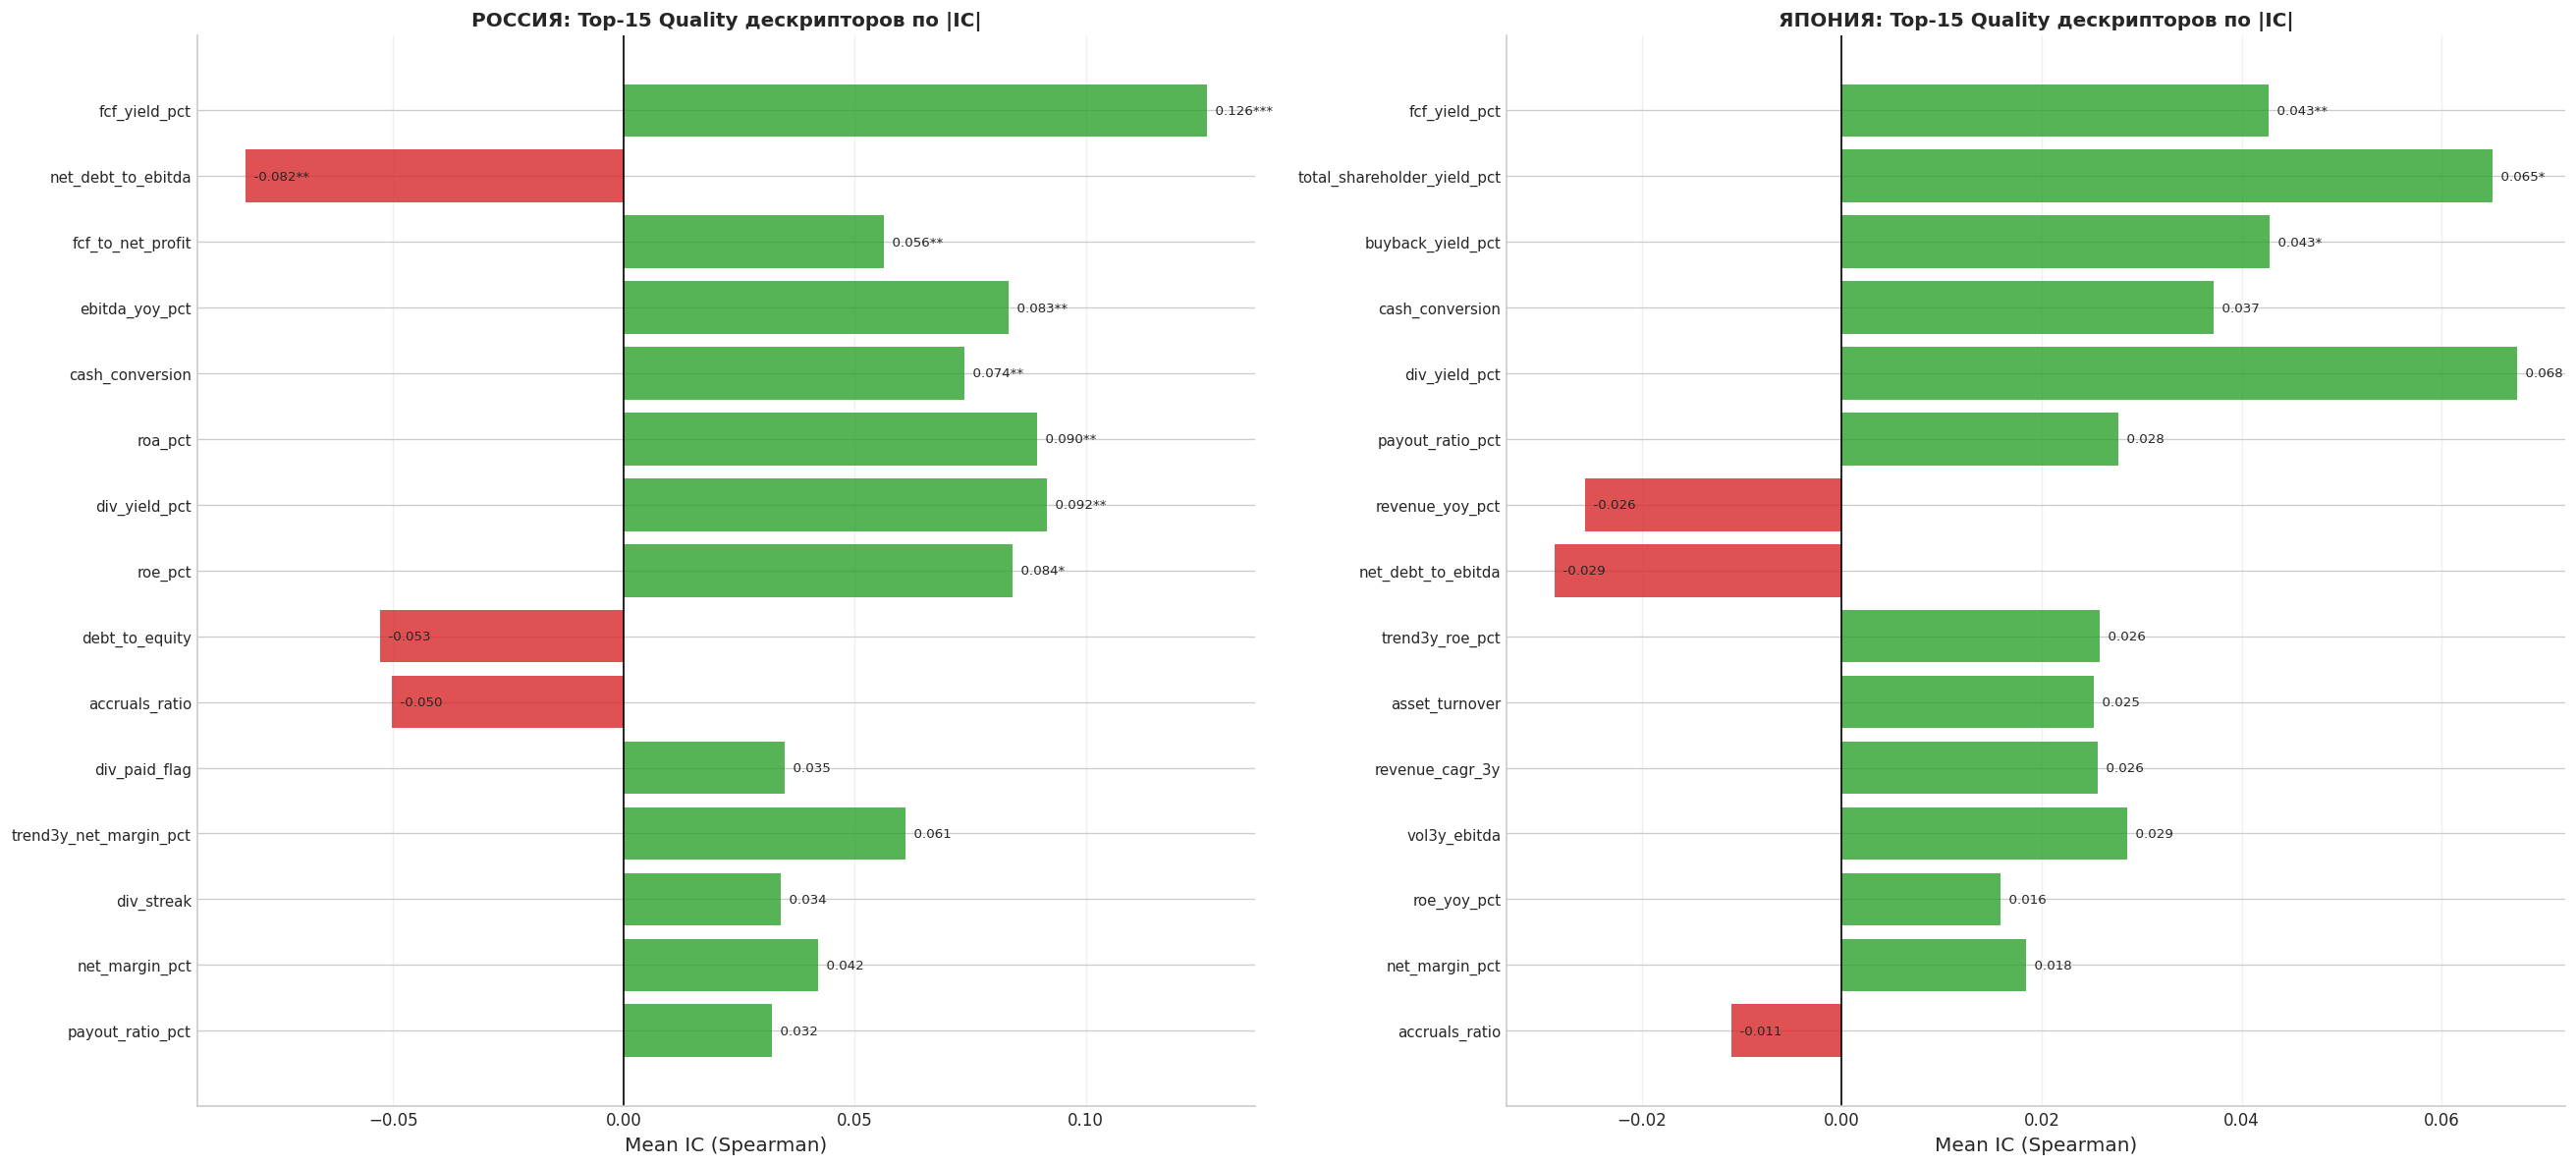

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/descriptor_IC_comparison.png


In [508]:
# ═══════════════════════════════════════════════════════════════════
# 11. DESCRIPTOR-LEVEL IC ANALYSIS
# ═══════════════════════════════════════════════════════════════════

def descriptor_ic_analysis(panel, prices, cfg, descriptors):
    """
    Для каждого дескриптора и каждого года:
    IC = Spearman(descriptor_value, forward_12m_return)
    """
    tc = cfg.ticker_col
    results = []

    for year in range(cfg.start_year, cfg.max_year + 1):
        mask = panel['trading_year'] == year
        uni = panel[mask].copy()
        if len(uni) < 20: continue

        # Calculate forward 12-month return for each ticker
        start = pd.Timestamp(year, cfg.rebalance_month, 1)
        end = start + pd.DateOffset(months=12)
        pm = (prices.index >= start) & (prices.index < end)
        pr = prices[pm].copy()
        if len(pr) == 0: continue

        fwd_ret = pr.groupby('ticker')['ret'].apply(
            lambda x: (1 + x.dropna()).prod() - 1 if len(x.dropna()) > 0 else np.nan
        ).dropna()

        # Merge
        uni_tks = uni.set_index(tc)
        common = set(uni_tks.index) & set(fwd_ret.index)
        if len(common) < 15: continue

        for desc in descriptors:
            if desc not in uni.columns: continue
            vals = uni_tks.loc[list(common), desc].astype(float)
            rets = fwd_ret.loc[list(common)]
            both_ok = vals.notna() & rets.notna()
            if both_ok.sum() < 10: continue

            ic, p_ic = stats.spearmanr(vals[both_ok], rets[both_ok])
            results.append({
                'descriptor': desc, 'year': year,
                'IC': ic, 'p_IC': p_ic, 'N': both_ok.sum()
            })

    if not results:
        return pd.DataFrame()

    df = pd.DataFrame(results)

    # Summary per descriptor
    summary = []
    for desc, grp in df.groupby('descriptor'):
        ic_mean = grp['IC'].mean()
        ic_std = grp['IC'].std()
        ic_t = ic_mean / (ic_std / np.sqrt(len(grp))) if ic_std > 0 else 0
        ic_ir = ic_mean / ic_std if ic_std > 0 else 0
        p_val = 2 * (1 - stats.t.cdf(abs(ic_t), len(grp) - 1)) if len(grp) > 1 else 1
        summary.append({
            'descriptor': desc,
            'mean_IC': ic_mean,
            'std_IC': ic_std,
            't_IC': ic_t,
            'p_IC': p_val,
            'sig': sig_stars(p_val),
            'IC_IR': ic_ir,
            'N_years': len(grp),
            'hit_rate': (grp['IC'] > 0).mean(),
        })

    return pd.DataFrame(summary).sort_values('t_IC', ascending=False, key=abs)

# Quality-relevant descriptors for each market
RF_QUALITY_DESCRIPTORS = [
    'roe_pct', 'roa_pct', 'net_margin_pct', 'ebitda_margin_pct',
    'equity_to_assets_pct', 'net_debt_to_ebitda', 'debt_to_equity',
    'accruals_ratio', 'cash_conversion',
    'fcf_yield_pct', 'fcf_to_net_profit', 'payout_ratio_pct',
    'div_yield_pct', 'div_streak', 'div_growth_streak', 'div_paid_flag',
    'revenue_yoy_pct', 'ebitda_yoy_pct', 'revenue_cagr3y_calc',
    'trend3y_roe_pct', 'trend3y_net_margin_pct',
    'vol3y_ebitda', 'vol3y_net_profit',
]

JP_QUALITY_DESCRIPTORS = [
    'roe_pct', 'roa_pct', 'net_margin_pct', 'ebitda_margin_pct',
    'gross_profit_margin_pct', 'asset_turnover',
    'equity_ratio', 'net_debt_to_ebitda', 'debt_to_equity',
    'interest_coverage', 'accruals_ratio', 'cash_conversion',
    'fcf_yield_pct', 'fcf_to_net_profit', 'payout_ratio_pct',
    'div_yield_pct', 'div_streak', 'div_growth_streak', 'div_paid_flag',
    'buyback_yield_pct', 'total_shareholder_yield_pct',
    'revenue_yoy_pct', 'ebitda_yoy_pct', 'revenue_cagr_3y',
    'roe_yoy_pct', 'net_income_yoy_pct',
    'trend3y_roe_pct', 'trend3y_net_margin_pct',
    'vol3y_ebitda', 'vol3y_net_profit',
]

print("\n" + "=" * 80)
print("  DESCRIPTOR-LEVEL IC ANALYSIS")
print("=" * 80)

ic_tables = {}
for label, descs in [('RF', RF_QUALITY_DESCRIPTORS), ('JP', JP_QUALITY_DESCRIPTORS)]:
    if label not in baseline_results: continue
    br = baseline_results[label]
    print(f"\n  {br['cfg'].flag} {label}:")
    ic_df = descriptor_ic_analysis(
        br['dm'].panel, br['dm'].prices, br['cfg'], descs)
    if len(ic_df) > 0:
        ic_tables[label] = ic_df
        print(ic_df.to_string(index=False))
    else:
        print("  No IC results")

# Visualize IC comparison
if len(ic_tables) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))
    for ax, (label, ic_df) in zip(axes, ic_tables.items()):
        top = ic_df.head(15)
        colors = ['#2ca02c' if v > 0 else '#d62728' for v in top['mean_IC']]
        bars = ax.barh(range(len(top)), top['mean_IC'], color=colors, alpha=0.8)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top['descriptor'], fontsize=9)
        ax.invert_yaxis()
        for i, (ic, sig) in enumerate(zip(top['mean_IC'], top['sig'])):
            ax.text(ic, i, f'  {ic:.3f}{sig}', va='center', fontsize=8)
        country = 'РОССИЯ' if label == 'RF' else 'ЯПОНИЯ'
        ax.set_title(f'{country}: Top-15 Quality дескрипторов по |IC|',
                     fontweight='bold', fontsize=12)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('Mean IC (Spearman)')
        ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    fn = os.path.join(OUT, 'descriptor_IC_comparison.png')
    plt.savefig(fn, bbox_inches='tight')
    plt.show()
    print(f"  → Saved: {fn}")

## 12. Fama–MacBeth Cross-Sectional Regressions

Метод Fama & MacBeth (1973):
1. Для каждого периода t: cross-sectional regression
   `r_{i,t+1} = γ₀_t + γ₁_t · desc₁_it + ... + γ_k_t · desc_k_it + ε_it`
2. Серия коэффициентов {γ_k_t} по времени
3. t-статистика на среднее γ_k (с поправкой Newey-West)

Это позволяет оценить **partial contribution** каждого дескриптора Quality
к будущей доходности, контролируя за другие компоненты.

**Важно**: набор дескрипторов отобран с учётом мультиколлинеарности.
`accruals_ratio` исключён (коллинеарен с `fcf_yield_pct` и `net_margin_pct`,
что приводило к инверсии знака γ — suppressor effect).
`div_streak` (РФ) исключён (коллинеарен с `payout_ratio_pct`).
В IC-анализе (univariate) знаки обоих корректны: accruals IC ≈ −0.05,
div_streak IC ≈ +0.03 — согласуется с Sloan (1996).


  FAMA-MACBETH CROSS-SECTIONAL REGRESSIONS
  r_{i,t+1} = γ₀ + Σ γ_k · z(desc_k) + ε
  HAC Newey-West (2 lags) on time-series of γ

  🇷🇺 RF RF:
        descriptor  mean_gamma  se_gamma   t_gamma  p_gamma sig  N_periods
        _intercept    0.169687  0.040165  4.224766 0.000993 ***         14
   revenue_yoy_pct   -0.016003  0.014591 -1.096753 0.294271             13
net_debt_to_ebitda   -0.032653  0.030672 -1.064602 0.306431             14
     fcf_yield_pct    0.038484  0.040091  0.959915 0.354612             14
   cash_conversion   -0.033954  0.037342 -0.909276 0.382695             12
 fcf_to_net_profit    0.031962  0.041479  0.770543 0.454754             14
    net_margin_pct   -0.017585  0.039404 -0.446280 0.662738             14
           roe_pct    0.013908  0.052907  0.262883 0.796761             14
           roa_pct   -0.005893  0.046757 -0.126029 0.901637             14
     div_yield_pct   -0.002435  0.033410 -0.072869 0.943219             12
  payout_ratio_pct    0.001194 

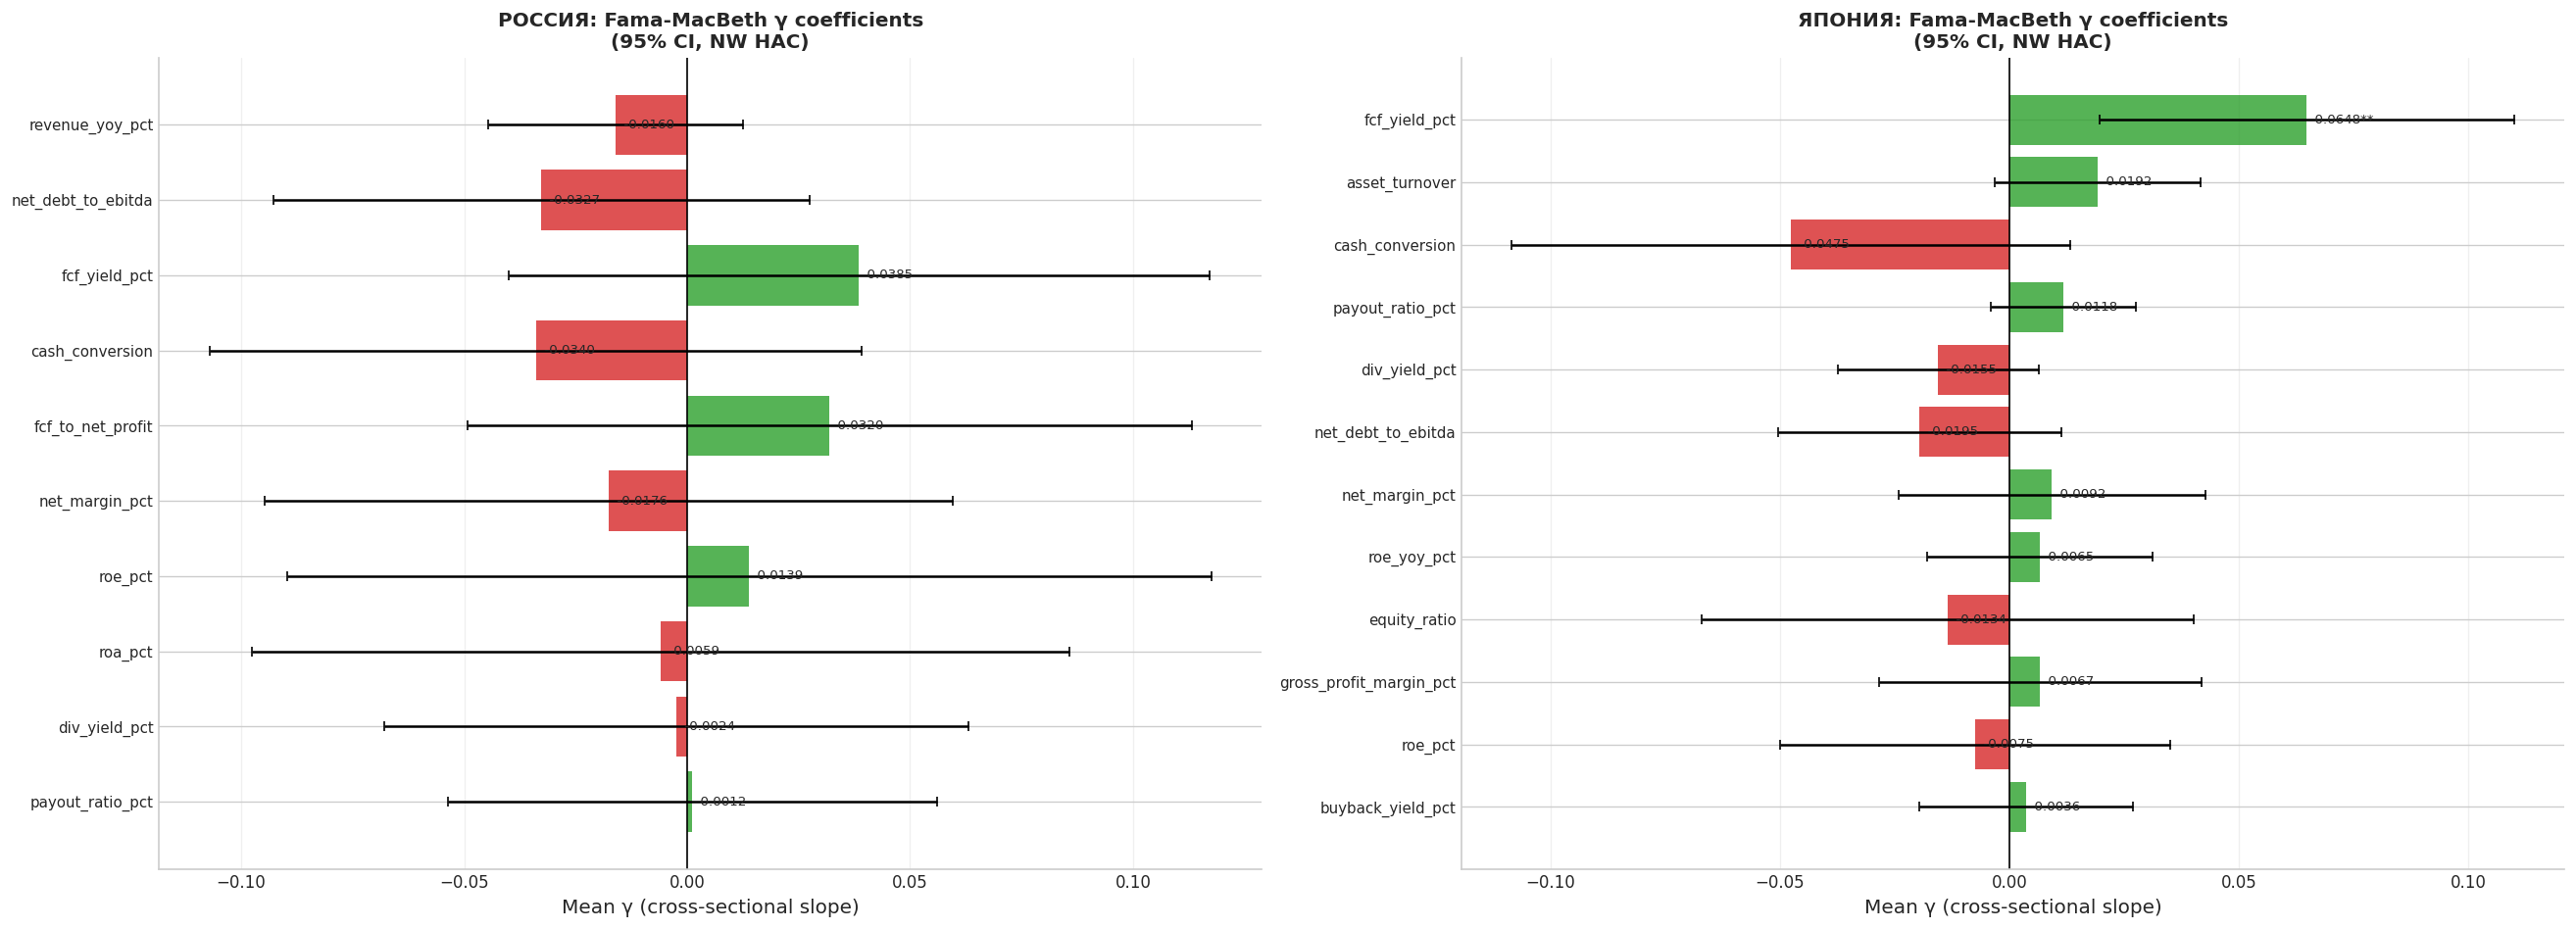

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/fama_macbeth_comparison.png


In [510]:
# ═══════════════════════════════════════════════════════════════════
# 12. FAMA-MACBETH REGRESSIONS
# ═══════════════════════════════════════════════════════════════════

def fama_macbeth(panel, prices, cfg, descriptors, hac_lags=2):
    """
    Fama-MacBeth cross-sectional regressions.
    For each year: regress forward 12m returns on descriptor z-scores.
    """
    tc = cfg.ticker_col
    gammas = {d: [] for d in descriptors}
    gammas['_intercept'] = []
    years_used = []

    for year in range(cfg.start_year, cfg.max_year + 1):
        mask = panel['trading_year'] == year
        uni = panel[mask].copy()
        if len(uni) < 30: continue

        # Forward return
        start = pd.Timestamp(year, cfg.rebalance_month, 1)
        end = start + pd.DateOffset(months=12)
        pm = (prices.index >= start) & (prices.index < end)
        pr = prices[pm].copy()
        if len(pr) == 0: continue

        fwd_ret = pr.groupby('ticker')['ret'].apply(
            lambda x: (1 + x.dropna()).prod() - 1 if len(x.dropna()) > 0 else np.nan
        ).dropna()

        uni_idx = uni.set_index(tc)
        common = sorted(set(uni_idx.index) & set(fwd_ret.index))
        if len(common) < 20: continue

        # Build X matrix (z-scored descriptors)
        X_cols = []
        active_descs = []
        for d in descriptors:
            if d not in uni_idx.columns: continue
            vals = uni_idx.loc[common, d].astype(float)
            if vals.notna().sum() < 10: continue
            z = zsc(winz(vals))
            X_cols.append(z.values)
            active_descs.append(d)

        if len(active_descs) < 2: continue

        y = fwd_ret.loc[common].values
        X = np.column_stack([np.ones(len(common))] + X_cols)

        # Drop rows with NaN
        ok = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
        if ok.sum() < 20: continue

        try:
            res = _ols(y[ok], X[ok])
            gammas['_intercept'].append(res['params'][0])
            for i, d in enumerate(active_descs):
                gammas[d].append(res['params'][i + 1])
            years_used.append(year)
        except:
            continue

    # Summarize
    rows = []
    for d in ['_intercept'] + descriptors:
        g = gammas.get(d, [])
        if len(g) < 3: continue
        g = np.array(g)
        mean_g = g.mean()
        se_g = g.std() / np.sqrt(len(g))
        # NW correction
        if hac_lags > 0 and len(g) > hac_lags + 1:
            v = g - mean_g
            nw_var = np.sum(v**2)
            for j in range(1, hac_lags + 1):
                w = 1 - j / (hac_lags + 1)
                nw_var += 2 * w * np.sum(v[j:] * v[:-j])
            nw_var /= len(g)**2
            se_g = np.sqrt(nw_var)
        t_g = mean_g / se_g if se_g > 0 else 0
        p_g = 2 * (1 - stats.t.cdf(abs(t_g), len(g) - 1)) if len(g) > 1 else 1
        rows.append({
            'descriptor': d,
            'mean_gamma': mean_g,
            'se_gamma': se_g,
            't_gamma': t_g,
            'p_gamma': p_g,
            'sig': sig_stars(p_g),
            'N_periods': len(g),
        })

    return pd.DataFrame(rows).sort_values('t_gamma', ascending=False, key=abs)

# Run Fama-MacBeth for both markets
print("\n" + "=" * 80)
print("  FAMA-MACBETH CROSS-SECTIONAL REGRESSIONS")
print("  r_{i,t+1} = γ₀ + Σ γ_k · z(desc_k) + ε")
print("  HAC Newey-West (2 lags) on time-series of γ")
print("=" * 80)

# Core Quality descriptors for FM regression
# NB: accruals_ratio убран — коллинеарен с fcf_yield_pct (r≈−0.28)
#     и net_margin_pct (r≈+0.44), что приводит к инверсии знака γ
#     в мультирегрессии (suppressor effect).
#     div_streak (RF) убран — коллинеарен с payout_ratio_pct (r≈+0.25),
#     частичный эффект отрицательный (value trap после контроля payout).
#     В IC-анализе (univariate) знаки обоих корректны:
#     accruals IC = −0.05, div_streak IC = +0.03.
RF_FM_DESCS = ['roe_pct', 'roa_pct', 'net_margin_pct',
               'net_debt_to_ebitda', 'fcf_yield_pct',
               'div_yield_pct', 'payout_ratio_pct', 'cash_conversion',
               'fcf_to_net_profit', 'revenue_yoy_pct']

JP_FM_DESCS = ['roe_pct', 'net_margin_pct', 'equity_ratio',
               'net_debt_to_ebitda', 'fcf_yield_pct',
               'payout_ratio_pct', 'buyback_yield_pct', 'asset_turnover',
               'cash_conversion', 'gross_profit_margin_pct', 'roe_yoy_pct',
               'div_yield_pct']

fm_tables = {}
for label, descs in [('RF', RF_FM_DESCS), ('JP', JP_FM_DESCS)]:
    if label not in baseline_results: continue
    br = baseline_results[label]
    print(f"\n  {br['cfg'].flag} {label}:")
    fm_df = fama_macbeth(br['dm'].panel, br['dm'].prices, br['cfg'], descs)
    if len(fm_df) > 0:
        fm_tables[label] = fm_df
        print(fm_df.to_string(index=False))
    else:
        print("  No FM results")

# Visualize FM coefficients
if len(fm_tables) > 0:
    fig, axes = plt.subplots(1, len(fm_tables), figsize=(11 * len(fm_tables), 8))
    if len(fm_tables) == 1: axes = [axes]
    for ax, (label, fm_df) in zip(axes, fm_tables.items()):
        fm_show = fm_df[fm_df['descriptor'] != '_intercept'].head(12)
        colors = ['#2ca02c' if v > 0 else '#d62728' for v in fm_show['mean_gamma']]
        ax.barh(range(len(fm_show)), fm_show['mean_gamma'], xerr=fm_show['se_gamma'] * 1.96,
                color=colors, alpha=0.8, capsize=3)
        ax.set_yticks(range(len(fm_show)))
        ax.set_yticklabels(fm_show['descriptor'], fontsize=9)
        ax.invert_yaxis()
        for i, (g, sig) in enumerate(zip(fm_show['mean_gamma'], fm_show['sig'])):
            ax.text(g, i, f'  {g:.4f}{sig}', va='center', fontsize=8)
        country = 'РОССИЯ' if label == 'RF' else 'ЯПОНИЯ'
        ax.set_title(f'{country}: Fama-MacBeth γ coefficients\n(95% CI, NW HAC)',
                     fontweight='bold', fontsize=12)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('Mean γ (cross-sectional slope)')
        ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    fn = os.path.join(OUT, 'fama_macbeth_comparison.png')
    plt.savefig(fn, bbox_inches='tight')
    plt.show()
    print(f"  → Saved: {fn}")

## 13. Сводный отчёт и экспорт

### Итоговые таблицы:
1. **Baseline Metrics** (Part I) — 7 факторов × 2 рынка, sorted by Sharpe
2. **Baseline Regressions** (Part I) — sorted by p-value alpha
3. **Quality Q0-Q3 Metrics** (Part II) — sorted by Sharpe
4. **Quality Q0-Q3 Regressions** (Part II) — sorted by p-value alpha
5. **Descriptor IC** — per market, sorted by |t_IC|
6. **Fama-MacBeth** — per market, sorted by |t_gamma|

In [512]:
# ═══════════════════════════════════════════════════════════════════
# 13. FINAL EXPORT
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("  ЭКСПОРТ ВСЕХ ТАБЛИЦ")
print("=" * 80)

try:
    with pd.ExcelWriter(os.path.join(OUT, 'FULL_RESEARCH_TABLES.xlsx')) as w:
        # Part I
        if 'comparison' in baseline_results:
            baseline_results['comparison']['metrics'].to_excel(w, 'I_Metrics_by_Sharpe', index=False)
            baseline_results['comparison']['regressions'].to_excel(w, 'I_Regressions_by_pvalue', index=False)

        # Part II - Quality
        if isinstance(mt_q, pd.DataFrame):
            mt_q.to_excel(w, 'II_Quality_Metrics', index=False)
        if isinstance(rt_q, pd.DataFrame):
            rt_q.to_excel(w, 'II_Quality_Regressions', index=False)

        # Descriptor IC
        for label, ic_df in ic_tables.items():
            ic_df.to_excel(w, f'IC_{label}', index=False)

        # Fama-MacBeth
        for label, fm_df in fm_tables.items():
            fm_df.to_excel(w, f'FM_{label}', index=False)

    print(f"  → Saved: {os.path.join(OUT, 'FULL_RESEARCH_TABLES.xlsx')}")
except Exception as e:
    print(f"  Export error: {e}")


  ЭКСПОРТ ВСЕХ ТАБЛИЦ
  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/FULL_RESEARCH_TABLES.xlsx


---
# ═══════════════════════════════════════════════════════════
# ЧАСТЬ III: ROBUSTNESS & DIAGNOSTIC TESTS
# ═══════════════════════════════════════════════════════════

Дополнительные проверки академической валидности:
1. **Quintile Sorts** — монотонность факторных премий (Q1→Q5)
2. **Long-Short Portfolios** — zero-cost factor portfolios (Q1−Q5)
3. **Turnover Analysis** — оборачиваемость портфелей + realistic TC
4. **Subperiod Robustness** — устойчивость (2012–2018 vs 2019–2026)
5. **Survivorship Bias & Limitations** — оговорки и дисклеймеры


  ЧАСТЬ III: ROBUSTNESS & DIAGNOSTIC TESTS

  14. QUINTILE SORTS & MONOTONICITY TEST
  ------------------------------------------------------------

  🇷🇺 RF RF: Quintile backtest (5 квинтилей × 7 факторов)...


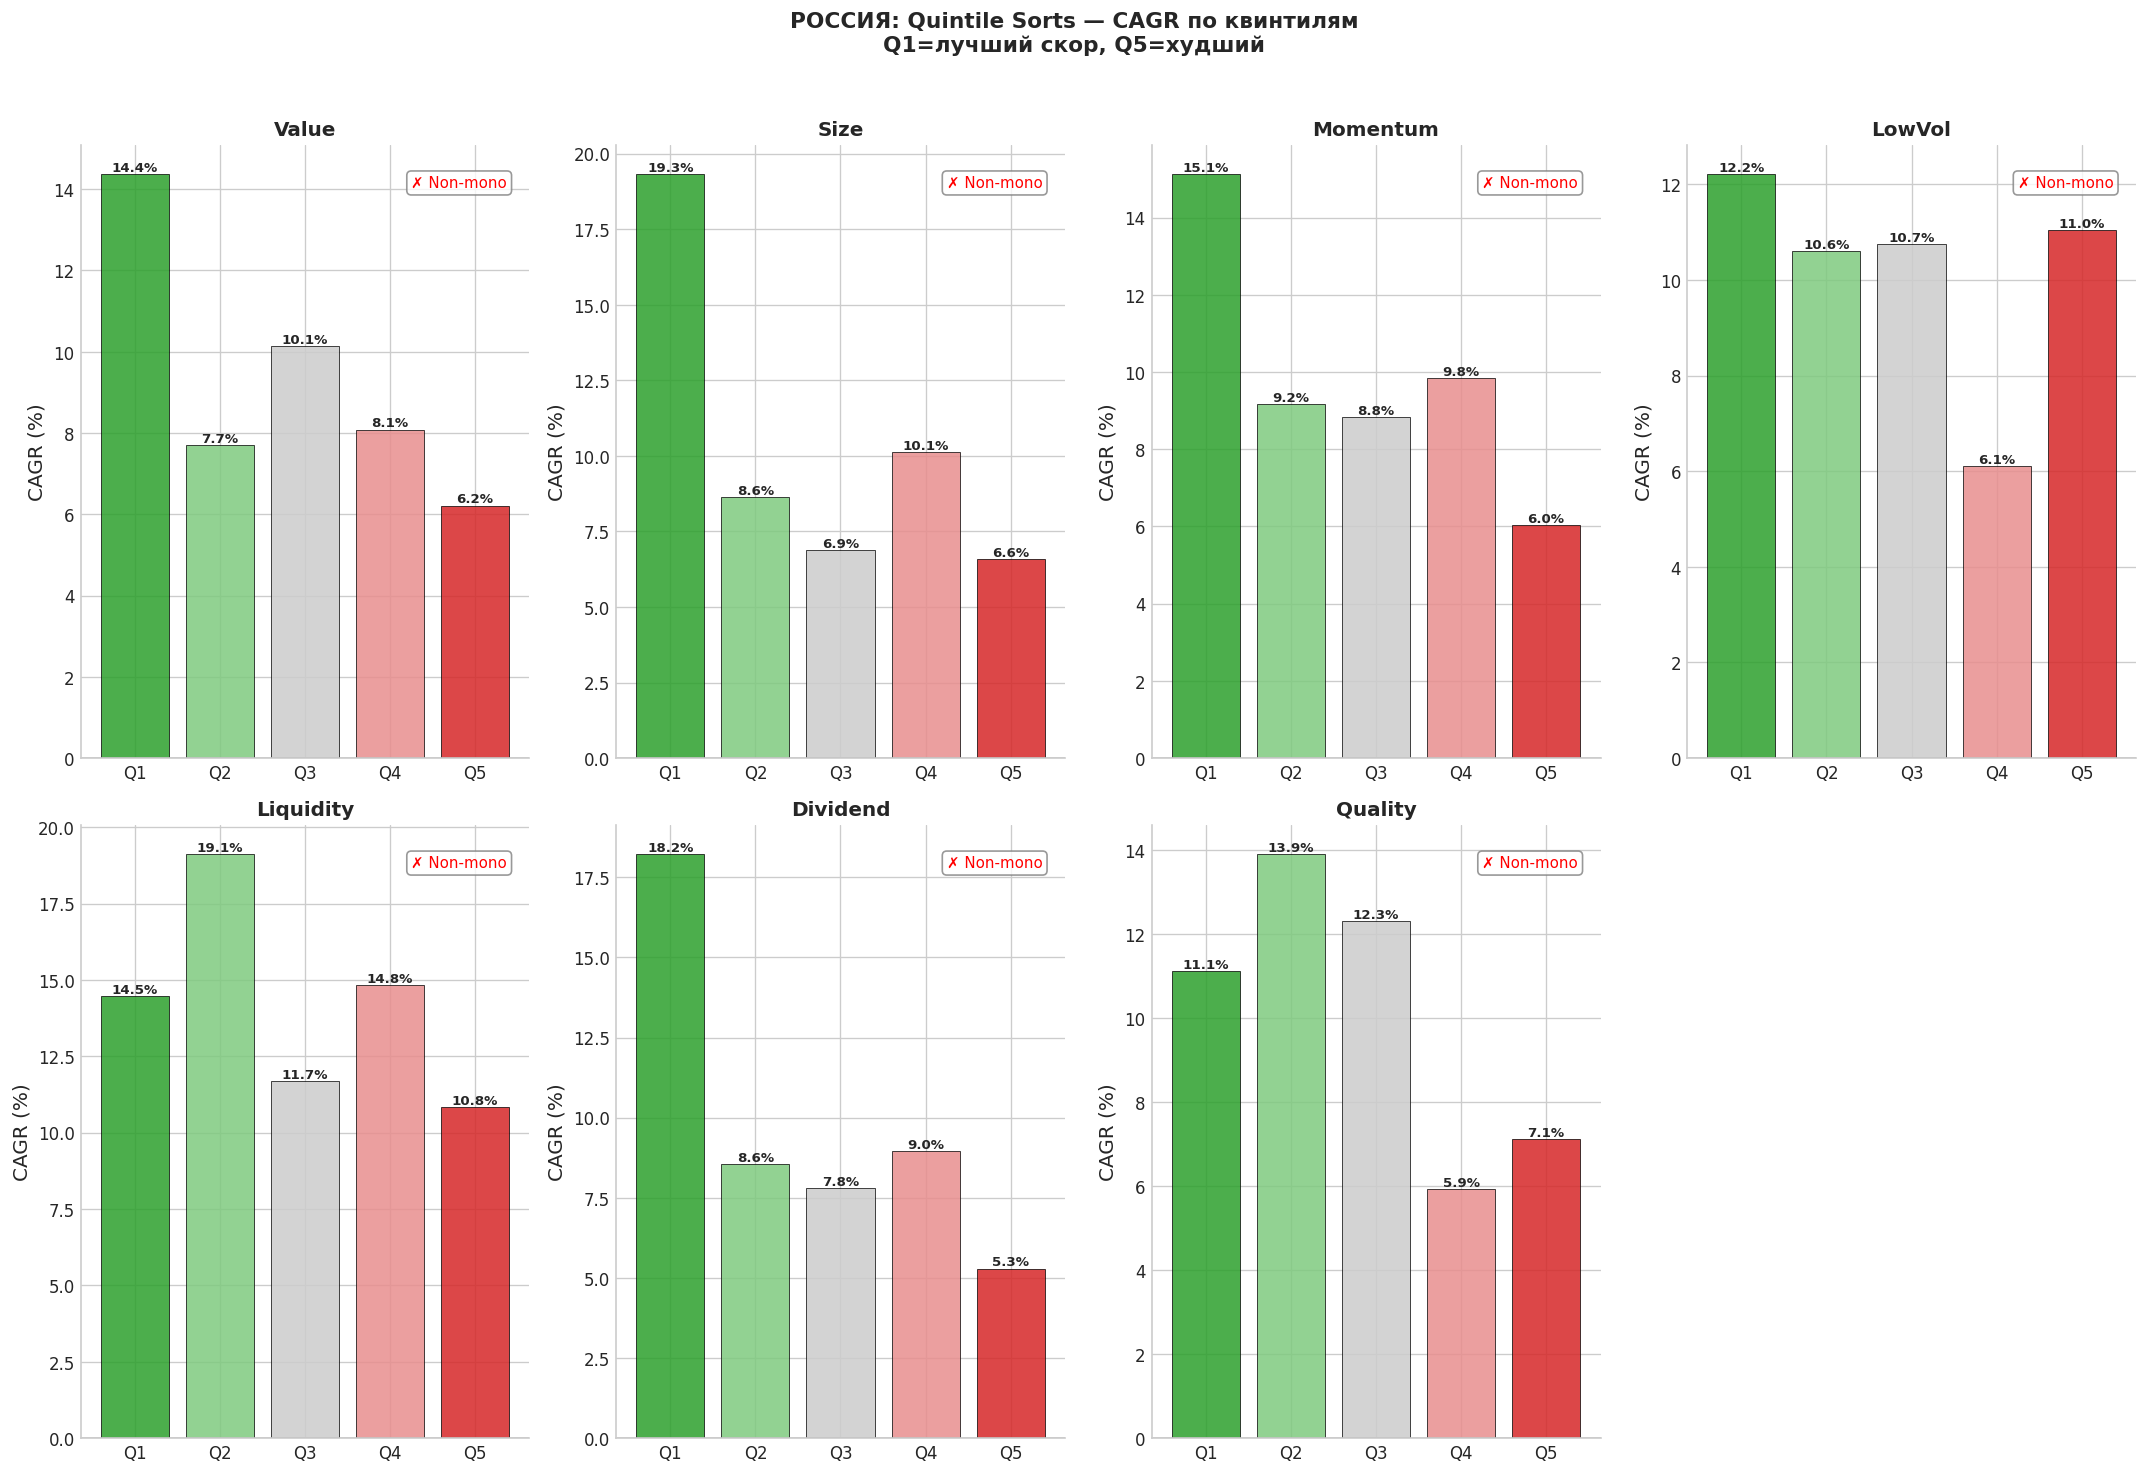

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/RF_quintile_sorts.png
    Value           | Q1=+14.4% → Q5=+6.2% | Spread=+8.2% | ✗ Non-monotonic
    Size            | Q1=+19.3% → Q5=+6.6% | Spread=+12.7% | ✗ Non-monotonic
    Momentum        | Q1=+15.1% → Q5=+6.0% | Spread=+9.1% | ✗ Non-monotonic
    LowVol          | Q1=+12.2% → Q5=+11.0% | Spread=+1.2% | ✗ Non-monotonic
    Liquidity       | Q1=+14.5% → Q5=+10.8% | Spread=+3.6% | ✗ Non-monotonic
    Dividend        | Q1=+18.2% → Q5=+5.3% | Spread=+12.9% | ✗ Non-monotonic
    Quality         | Q1=+11.1% → Q5=+7.1% | Spread=+4.0% | ✗ Non-monotonic

  🇯🇵 JP JP: Quintile backtest (5 квинтилей × 7 факторов)...


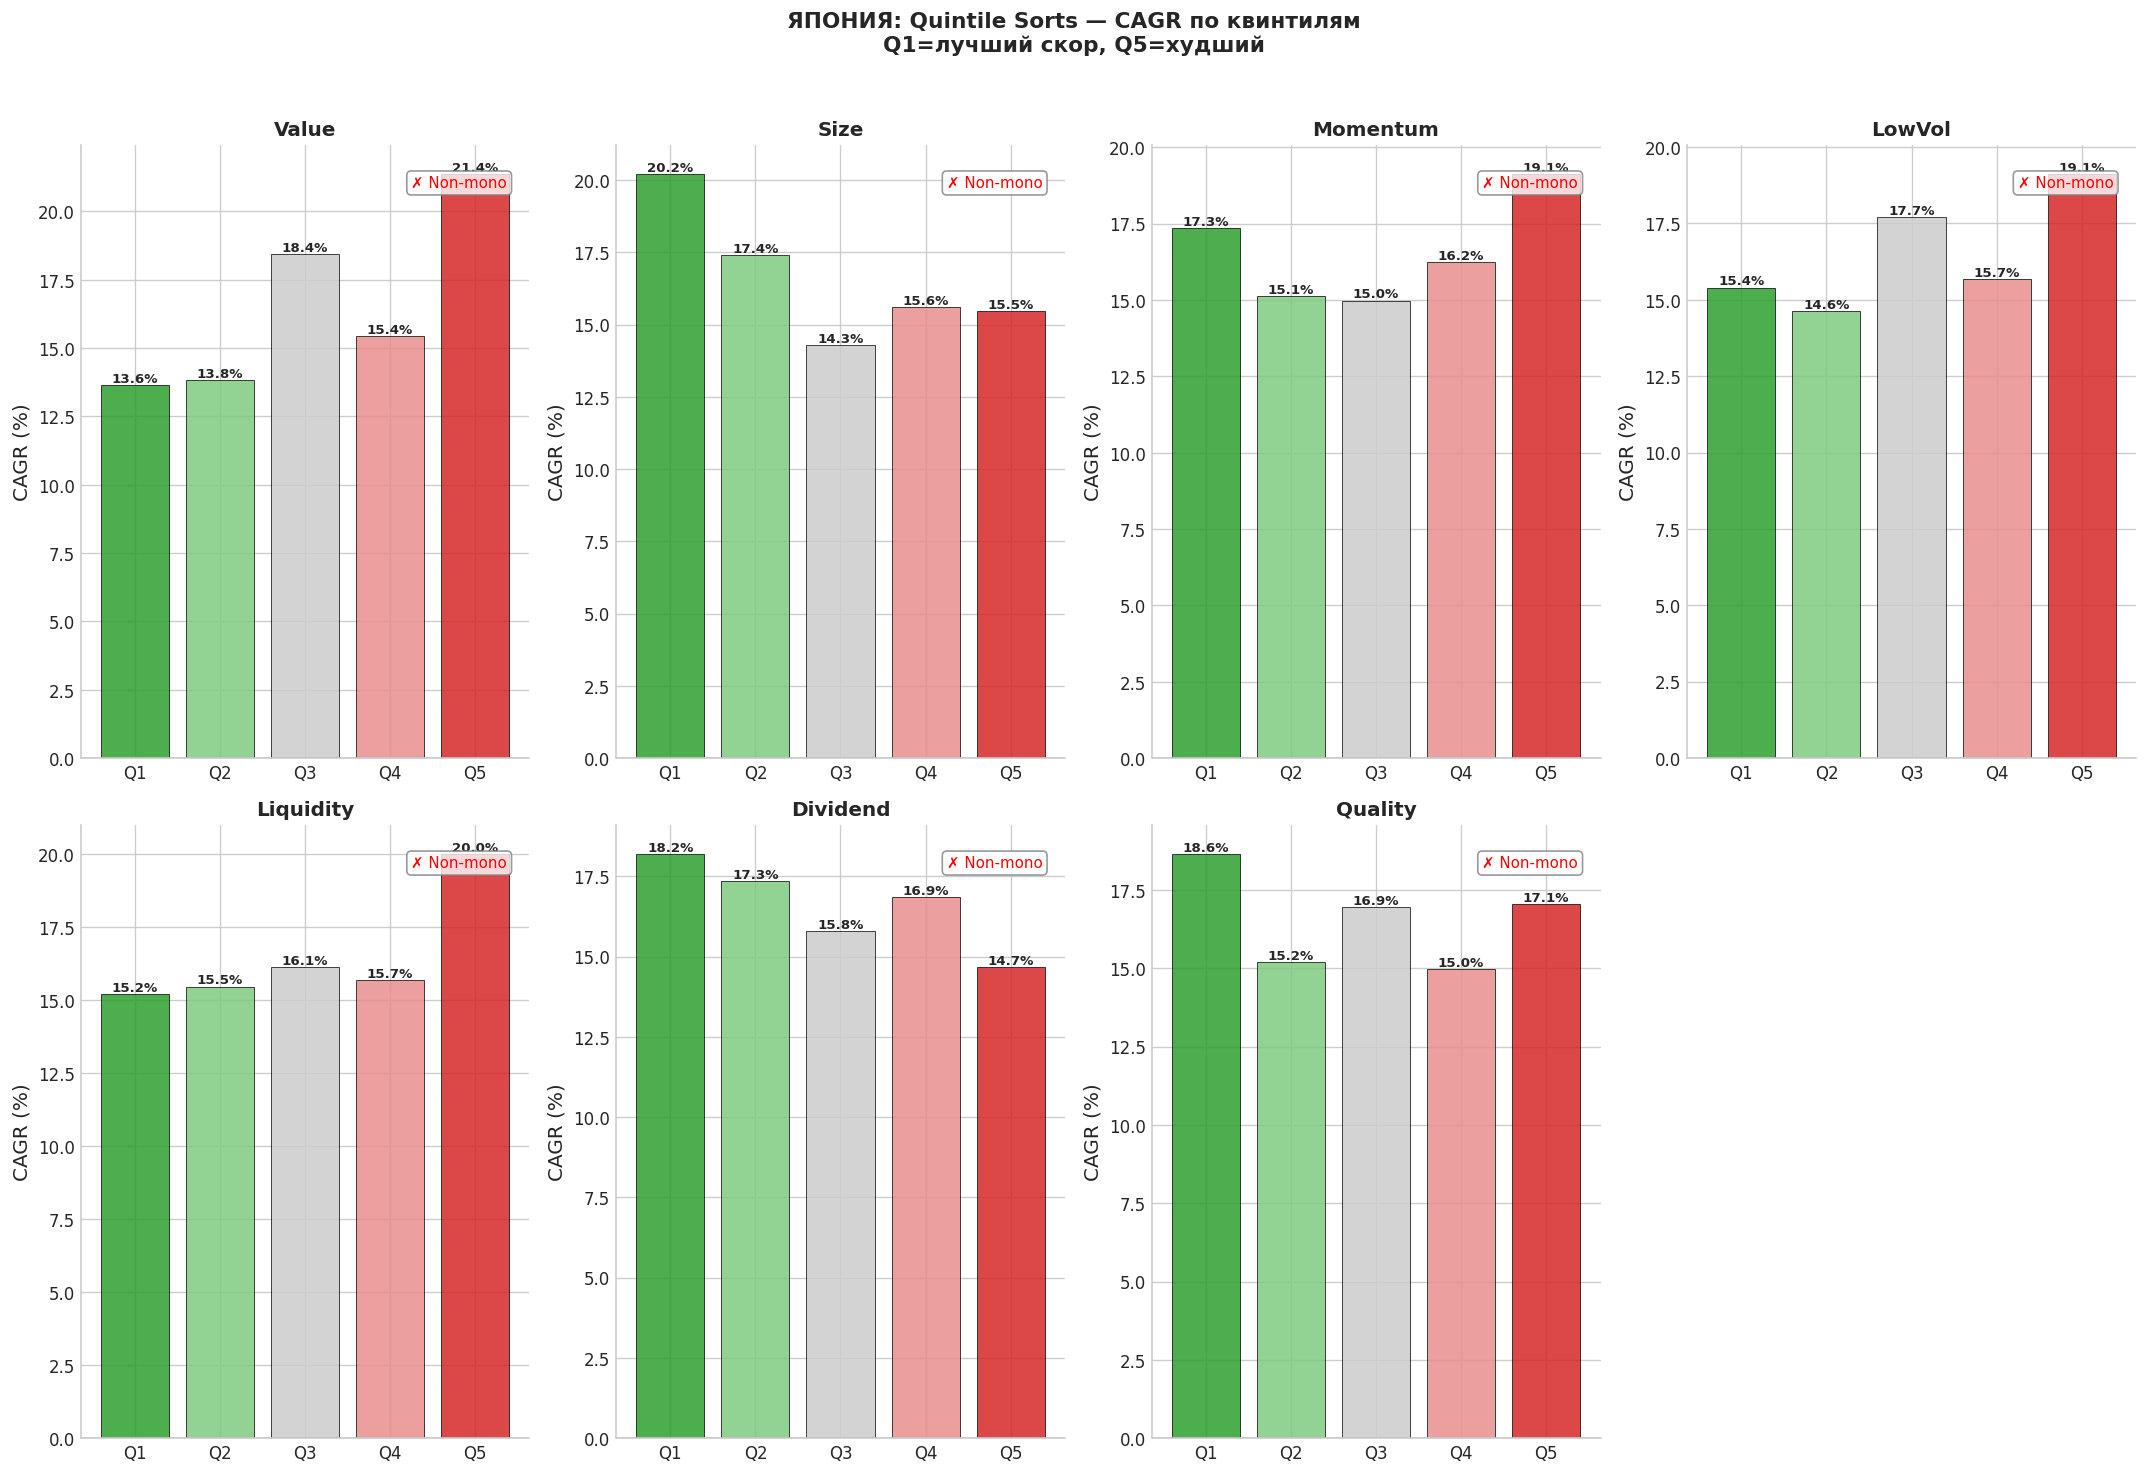

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/JP_quintile_sorts.png
    Value           | Q1=+13.6% → Q5=+21.4% | Spread=-7.7% | ✗ Non-monotonic
    Size            | Q1=+20.2% → Q5=+15.5% | Spread=+4.7% | ✗ Non-monotonic
    Momentum        | Q1=+17.3% → Q5=+19.1% | Spread=-1.8% | ✗ Non-monotonic
    LowVol          | Q1=+15.4% → Q5=+19.1% | Spread=-3.7% | ✗ Non-monotonic
    Liquidity       | Q1=+15.2% → Q5=+20.0% | Spread=-4.8% | ✗ Non-monotonic
    Dividend        | Q1=+18.2% → Q5=+14.7% | Spread=+3.5% | ✗ Non-monotonic
    Quality         | Q1=+18.6% → Q5=+17.1% | Spread=+1.6% | ✗ Non-monotonic


In [514]:
# ═══════════════════════════════════════════════════════════════════
# 14. QUINTILE SORTS + MONOTONICITY + LONG-SHORT
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("  ЧАСТЬ III: ROBUSTNESS & DIAGNOSTIC TESTS")
print("=" * 80)

def _score_standalone(df, specs):
    """Standalone scoring (same logic as FactorEngine._score)."""
    sc = pd.Series(0.0, index=df.index)
    cnt = pd.Series(0, index=df.index)
    for col, (d, w) in specs.items():
        if col not in df.columns: continue
        v = df[col].copy()
        if v.notna().sum() < 5: continue
        z = zsc(winz(v))
        if z.std() < 1e-10: continue
        ok = z.notna()
        sc.loc[ok] += z.loc[ok] * d * w
        cnt.loc[ok] += 1
    result = sc / cnt.replace(0, np.nan)
    if result.notna().sum() > 2 and result.std() > 1e-10:
        result = (result - result.mean()) / result.std()
    return result

def quintile_backtest(cfg, panel, prices, strategies, n_q=5):
    """
    Quintile portfolio sorts.
    Q1 = best (highest factor score), Q5 = worst.
    """
    all_results = {}
    mc = next((c for c in ['market_cap_mln', 'log_market_cap']
               if c in panel.columns), None)

    for name, specs in strategies.items():
        nb_sp = specs.get('nonbank', {})
        bk_sp = specs.get('bank', nb_sp)
        q_rets = {q: [] for q in range(1, n_q + 1)}

        for year in range(cfg.start_year, cfg.max_year + 1):
            mask = panel['trading_year'] == year
            if mc and cfg.min_market_cap > 0:
                if 'log' in str(mc):
                    mask &= panel[mc] > np.log(cfg.min_market_cap)
                else:
                    mask &= panel[mc] > cfg.min_market_cap
            uni = panel[mask].copy()
            if len(uni) < n_q * 4: continue

            banks = uni[uni['is_bank']].copy()
            nonb  = uni[~uni['is_bank']].copy()
            scores = pd.Series(np.nan, index=uni.index)
            if len(nonb) >= 3:
                scores.loc[nonb.index] = _score_standalone(nonb, nb_sp)
            if len(banks) >= 2:
                bs = _score_standalone(banks, bk_sp)
                nb_ok = scores.loc[nonb.index]
                if nb_ok.notna().sum() > 0:
                    nm, ns = nb_ok.mean(), nb_ok.std()
                    if ns > 0 and bs.std() > 0:
                        bs = (bs - bs.mean()) / bs.std() * ns + nm
                scores.loc[banks.index] = bs

            uni['fs'] = scores
            uni = uni.dropna(subset=['fs'])
            if len(uni) < n_q * 3: continue

            try:
                uni['quintile'] = pd.qcut(
                    uni['fs'].rank(method='first'), n_q, labels=False)
                uni['quintile'] = n_q - uni['quintile']  # Q1=best
            except ValueError:
                continue

            start = pd.Timestamp(year, cfg.rebalance_month, 1)
            for q in range(1, n_q + 1):
                tickers = uni[uni['quintile'] == q][cfg.ticker_col].tolist()
                if not tickers: continue
                for mo in range(12):
                    dt = start + pd.DateOffset(months=mo)
                    pm = ((prices.index.year == dt.year) &
                          (prices.index.month == dt.month))
                    md = prices[pm & prices['ticker'].isin(tickers)]
                    if len(md) > 0:
                        mr = md.groupby('ticker')['ret'].apply(
                            lambda x: (1+x.dropna()).prod()-1
                            if len(x.dropna()) > 0 else np.nan
                        ).dropna().mean()
                        if pd.notna(mr):
                            tc = cfg.tc_bps / 10000 if mo == 0 else 0
                            q_rets[q].append({
                                'date': dt + pd.offsets.MonthEnd(0),
                                'ret': mr - tc})

        q_results = {}
        for q in range(1, n_q + 1):
            if len(q_rets[q]) >= 12:
                r = pd.DataFrame(q_rets[q]).set_index('date').sort_index()
                r = r.groupby(r.index).mean()
                q_results[q] = r
        if len(q_results) >= 3:
            all_results[name] = q_results
    return all_results

def plot_quintile_bars(quint_results, rf_series, cfg):
    """Bar chart: CAGR per quintile + monotonicity tag."""
    factors = list(quint_results.keys())
    if not factors: return pd.DataFrame()
    n = len(factors)
    ncols = min(n, 4)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 6*nrows), squeeze=False)
    axes_flat = axes.flatten()
    rows = []

    for idx, fname in enumerate(factors):
        if idx >= len(axes_flat): break
        ax = axes_flat[idx]
        qr = quint_results[fname]
        cagrs = []
        quintiles = sorted(qr.keys())
        for q in quintiles:
            m = metrics(qr[q]['ret'], rf_series)
            cagrs.append(m['CAGR'])
            rows.append({'Factor': fname, 'Quintile': f'Q{q}',
                         'CAGR': m['CAGR'], 'Sharpe': m['Sharpe'],
                         'Vol': m['Vol'], 'MaxDD': m['MaxDD']})
        colors = ['#2ca02c','#7fca7f','#cccccc','#e88e8e','#d62728'][:len(quintiles)]
        ax.bar(range(len(quintiles)), [c*100 for c in cagrs],
               color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax.set_xticks(range(len(quintiles)))
        ax.set_xticklabels([f'Q{q}' for q in quintiles])
        ax.set_title(fname, fontweight='bold', fontsize=12)
        ax.set_ylabel('CAGR (%)')
        ax.axhline(0, color='black', lw=0.8)
        for i, c in enumerate(cagrs):
            ax.text(i, c*100, f'{c:.1%}', ha='center',
                    va='bottom' if c >= 0 else 'top', fontsize=8, fontweight='bold')
        mono = all(cagrs[i] >= cagrs[i+1] for i in range(len(cagrs)-1))
        ax.text(0.95, 0.95, '✓ Mono' if mono else '✗ Non-mono',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                color='green' if mono else 'red',
                bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

    # Hide unused axes
    for idx in range(n, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    country = 'РОССИЯ' if cfg.country == 'RF' else 'ЯПОНИЯ'
    fig.suptitle(f'{country}: Quintile Sorts — CAGR по квинтилям\n'
                 f'Q1=лучший скор, Q5=худший', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fn = os.path.join(OUT, f'{cfg.country}_quintile_sorts.png')
    plt.savefig(fn, bbox_inches='tight')
    plt.show()
    print(f"  → Saved: {fn}")
    return pd.DataFrame(rows)

# ── Run quintile sorts ──
print("\n  14. QUINTILE SORTS & MONOTONICITY TEST")
print("  " + "-" * 60)

quintile_raw = {}
quintile_tables = {}

for label in ['RF', 'JP']:
    if label not in baseline_results: continue
    br = baseline_results[label]
    cfg = br['cfg']; dm = br['dm']
    print(f"\n  {cfg.flag} {label}: Quintile backtest (5 квинтилей × 7 факторов)...")
    qr = quintile_backtest(cfg, dm.panel, dm.prices, cfg.strategies)
    quintile_raw[label] = qr
    if qr:
        qt = plot_quintile_bars(qr, dm.rf, cfg)
        quintile_tables[label] = qt
        for fname in qr:
            q_cagrs = []
            for q in sorted(qr[fname].keys()):
                m = metrics(qr[fname][q]['ret'], dm.rf)
                q_cagrs.append(m['CAGR'])
            mono = all(q_cagrs[i] >= q_cagrs[i+1] for i in range(len(q_cagrs)-1))
            spread = q_cagrs[0] - q_cagrs[-1] if len(q_cagrs) >= 2 else 0
            print(f"    {fname:15s} | Q1={q_cagrs[0]:+.1%} → Q5={q_cagrs[-1]:+.1%} | "
                  f"Spread={spread:+.1%} | {'✓ Monotonic' if mono else '✗ Non-monotonic'}")

## 15. Long-Short Factor Portfolios

Zero-cost портфель: **Long Q1 − Short Q5**.
L/S изолирует чистую факторную премию, убирая рыночную бету.


  15. LONG-SHORT FACTOR PORTFOLIOS (Q1 − Q5)
  ------------------------------------------------------------
  🇷🇺 RF Dividend        L/S: CAGR=+9.7% | Sharpe=+0.66 | MaxDD=-40.8%
  🇷🇺 RF Size            L/S: CAGR=+9.5% | Sharpe=+0.61 | MaxDD=-25.2%
  🇷🇺 RF Value           L/S: CAGR=+6.7% | Sharpe=+0.49 | MaxDD=-36.5%
  🇷🇺 RF Momentum        L/S: CAGR=+6.3% | Sharpe=+0.44 | MaxDD=-35.3%
  🇷🇺 RF Liquidity       L/S: CAGR=+1.9% | Sharpe=+0.19 | MaxDD=-38.2%
  🇷🇺 RF Quality         L/S: CAGR=+0.8% | Sharpe=+0.13 | MaxDD=-56.7%
  🇷🇺 RF LowVol          L/S: CAGR=-1.3% | Sharpe=+0.00 | MaxDD=-52.6%


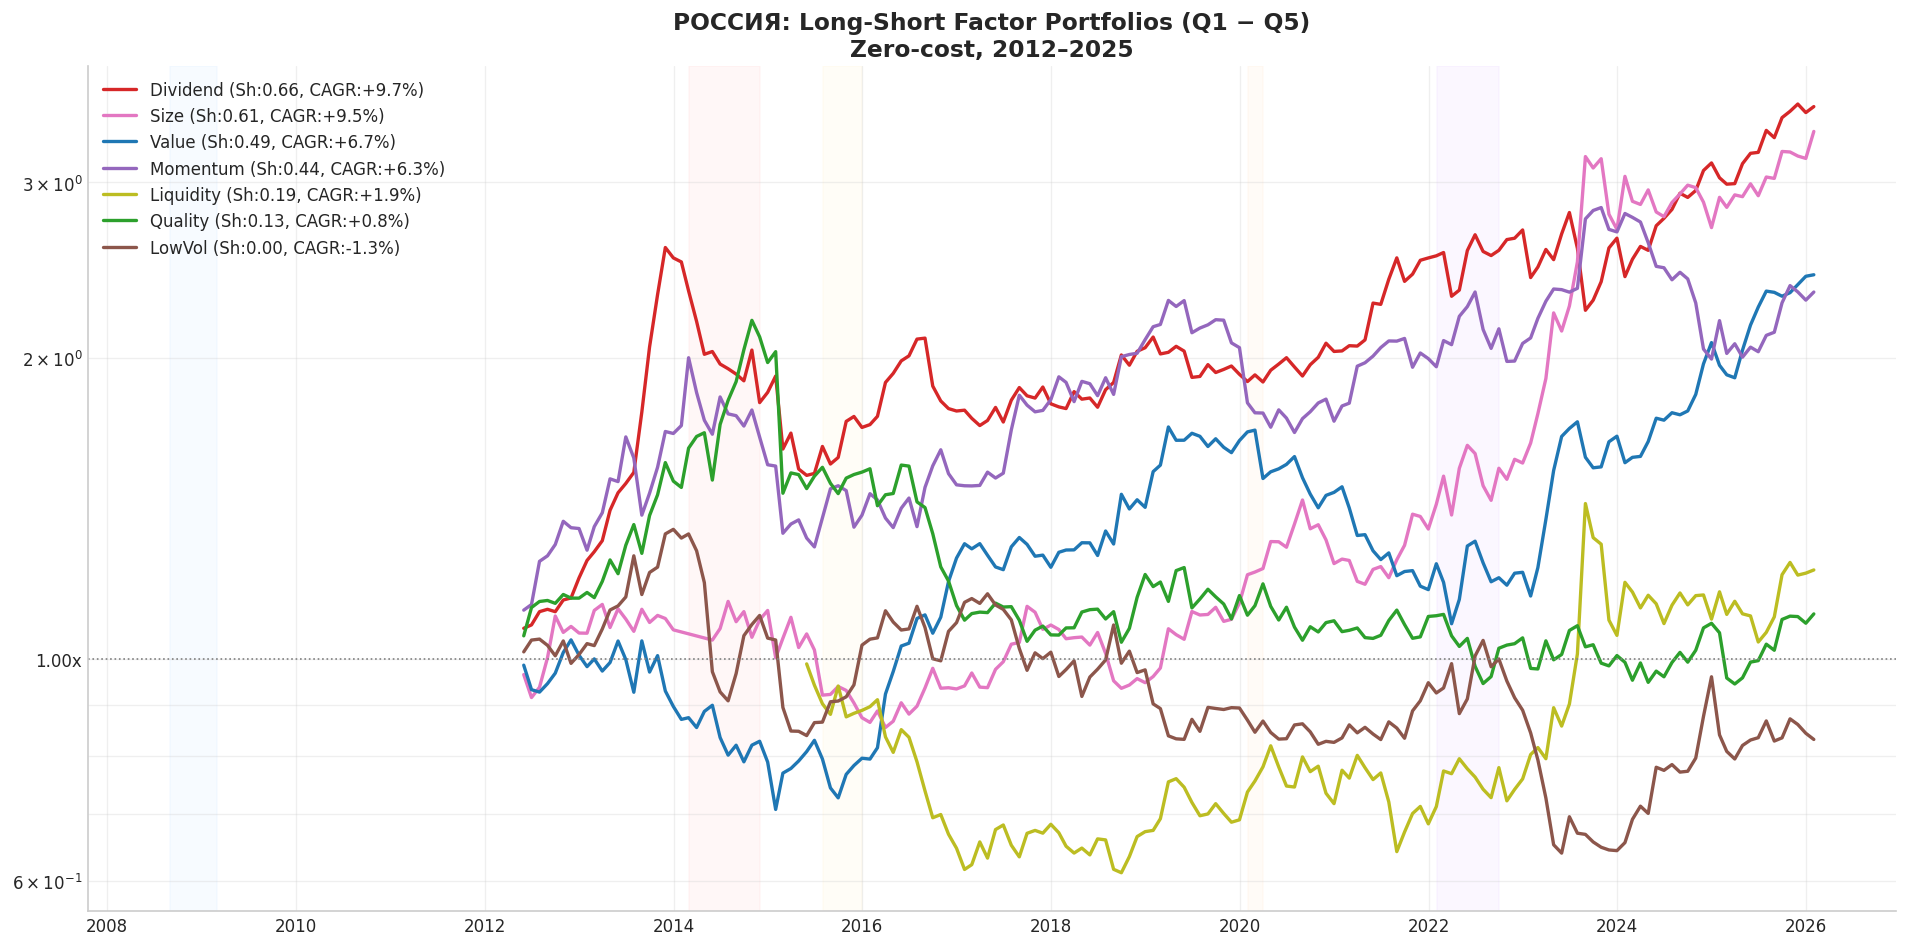

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/RF_long_short_cumulative.png
  🇯🇵 JP Size            L/S: CAGR=+4.2% | Sharpe=+0.48 | MaxDD=-27.6%
  🇯🇵 JP Dividend        L/S: CAGR=+2.5% | Sharpe=+0.32 | MaxDD=-24.2%
  🇯🇵 JP Quality         L/S: CAGR=+0.4% | Sharpe=+0.09 | MaxDD=-31.9%
  🇯🇵 JP Momentum        L/S: CAGR=-2.0% | Sharpe=-0.16 | MaxDD=-42.8%
  🇯🇵 JP LowVol          L/S: CAGR=-5.2% | Sharpe=-0.33 | MaxDD=-58.6%
  🇯🇵 JP Liquidity       L/S: CAGR=-5.9% | Sharpe=-0.43 | MaxDD=-62.1%
  🇯🇵 JP Value           L/S: CAGR=-6.7% | Sharpe=-0.45 | MaxDD=-67.5%


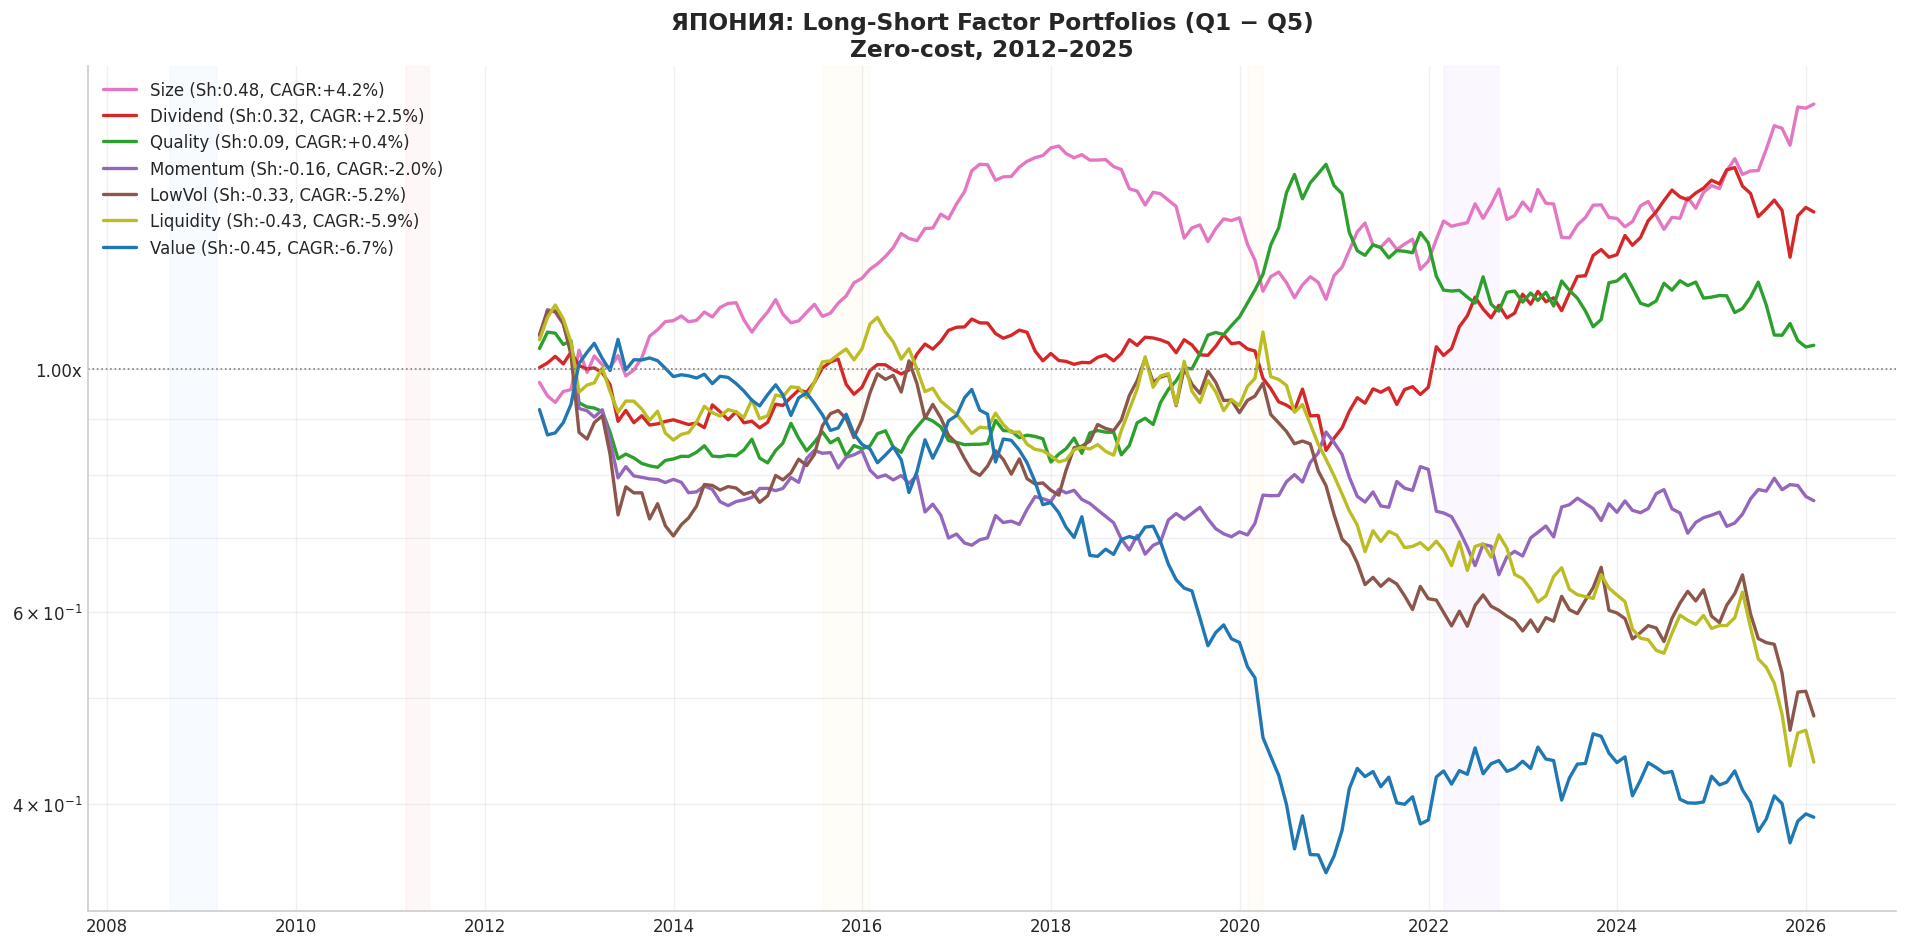

  → Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/JP_long_short_cumulative.png


In [516]:
# ═══════════════════════════════════════════════════════════════════
# 15. LONG-SHORT PORTFOLIOS
# ═══════════════════════════════════════════════════════════════════

print("\n  15. LONG-SHORT FACTOR PORTFOLIOS (Q1 − Q5)")
print("  " + "-" * 60)

ls_all = {}

for label in ['RF', 'JP']:
    if label not in quintile_raw or not quintile_raw[label]: continue
    br = baseline_results[label]
    cfg = br['cfg']; dm = br['dm']
    qr = quintile_raw[label]

    ls_results = {}
    for fname, quints in qr.items():
        if 1 not in quints or 5 not in quints: continue
        q1, q5 = quints[1]['ret'], quints[5]['ret']
        common = q1.index.intersection(q5.index)
        if len(common) < 12: continue
        ls_results[fname] = (q1.loc[common] - q5.loc[common]).to_frame('ret')

    if not ls_results: continue
    ls_all[label] = ls_results

    fig, ax = plt.subplots(figsize=(16, 8))
    for fname, ls_df in sorted(ls_results.items(),
                                key=lambda x: metrics(x[1]['ret'])['Sharpe'],
                                reverse=True):
        ret = ls_df['ret']
        cum = (1 + ret).cumprod()
        m = metrics(ret)
        c = COLORS.get(fname, '#333333')
        ax.plot(cum.index, cum.values, color=c, lw=2,
                label=f"{fname} (Sh:{m['Sharpe']:.2f}, CAGR:{m['CAGR']:+.1%})")
        print(f"  {cfg.flag} {fname:15s} L/S: CAGR={m['CAGR']:+.1%} | "
              f"Sharpe={m['Sharpe']:+.2f} | MaxDD={m['MaxDD']:.1%}")

    ax.axhline(1, color='gray', ls=':', lw=1)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.2f}x'))
    country = 'РОССИЯ' if label == 'RF' else 'ЯПОНИЯ'
    ax.set_title(f'{country}: Long-Short Factor Portfolios (Q1 − Q5)\n'
                 f'Zero-cost, {cfg.start_year}–{cfg.max_year}',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3, which='both')
    for cr in cfg.crises:
        s, e = pd.Timestamp(cr['s']), pd.Timestamp(cr['e'])
        ax.axvspan(s, e, color=cr['c'], alpha=0.15, zorder=0)
    plt.tight_layout()
    fn = os.path.join(OUT, f'{label}_long_short_cumulative.png')
    plt.savefig(fn, bbox_inches='tight')
    plt.show()
    print(f"  → Saved: {fn}")

## 16. Turnover Analysis

Годовой оборот: доля акций, заменённых при ребалансировке.
Implied TC = `avg_turnover × tc_bps × 2` (buy + sell).

In [518]:
# ═══════════════════════════════════════════════════════════════════
# 16. TURNOVER ANALYSIS
# ═══════════════════════════════════════════════════════════════════

print("\n  16. TURNOVER ANALYSIS")
print("  " + "-" * 60)

def compute_turnover(cfg, panel, strategies):
    mc = next((c for c in ['market_cap_mln','log_market_cap']
               if c in panel.columns), None)
    results = {}
    for name, specs in strategies.items():
        nb_sp = specs.get('nonbank', {})
        bk_sp = specs.get('bank', nb_sp)
        holdings = {}
        for year in range(cfg.start_year, cfg.max_year + 1):
            mask = panel['trading_year'] == year
            if mc and cfg.min_market_cap > 0:
                if 'log' in str(mc):
                    mask &= panel[mc] > np.log(cfg.min_market_cap)
                else:
                    mask &= panel[mc] > cfg.min_market_cap
            uni = panel[mask].copy()
            if len(uni) < cfg.top_n: continue
            banks = uni[uni['is_bank']].copy()
            nonb  = uni[~uni['is_bank']].copy()
            scores = pd.Series(np.nan, index=uni.index)
            if len(nonb) >= 3:
                scores.loc[nonb.index] = _score_standalone(nonb, nb_sp)
            if len(banks) >= 2:
                bs = _score_standalone(banks, bk_sp)
                nb_ok = scores.loc[nonb.index]
                if nb_ok.notna().sum() > 0:
                    nm, ns = nb_ok.mean(), nb_ok.std()
                    if ns > 0 and bs.std() > 0:
                        bs = (bs - bs.mean()) / bs.std() * ns + nm
                scores.loc[banks.index] = bs
            uni['fs'] = scores
            uni = uni.dropna(subset=['fs'])
            if len(uni) < cfg.top_n: continue
            holdings[year] = set(uni.nlargest(cfg.top_n,'fs')[cfg.ticker_col].tolist())

        turnovers = []
        years = sorted(holdings.keys())
        for i in range(1, len(years)):
            prev, curr = holdings[years[i-1]], holdings[years[i]]
            overlap = len(prev & curr)
            turnovers.append({'year': years[i], 'overlap': overlap,
                              'replaced': cfg.top_n - overlap,
                              'turnover_pct': (1 - overlap/cfg.top_n) * 100})
        if turnovers:
            results[name] = pd.DataFrame(turnovers)
    return results

turnover_tables = {}
for label in ['RF', 'JP']:
    if label not in baseline_results: continue
    br = baseline_results[label]
    cfg = br['cfg']; dm = br['dm']
    turn = compute_turnover(cfg, dm.panel, cfg.strategies)
    turn_rows = []
    print(f"\n  {cfg.flag} {label}: Annual Turnover (Top-{cfg.top_n})")
    for name, tdf in sorted(turn.items()):
        avg_to = tdf['turnover_pct'].mean()
        avg_repl = tdf['replaced'].mean()
        implied_tc = avg_to/100 * cfg.tc_bps * 2 / 10000
        turn_rows.append({'Factor': name, 'Country': label,
                          'Avg_Turnover_%': avg_to, 'Avg_Replaced': avg_repl,
                          'Implied_TC_Ann_%': implied_tc * 100})
        print(f"    {name:15s} | Turnover = {avg_to:.0f}% "
              f"({avg_repl:.0f}/{cfg.top_n} replaced) | "
              f"Implied TC ≈ {implied_tc:.2%}/yr")
    turnover_tables[label] = pd.DataFrame(turn_rows)


  16. TURNOVER ANALYSIS
  ------------------------------------------------------------

  🇷🇺 RF RF: Annual Turnover (Top-20)
    Dividend        | Turnover = 52% (10/20 replaced) | Implied TC ≈ 0.52%/yr
    Liquidity       | Turnover = 36% (7/20 replaced) | Implied TC ≈ 0.36%/yr
    LowVol          | Turnover = 66% (13/20 replaced) | Implied TC ≈ 0.66%/yr
    Momentum        | Turnover = 77% (15/20 replaced) | Implied TC ≈ 0.77%/yr
    Quality         | Turnover = 52% (10/20 replaced) | Implied TC ≈ 0.52%/yr
    Size            | Turnover = 48% (10/20 replaced) | Implied TC ≈ 0.48%/yr
    Value           | Turnover = 63% (13/20 replaced) | Implied TC ≈ 0.63%/yr

  🇯🇵 JP JP: Annual Turnover (Top-20)
    Dividend        | Turnover = 71% (14/20 replaced) | Implied TC ≈ 0.43%/yr
    Liquidity       | Turnover = 38% (8/20 replaced) | Implied TC ≈ 0.23%/yr
    LowVol          | Turnover = 82% (16/20 replaced) | Implied TC ≈ 0.49%/yr
    Momentum        | Turnover = 78% (16/20 replaced) | Im

## 17. Subperiod Robustness

- **2012–2018**: post-GFC, Крым/нефть, начало Abenomics
- **2019–2026**: COVID, СВО, Yen crash, нормализация ставок

Критерий стабильности: |ΔSharpe| < 0.3 между подпериодами.

In [520]:
# ═══════════════════════════════════════════════════════════════════
# 17. SUBPERIOD ROBUSTNESS
# ═══════════════════════════════════════════════════════════════════

print("\n  17. SUBPERIOD ROBUSTNESS")
print("  " + "-" * 60)

def subperiod_metrics(report, split_date='2019-01-01'):
    split = pd.Timestamp(split_date)
    rows = []
    for fname, d in report.res.items():
        ret = d['ret'].reindex(report.cidx).fillna(0)
        rf_s = report.rf.reindex(report.cidx).fillna(report.rf.mean())
        for pname, mask in [('Full', ret.index >= ret.index.min()),
                            ('2012-2018', ret.index < split),
                            ('2019-2026', ret.index >= split)]:
            r_sub, rf_sub = ret[mask], rf_s[mask]
            if len(r_sub) < 12: continue
            m = metrics(r_sub, rf_sub)
            rows.append({'Factor': fname, 'Period': pname,
                         'N_months': len(r_sub), 'CAGR': m['CAGR'],
                         'Sharpe': m['Sharpe'], 'Vol': m['Vol'],
                         'MaxDD': m['MaxDD']})
    return pd.DataFrame(rows)

subperiod_tables = {}
for label in ['RF', 'JP']:
    if label not in baseline_results: continue
    br = baseline_results[label]
    sp = subperiod_metrics(br['report'])
    subperiod_tables[label] = sp
    country = 'РОССИЯ' if label == 'RF' else 'ЯПОНИЯ'
    print(f"\n  {br['cfg'].flag} {country}:")
    pivot = sp.pivot_table(index='Factor', columns='Period',
                           values='Sharpe', aggfunc='first')
    if '2012-2018' in pivot.columns and '2019-2026' in pivot.columns:
        pivot['delta'] = pivot['2019-2026'] - pivot['2012-2018']
        pivot = pivot.sort_values('Full', ascending=False)
        for fname in pivot.index:
            row = pivot.loc[fname]
            sh1 = row.get('2012-2018', np.nan)
            sh2 = row.get('2019-2026', np.nan)
            delta = row.get('delta', np.nan)
            stable = abs(delta) < 0.3 if pd.notna(delta) else False
            tag = 'Stable' if stable else 'Unstable'
            print(f"    {fname:15s} | 2012-18: Sh={sh1:+.2f} | "
                  f"2019-25: Sh={sh2:+.2f} | dSh={delta:+.2f} | {tag}")


  17. SUBPERIOD ROBUSTNESS
  ------------------------------------------------------------

  🇷🇺 RF РОССИЯ:
    Dividend        | 2012-18: Sh=+0.36 | 2019-25: Sh=+0.44 | dSh=+0.08 | Stable
    Size            | 2012-18: Sh=+0.11 | 2019-25: Sh=+0.54 | dSh=+0.43 | Unstable
    Value           | 2012-18: Sh=+0.31 | 2019-25: Sh=+0.35 | dSh=+0.04 | Stable
    Momentum        | 2012-18: Sh=+0.34 | 2019-25: Sh=+0.19 | dSh=-0.16 | Stable
    LowVol          | 2012-18: Sh=+0.09 | 2019-25: Sh=+0.30 | dSh=+0.20 | Stable
    Liquidity       | 2012-18: Sh=-0.55 | 2019-25: Sh=+0.29 | dSh=+0.84 | Unstable
    Quality         | 2012-18: Sh=-0.01 | 2019-25: Sh=+0.19 | dSh=+0.19 | Stable

  🇯🇵 JP ЯПОНИЯ:
    Dividend        | 2012-18: Sh=+1.23 | 2019-25: Sh=+1.14 | dSh=-0.09 | Stable
    Quality         | 2012-18: Sh=+1.08 | 2019-25: Sh=+1.21 | dSh=+0.13 | Stable
    Liquidity       | 2012-18: Sh=+0.96 | 2019-25: Sh=+1.22 | dSh=+0.27 | Stable
    LowVol          | 2012-18: Sh=+1.17 | 2019-25: Sh=+0.97 |

## 18. Survivorship Bias & Limitations

### Ограничения исследования

| # | Ограничение | Направление bias | Оценка |
|---|-------------|-----------------|--------|
| 1 | **Survivorship bias** (текущий юниверс) | CAGR ↑ | +1–3% (Elton et al. 1996) |
| 2 | **EW bias** (завышает Size) | Size CAGR ↑ | +1–2% для Size |
| 3 | **TC underestimate** (при high turnover) | CAGR ↑ | +0.5–1% |
| 4 | **Annual rebalancing** (медленная реакция) | CAGR ↓ | −1–2% vs monthly |
| 5 | **Long-only baseline** (β-exposure) | Alpha ↑ | Компенсировано L/S (раздел 15) |
| 6 | **CAPM-only** (нет FF5) | Alpha ↑ | FF5 недоступна для РФ |
| 7 | **13 cross-sections** (FM power) | Significance ↓ | Fundamental limitation |
| 8 | **Ad hoc weights** | Unknown | IC-weighted as robustness |
| **Итого** | | **CAGR ↑** | **+1–3% в среднем** |

In [522]:
# ═══════════════════════════════════════════════════════════════════
# 19. FINAL EXPORT (UPDATED + ROBUSTNESS)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("  ФИНАЛЬНЫЙ ЭКСПОРТ (Baseline + Quality + Robustness)")
print("=" * 80)

try:
    with pd.ExcelWriter(os.path.join(OUT, 'FULL_RESEARCH_TABLES.xlsx')) as w:
        # Part I
        if 'comparison' in baseline_results:
            baseline_results['comparison']['metrics'].to_excel(
                w, 'I_Metrics_by_Sharpe', index=False)
            baseline_results['comparison']['regressions'].to_excel(
                w, 'I_Regressions_by_pvalue', index=False)
        # Part II
        if isinstance(mt_q, pd.DataFrame):
            mt_q.to_excel(w, 'II_Quality_Metrics', index=False)
        if isinstance(rt_q, pd.DataFrame):
            rt_q.to_excel(w, 'II_Quality_Regressions', index=False)
        # IC + FM
        for lb, ic_df in ic_tables.items():
            ic_df.to_excel(w, f'IC_{lb}', index=False)
        for lb, fm_df in fm_tables.items():
            fm_df.to_excel(w, f'FM_{lb}', index=False)
        # Part III
        for lb, qt in quintile_tables.items():
            qt.to_excel(w, f'III_Quintiles_{lb}', index=False)
        for lb, to_df in turnover_tables.items():
            to_df.to_excel(w, f'III_Turnover_{lb}', index=False)
        for lb, sp in subperiod_tables.items():
            sp.to_excel(w, f'III_Subperiod_{lb}', index=False)
    print(f"  -> Saved: {os.path.join(OUT, 'FULL_RESEARCH_TABLES.xlsx')}")
except Exception as e:
    print(f"  Export error: {e}")

print(f"\n{'='*80}")
print(f"  ИССЛЕДОВАНИЕ ЗАВЕРШЕНО")
print(f"  Структура:")
print(f"    Часть I:   Baseline 7 факторов x 2 рынка")
print(f"    Часть II:  Deep Quality Q0-Q3 + IC + Fama-MacBeth")
print(f"    Часть III: Quintile Sorts + L/S + Turnover + Subperiods")
print(f"  Output: {OUT}")
print(f"{'='*80}")


  ФИНАЛЬНЫЙ ЭКСПОРТ (Baseline + Quality + Robustness)
  -> Saved: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output/FULL_RESEARCH_TABLES.xlsx

  ИССЛЕДОВАНИЕ ЗАВЕРШЕНО (v6.1 + Robustness)
  Структура:
    Часть I:   Baseline 7 факторов x 2 рынка
    Часть II:  Deep Quality Q0-Q3 + IC + Fama-MacBeth
    Часть III: Quintile Sorts + L/S + Turnover + Subperiods
  Output: /Users/dmitrijeremkin/Desktop/диплом созвон 5/output
